In [1]:
import warnings
warnings.filterwarnings("ignore")

# 📊 Analisi della Mobilità Intelligente - Smart Mobility Traffic Analysis

## 🎯 Obiettivi del progetto

L'obiettivo di questo notebook è analizzare i dati di mobilità urbana per identificare condizioni del traffico, valutare la sicurezza stradale e costruire modelli predittivi legati agli incidenti e alla congestione. L'analisi si basa sull'integrazione di più dataset contenenti informazioni su:

- Condizioni stradali e traffico (veicoli, incidenti, situazioni)
- Fattori che influenzano la sicurezza, come condizioni meteo e del manto stradale
- Elementi predittivi per valutare il rischio di incidenti

## 📁 Dataset utilizzati

1. `smart_mobility_dataset.csv`: contiene informazioni di base su traffico e mobilità
2. `dataset_traffic_accident_prediction1.csv`: dati sulle condizioni stradali
3. `TrafficTwoMonth.csv`: dati dettagliati sul conteggio dei veicoli e condizioni del traffico

L’obiettivo finale sarà quello di costruire una base analitica utile per proposte di miglioramento della viabilità e sicurezza urbana.

In [33]:
#Importiamo le librerie 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

#Leggiamo il dataset
dataset = pd.read_csv('smart_mobility_dataset.csv', sep=",")
dataset2= pd.read_csv('dataset_traffic_accident_prediction1.csv', sep=';')
dataset3= pd.read_csv('TrafficTwoMonth.csv')

dataset.head()


,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [3]:
dataset['Road_Condition']=dataset2['Road_Condition']
dataset.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition,Road_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High,Wet
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High,Wet
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High,Icy
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High,Under Construction
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low,Dry


In [4]:
dataset=dataset.drop(columns=['Traffic_Condition', 'Vehicle_Count'], axis=1)

cols_to_add = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation']
for col in cols_to_add:
    dataset[col] = dataset3[col].values[:5000]

dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,Wet,13,2,2,24,41,normal
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,Wet,14,1,1,36,52,normal
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,Icy,10,2,2,32,46,normal
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,Under Construction,10,2,2,36,50,normal
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Dry,11,2,1,34,48,normal


## 1 - Analisi Preliminare

In [5]:
#Visualizziamo i tipi delle colonne
print(f"{dataset.dtypes}\n")

print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])

Timestamp                  object
Latitude                  float64
Longitude                 float64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State        object
Weather_Condition          object
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Road_Condition             object
CarCount                    int64
BikeCount                   int64
BusCount                    int64
TruckCount                  int64
Total                       int64
Traffic Situation          object
dtype: object

Number of rows:  5000
Number of columns:  20


In [6]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,CarCount,BikeCount,BusCount,TruckCount,Total
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243,64.57580,11.661800,12.371200,19.267200,107.876000
std,0.086123,0.086204,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277,44.45762,11.329832,11.973708,10.976425,55.054326
min,40.600016,-73.999987,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787,5.00000,0.000000,0.000000,0.000000,21.000000
25%,40.675403,-73.920281,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761,18.00000,2.000000,2.000000,10.000000,54.000000
50%,40.748875,-73.846058,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791,62.00000,9.000000,10.000000,18.000000,103.000000
75%,40.824735,-73.771685,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595,102.00000,18.000000,20.000000,28.000000,150.000000
max,40.899972,-73.700159,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416,180.00000,70.000000,50.000000,60.000000,279.000000


In [7]:
    #Verifica dati mancanti
missing_values = dataset.isnull().sum()
print(missing_values)

Timestamp                  0
Latitude                   0
Longitude                  0
Traffic_Speed_kmh          0
Road_Occupancy_%           0
Traffic_Light_State        0
Weather_Condition          0
Accident_Report            0
Sentiment_Score            0
Ride_Sharing_Demand        0
Parking_Availability       0
Emission_Levels_g_km       0
Energy_Consumption_L_h     0
Road_Condition            42
CarCount                   0
BikeCount                  0
BusCount                   0
TruckCount                 0
Total                      0
Traffic Situation          0
dtype: int64


### 📊 Istogrammi delle Feature Numeriche

In questa sezione analizziamo la distribuzione delle principali variabili numeriche del dataset.

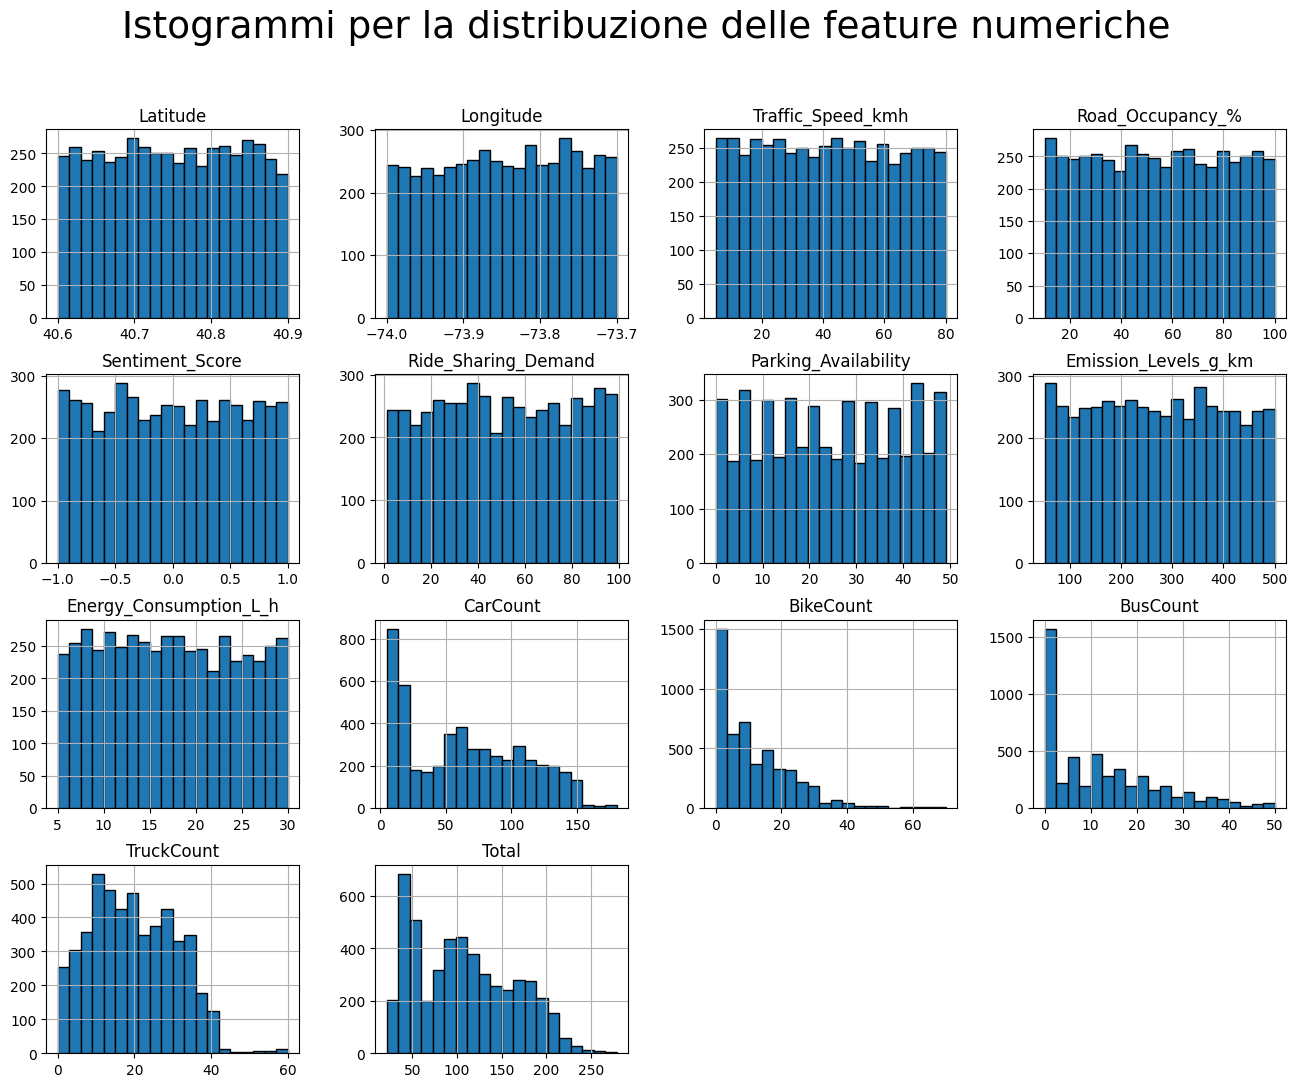

In [8]:
# Istogrammi per la distribuzione delle feature numeriche

# Elenco delle colonne da escludere
columns_to_exclude = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report', 'Traffic Situation']

# Creiamo il subset dei dati senza le feature da escludere
data_subset = dataset.drop(columns=columns_to_exclude)
data_subset.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle("Istogrammi per la distribuzione delle feature numeriche", fontsize=27)
plt.show()

### 📦 Box Plot delle Feature Numeriche

Questo grafico mostra i box plot di tutte le variabili numeriche del dataset. Il box plot è utile per:

- Osservare **mediana, quartili e intervallo interquartile (IQR)**
- Identificare **outlier** (valori anomali fuori dai baffi)
- Valutare **asimmetrie** nelle distribuzioni

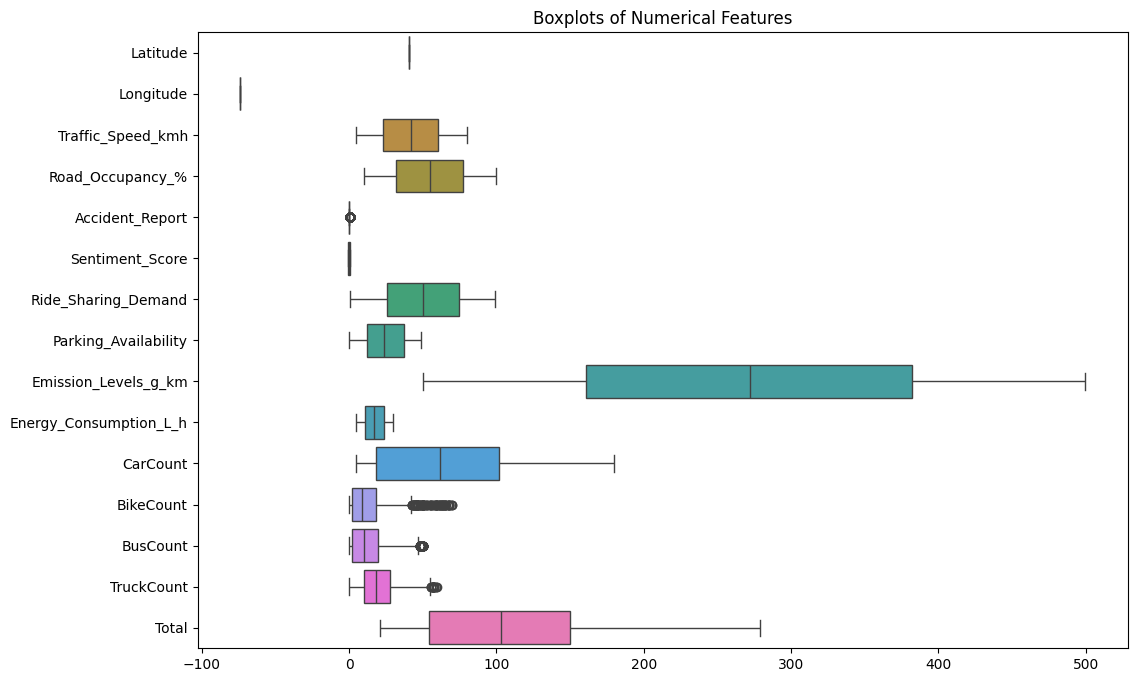

In [9]:
# Boxplot per le feature numeriche
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h") #boxplot serve per vedere eventuali outliers
plt.title("Boxplots of Numerical Features")
plt.show()

#### 📍 Osservazioni Chiave

- `Emission_Levels_g_km`, `Total`, `CarCount` e `Energy_Consumption_l_h` presentano una **ampia variabilità** e molti valori estremi.
- `BikeCount`, `BusCount`, `TruckCount` mostrano **outlier frequenti**, indicando eventi rari con un numero eccezionalmente alto di veicoli.
- `Parking_Availability` e `Ride_Sharing_Demand` hanno una distribuzione più concentrata, con **poche anomalie**.
- `Accident_Report` e `Sentiment_Score` mostrano una **distribuzione fortemente concentrata**, ma con alcuni **outlier**, da investigare.
- `Traffic_Speed_kmh` e `Road_Occupancy_%` mostrano un range limitato e ben definito, coerente con i limiti fisici reali.

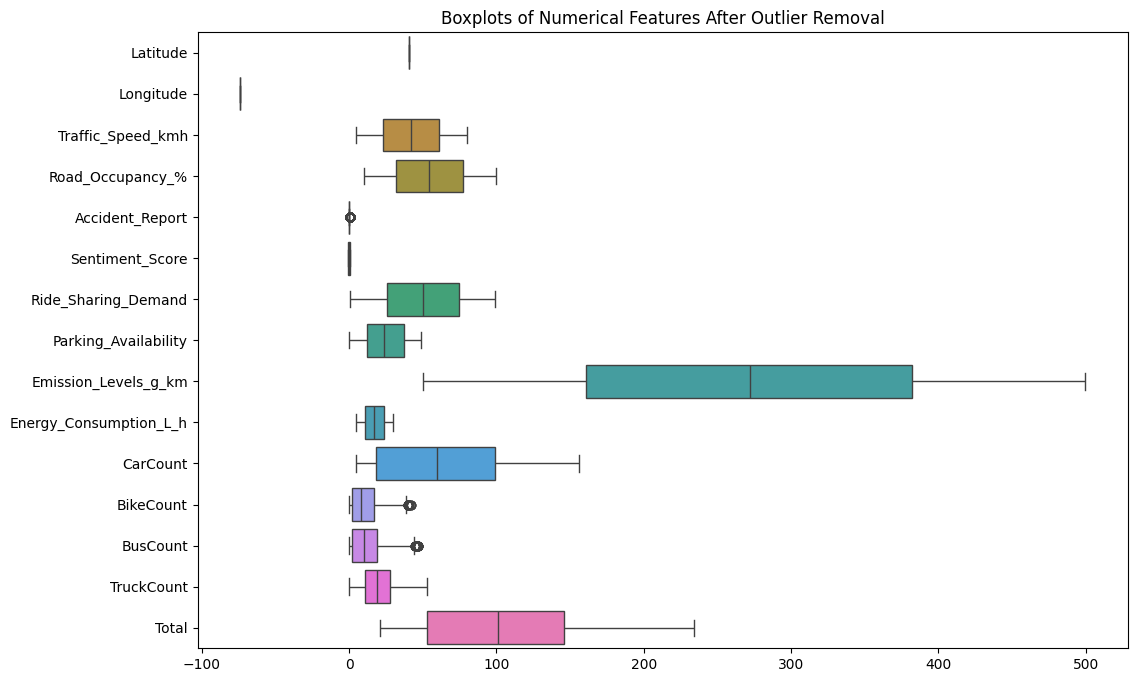

In [10]:
# Rimozione outlier per CarCount, BikeCount, TruckCount usando l'IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean


dataset = remove_outliers_iqr(dataset, ['CarCount', 'BikeCount', 'TruckCount', 'BusCount'])
dataset.head()
# Verifica della presenza di outlier dopo la rimozione
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h")
plt.title("Boxplots of Numerical Features After Outlier Removal")
plt.show()


### Estrazione informazioni -- Giorno, Mese, Ora

In [11]:
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,...,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,...,2,2,24,41,normal,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,...,1,1,36,52,normal,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,...,2,2,32,46,normal,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,...,2,2,36,50,normal,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,...,2,1,34,48,normal,4,0,1,3,0


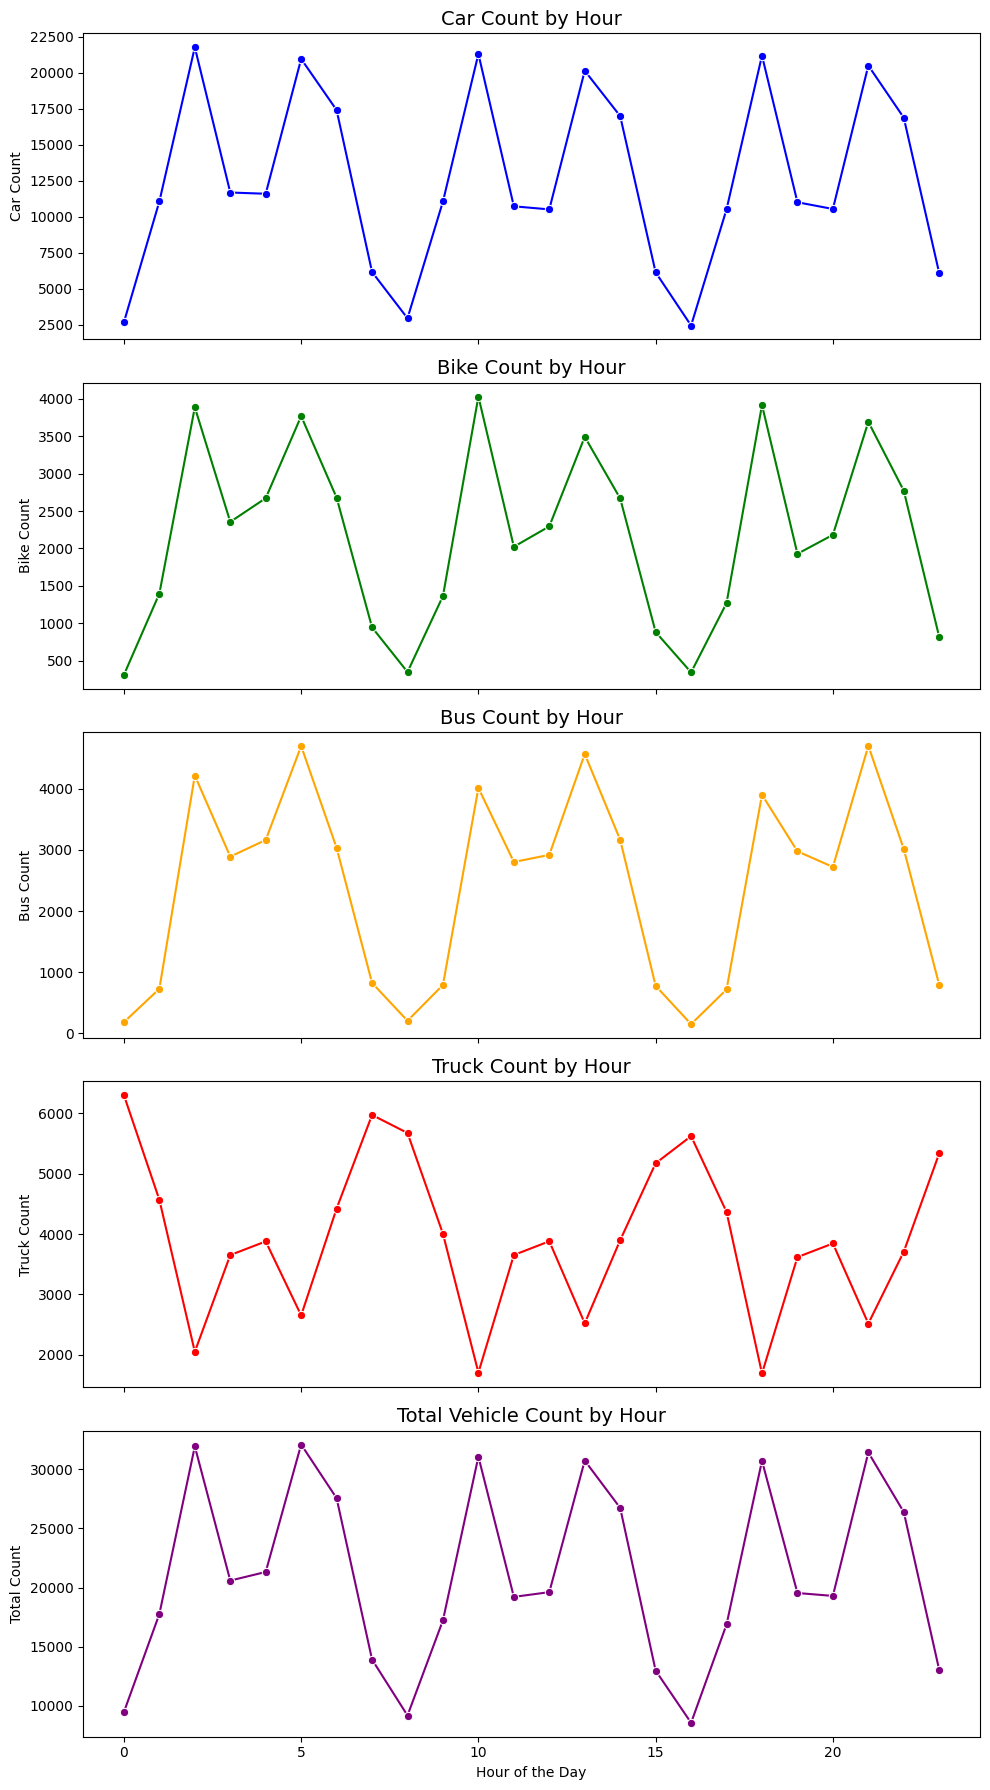

In [12]:
# Select only numeric columns for summation
numeric_columns = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
# Group by hour and sum the vehicle counts
hourly_data = dataset.groupby('Hour')[numeric_columns].sum()

# Set the figure size and layout for separate plots
fig, axes = plt.subplots(5, 1, figsize=(10, 18), sharex=True)

# Plot for CarCount
sns.lineplot(x=hourly_data.index, y=hourly_data['CarCount'], ax=axes[0], color='blue', marker='o')
axes[0].set_title('Car Count by Hour', fontsize=14)
axes[0].set_ylabel('Car Count')

# Plot for BikeCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BikeCount'], ax=axes[1], color='green', marker='o')
axes[1].set_title('Bike Count by Hour', fontsize=14)
axes[1].set_ylabel('Bike Count')

# Plot for BusCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BusCount'], ax=axes[2], color='orange', marker='o')
axes[2].set_title('Bus Count by Hour', fontsize=14)
axes[2].set_ylabel('Bus Count')

# Plot for TruckCount
sns.lineplot(x=hourly_data.index, y=hourly_data['TruckCount'], ax=axes[3], color='red', marker='o')
axes[3].set_title('Truck Count by Hour', fontsize=14)
axes[3].set_ylabel('Truck Count')

# Plot for Total
sns.lineplot(x=hourly_data.index, y=hourly_data['Total'], ax=axes[4], color='purple', marker='o')
axes[4].set_title('Total Vehicle Count by Hour', fontsize=14)
axes[4].set_xlabel('Hour of the Day')
axes[4].set_ylabel('Total Count')

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

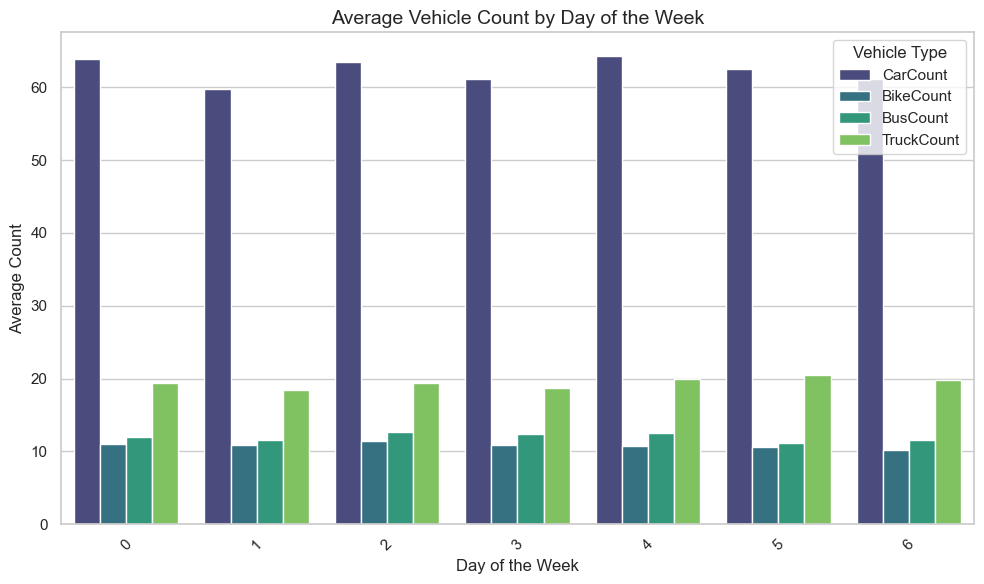

In [13]:
# Select only numeric columns, and then choose the specific columns you want
numeric_columns = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount']

# Group by 'Day of the week' and calculate the mean for only the selected numeric columns
grouped_df = dataset.groupby('DayOfWeek')[numeric_columns].mean()

# Reset the index to make 'Day of the week' a column again
grouped_df = grouped_df.reset_index()

# Use the melt function to reshape the DataFrame for seaborn
grouped_df_melted = pd.melt(grouped_df, id_vars='DayOfWeek', var_name='Vehicle Type', value_name='Count')

# Set plot style and size
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create the barplot
sns.barplot(x='DayOfWeek', y='Count', hue='Vehicle Type', data=grouped_df_melted, palette='viridis')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title('Average Vehicle Count by Day of the Week', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Count', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

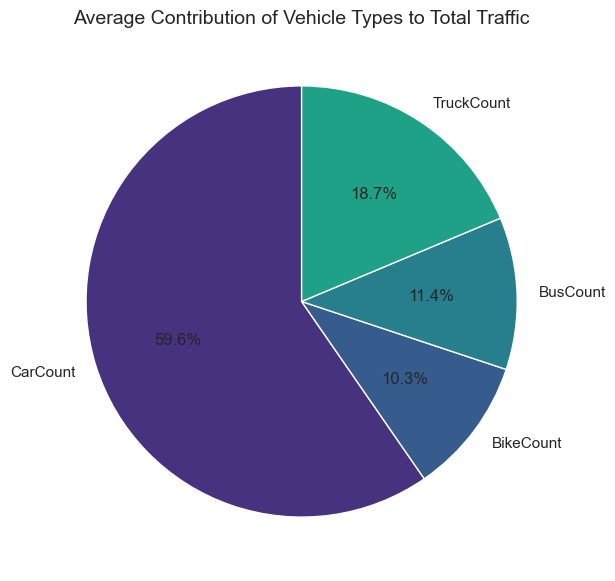

In [14]:
# Pie chart for average contribution of each vehicle type to total traffic
average_vehicle_counts = dataset[['CarCount', 'BikeCount', 'BusCount', 'TruckCount']].mean()

plt.figure(figsize=(7, 7))
plt.pie(average_vehicle_counts, labels=average_vehicle_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))

plt.title('Average Contribution of Vehicle Types to Total Traffic', fontsize=14)
plt.show()

### Analisi dei Istogrammi delle Feature Categoriche


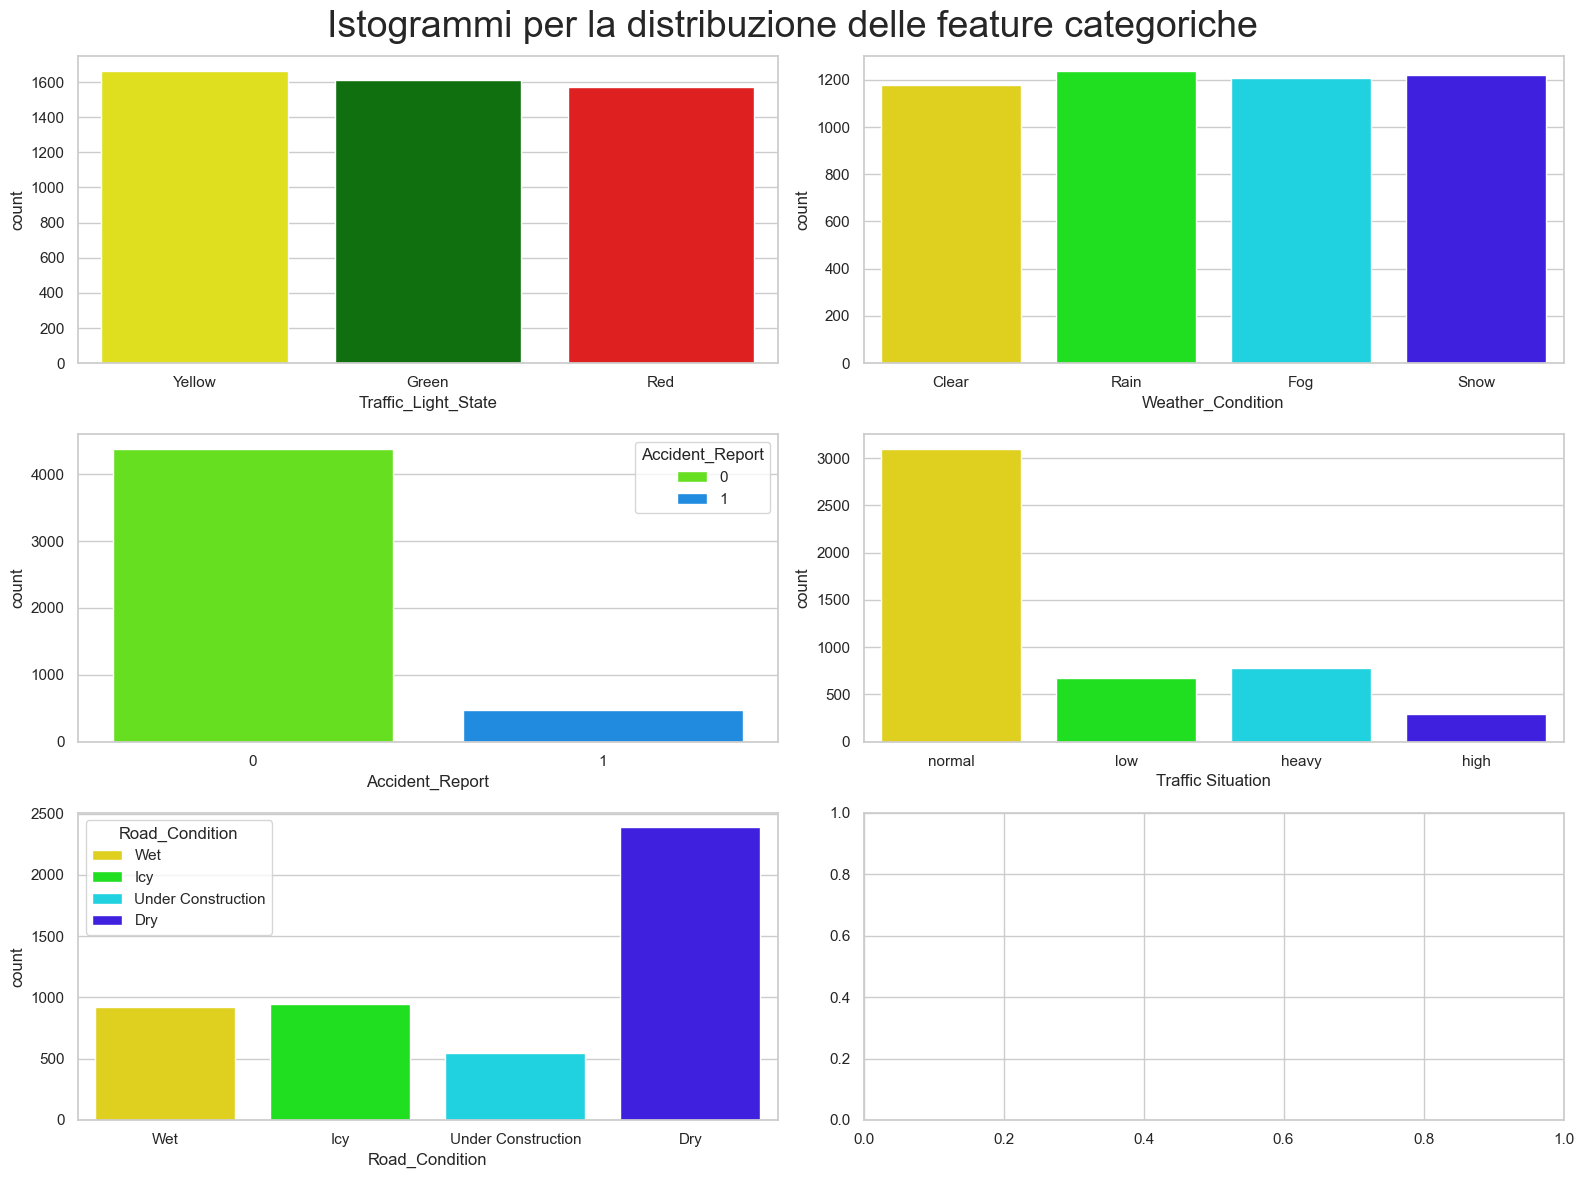

In [15]:
# Istogrammi per le features categoriche
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
sns.countplot(data=dataset, x='Traffic_Light_State', hue='Traffic_Light_State', ax=axes[0, 0], palette={'Red': 'red', 'Yellow': 'yellow', 'Green': 'green'})
sns.countplot(data=dataset, x='Weather_Condition', hue='Weather_Condition', ax=axes[0, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Accident_Report', hue='Accident_Report', ax=axes[1, 0], palette='gist_rainbow')
sns.countplot(data=dataset, x='Traffic Situation', hue='Traffic Situation', ax=axes[1, 1], palette='gist_rainbow')
sns.countplot(data=dataset, x='Road_Condition', hue='Road_Condition', ax=axes[2, 0], palette='gist_rainbow')
plt.suptitle("Istogrammi per la distribuzione delle feature categoriche", fontsize=27)
plt.tight_layout()
plt.show()

#### 1. Stato del Semaforo (`Traffic_Light_State`)
- Gli stati del semaforo (Giallo, Verde, Rosso) hanno una distribuzione abbastanza uniforme, con circa 1500 occorrenze per ciascuno.
- La presenza di ogni stato in quantità simili suggerisce un dataset bilanciato in termini di segnali semaforici.

#### 2. Condizioni Meteorologiche (`Weather_Condition`)
- Le condizioni meteorologiche includono Clear (Sereno), Rain (Pioggia), Fog (Nebbia) e Snow (Neve), ognuna con circa 1000 occorrenze.
- L'equa distribuzione delle condizioni atmosferiche permette un'analisi solida dell'impatto del meteo sulla sicurezza stradale.

#### 3. Incidenti (`Accident_Report`)
- Il numero di incidenti è significativamente inferiore rispetto ai casi senza incidente (500 contro 4000).
- Ciò evidenzia che, sebbene gli incidenti siano relativamente rari, la loro analisi rimane fondamentale per la prevenzione.

#### 4. Situazione del Traffico (`Traffic_Situation`)
- Le categorie includono Normal (Normale), Low (Basso), Heavy (Pesante) e High (Alto).
- Il traffico normale ha il numero più alto di occorrenze (~3000), mentre la situazione di traffico elevato è la meno comune.
- Questi dati potrebbero essere utilizzati per identificare le condizioni che portano a congestioni stradali.

#### 5. Stato della Strada (`Road_Condition`)
- Le categorie includono Wet (Bagnato), Icy (Ghiacciato), Under Construction (In Costruzione) e Dry (Asciutto).
- Le strade asciutte sono le più frequenti (~2500), mentre le strade in costruzione sono le meno comuni.
- Questo dato aiuta a comprendere quali condizioni stradali sono più rappresentate nel dataset e la loro possibile influenza sulla sicurezza.

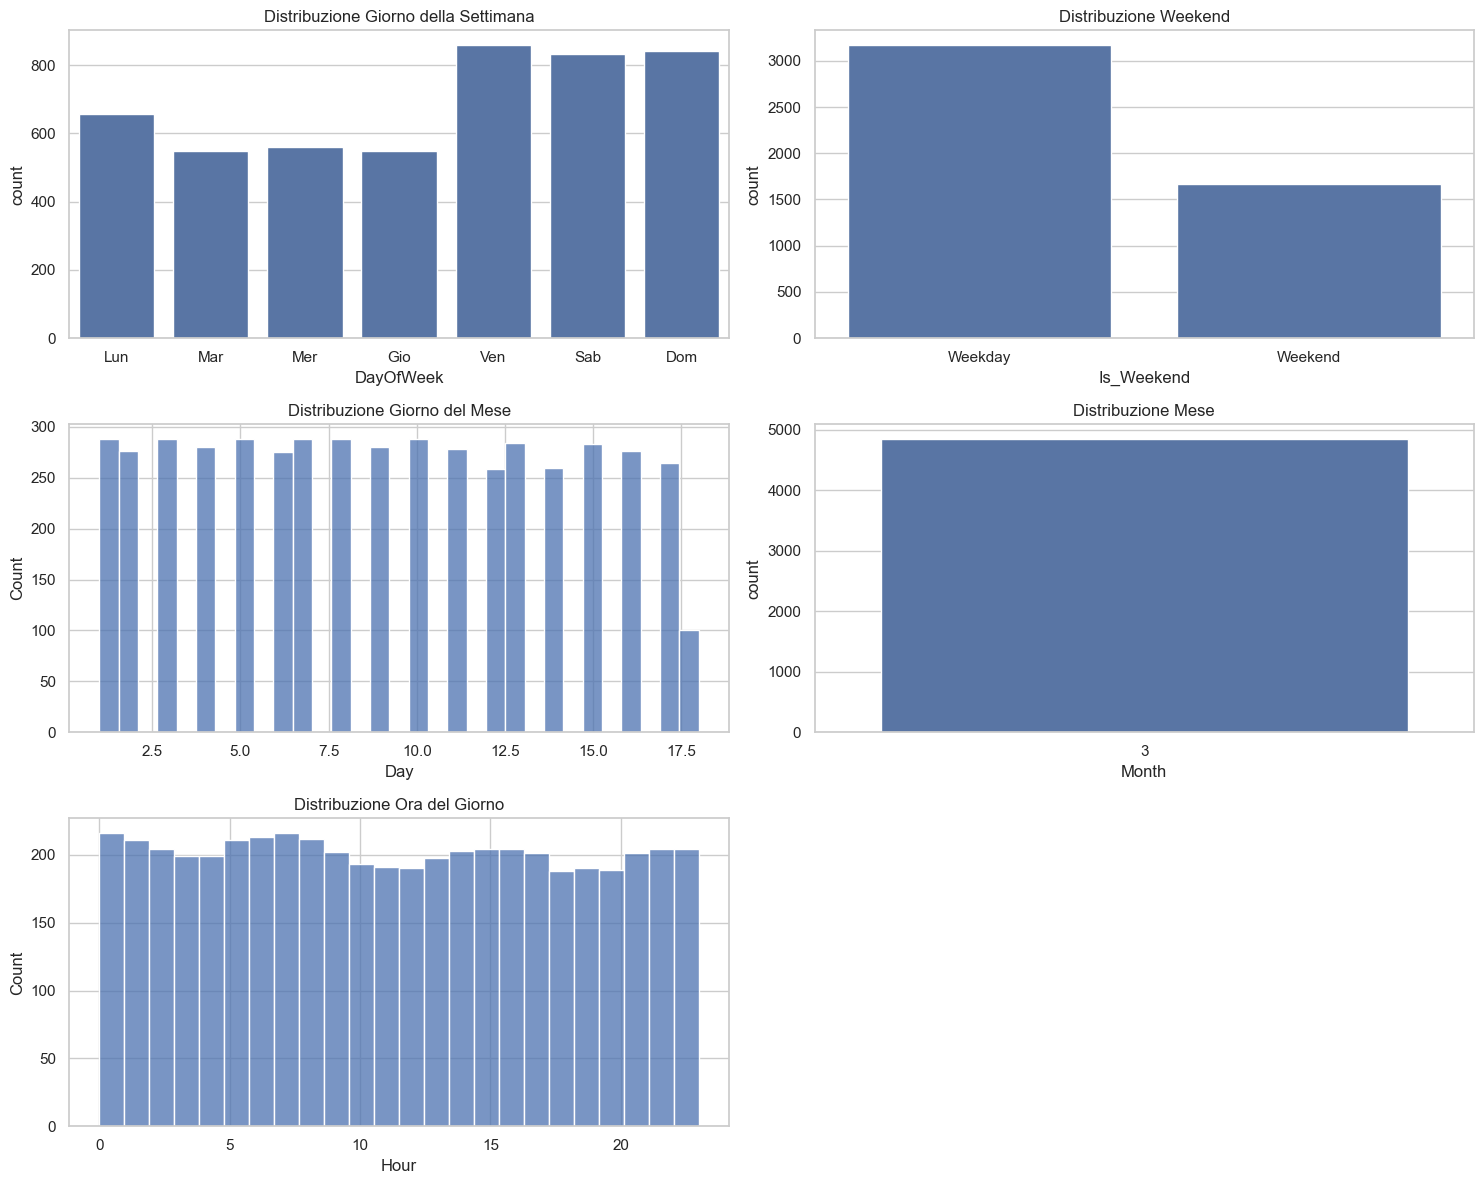

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile di seaborn
sns.set(style="whitegrid")

# Crea una figura con sottotrame
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Distribuzione del giorno della settimana
sns.countplot(x='DayOfWeek', data=dataset, ax=axes[0, 0])
axes[0, 0].set_title('Distribuzione Giorno della Settimana')
# Per asse con 7 giorni della settimana
axes[0, 0].set_xticks(range(7))  # Imposta i tick in 0-6
axes[0, 0].set_xticklabels(['Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab', 'Dom'])

# Distribuzione weekend
sns.countplot(x='Is_Weekend', data=dataset, ax=axes[0, 1])
axes[0, 1].set_title('Distribuzione Weekend')
# Per asse con 2 valori: Weekday vs Weekend
axes[0, 1].set_xticks([0, 1])  # Imposta 2 tick: posizione 0 e 1
axes[0, 1].set_xticklabels(['Weekday', 'Weekend'])


# Distribuzione giorno del mese
sns.histplot(dataset['Day'], bins=31, kde=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribuzione Giorno del Mese')

# Distribuzione mese
sns.countplot(x='Month', data=dataset, ax=axes[1, 1])
axes[1, 1].set_title('Distribuzione Mese')

# Distribuzione ora del giorno
sns.histplot(dataset['Hour'], bins=24, kde=False, ax=axes[2, 0])
axes[2, 0].set_title('Distribuzione Ora del Giorno')

# Nascondi il subplot vuoto
axes[2, 1].axis('off')

# Mostra i grafici
plt.tight_layout()
plt.show()


### 1. Distribuzione Giorno della Settimana

* Questo grafico a barre mostra il conteggio per ogni giorno della settimana.
* Si osserva una *maggiore frequenza nei giorni di Venerdì, Sabato e Domenica*, con conteggi che superano i 700.
* I giorni infrasettimanali (Lunedì, Martedì, Mercoledì, Giovedì) presentano conteggi inferiori e più uniformi, oscillando tra circa 500 e 600.
* Questa tendenza suggerisce un'intensificazione dell'attività o degli eventi monitorati verso la fine della settimana lavorativa e durante il weekend.

### 2. Distribuzione Weekend

* Questo grafico a barre confronta il conteggio tra "Weekday" (giorni feriali) e "Weekend".
* Il conteggio per i "Weekday" è significativamente più alto, attorno ai 2900-3000, mentre per il "Weekend" è circa 1700.
* Questa aggregazione è coerente con la distribuzione giornaliera: la somma dei conteggi dei giorni feriali (Lunedì-Venerdì) risulta maggiore della somma dei conteggi dei giorni del fine settimana (Sabato-Domenica), nonostante i singoli giorni del weekend mostrino picchi rispetto ai singoli giorni feriali.

### 3. Distribuzione Giorno del Mese

* Questo istogramma o grafico a barre illustra la distribuzione del conteggio per i giorni del mese (da circa 2.5 a 17.5, suggerendo intervalli o binning).
* La distribuzione appare *abbastanza uniforme* per i giorni mostrati (fino a metà mese circa), con conteggi che si attestano tra 250 e 280 per la maggior parte dei giorni.
* Si nota un leggero calo verso la fine dell'intervallo rappresentato (intorno al giorno 17.5), ma non emergono picchi o cali significativi in questa prima metà del mese.

### 4. Distribuzione Mese

* Questo grafico a barre mostra il conteggio per un singolo mese identificato come "3" (Marzo).
* Il conteggio per il mese di Marzo è notevolmente elevato, attestandosi attorno a 4500.
* Data la presenza di un solo mese, è difficile trarre conclusioni sulle tendenze mensili generali. Questo potrebbe indicare che i dati analizzati si riferiscono prevalentemente al mese di Marzo, o che è il mese con la maggiore attività nell'anno di riferimento.

### 5. Distribuzione Ora del Giorno

* Questo istogramma mostra la distribuzione del conteggio lungo le 24 ore del giorno.
* La distribuzione è *notevolmente uniforme* per la maggior parte delle ore, con conteggi che si mantengono tra 180 e 200 circa.
* Non si osservano picchi evidenti in orari specifici, suggerendo che l'attività o gli eventi monitorati sono distribuiti in modo abbastanza costante durante tutte le ore della giornata. Questo potrebbe indicare un processo automatizzato o una misurazione continua, piuttosto che attività umane con tipici picchi diurni e cali notturni.


## 2 - Preparazione dei dati

In [17]:
# cancellazione delle feature inutili per i nostri obiettivi e costanti
dataset=dataset.drop(columns=['Month', 'Timestamp','Sentiment_Score', 'Ride_Sharing_Demand', 'Parking_Availability'], axis=1,errors='ignore')
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,450.760055,19.574337,Wet,13,2,2,24,41,normal,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,321.800341,5.385554,Wet,14,1,1,36,52,normal,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,231.152655,10.277477,Icy,10,2,2,32,46,normal,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,410.384292,29.243279,Under Construction,10,2,2,36,50,normal,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,364.466342,16.801459,Dry,11,2,1,34,48,normal,4,0,1,0


## Label encoding
### Codifica delle variabili categoriche

Per preparare il dataset all'addestramento di modelli di Machine Learning, è necessario convertire le variabili categoriche in un formato numerico.  
In questa fase, viene utilizzato il **Label Encoding** per le variabili `Traffic_Light_State`, `Weather_Condition` e `Road_Condition`.  
Per la colonna `Traffic Situation`, che ha un ordine logico nei valori, viene invece applicata una **mappatura personalizzata**, così da rispettare la naturale scala di severità del traffico (da *normal* a *high*).


In [18]:
# Inizializziamo il LabelEncoder
encoder = LabelEncoder()

# Applichiamo il Label Encoding alle colonne categoriche
# codifica delle categotie in ordine alfabetico ma a noi non va bene per Traffic Situation

# Mappatura personalizzata per Traffic Situation
traffic_condition_mapping = {'normal': 0, 'low': 1, 'heavy': 2, 'high': 3}

# Applichiamo il mapping
dataset['Traffic Situation'] = dataset['Traffic Situation'].map(traffic_condition_mapping)

# Applichiamo il Label Encoding per le altre colonne
columns_to_encode = ['Traffic_Light_State', 'Weather_Condition', 'Road_Condition']
for col in columns_to_encode:
    dataset[col] = encoder.fit_transform(dataset[col])

dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3,13,2,2,24,41,0,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3,14,1,1,36,52,0,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1,10,2,2,32,46,0,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2,10,2,2,36,50,0,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0,11,2,1,34,48,0,4,0,1,0


### Imputazione dei valori mancanti in `Road_Condition`

Dall'analisi preliminare è emerso che la variabile `Road_Condition` presenta dati mancanti.  
Per garantire la qualità del dataset, abbiamo applicato una procedura di **imputazione**, sostituendo i valori mancanti con la **media** dei valori disponibili.  
Questa scelta permette di mantenere la coerenza statistica della feature senza introdurre bias significativi.

In [19]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
dataset['Road_Condition'] = num_imputer.fit_transform(dataset[['Road_Condition']])
dataset['Road_Condition'].isnull().sum()

np.int64(0)

In [20]:
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3.0,13,2,2,24,41,0,4,0,1,0
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3.0,14,1,1,36,52,0,4,0,1,0
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1.0,10,2,2,32,46,0,4,0,1,0
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2.0,10,2,2,36,50,0,4,0,1,0
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0.0,11,2,1,34,48,0,4,0,1,0


La cella sottostante mostra le prime righe del dataset dopo la fase di encoding e imputazione dei valori mancanti. In particolare:

- Tutte le variabili categoriche (`Traffic_Light_State`, `Weather_Condition`, `Road_Condition`, `Traffic Situation`) sono ora rappresentate da valori numerici, pronti per l’addestramento dei modelli di machine learning.
- La colonna `Road_Condition` non presenta più valori mancanti, grazie all’imputazione effettuata nella cella precedente.
- Il dataset risulta pulito e coerente, con feature numeriche e categoriche codificate, pronto per le successive fasi di modellazione e analisi predittiva.

In [21]:
# Verifichiamo l'aggiornamento delle colonne
print(f"{dataset.dtypes}\n")

Latitude                  float64
Longitude                 float64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State         int64
Weather_Condition           int64
Accident_Report             int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Road_Condition            float64
CarCount                    int64
BikeCount                   int64
BusCount                    int64
TruckCount                  int64
Total                       int64
Traffic Situation           int64
DayOfWeek                   int32
Is_Weekend                  int64
Day                         int32
Hour                        int32
dtype: object



### Calcolo Congestion_index

Prima di calcolare la matrice di correlazione, nella cella precedente è stato calcolato e aggiunto al dataset il **Congestion Index**. Questo indice sintetizza il livello di congestione stradale combinando il traffico totale e l’occupazione della strada, fornendo una variabile numerica utile per l’analisi delle correlazioni.

La cella sottostante calcola e visualizza la matrice di correlazione tra tutte le variabili numeriche del dataset, utilizzando una heatmap di Seaborn. Questo tipo di analisi è fondamentale per:

- Identificare le relazioni lineari tra le feature (valori vicini a 1 o -1 indicano forte correlazione positiva o negativa).
- Individuare possibili ridondanze: feature fortemente correlate possono essere eliminate per ridurre la dimensionalità e migliorare la generalizzazione dei modelli.
- Evidenziare pattern nascosti nei dati che possono influenzare la scelta delle variabili da utilizzare nei modelli predittivi.

La visualizzazione tramite heatmap rende immediata l’individuazione delle correlazioni più significative grazie alla scala cromatica e ai valori annotati nella matrice.

In [22]:
df_cong = dataset[['Total', 'Road_Occupancy_%', 'Traffic_Speed_kmh']].copy()

# Normalizziamo dei dati
epsilon = 1e-6
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_cong)
df_scaled = df_scaled * (1 - 2 * epsilon) + epsilon  # evitare valori 0 e 1
df_cong[['Total_norm', 'Road_Occupancy_norm','Traffic_Speed_kmh_norm']] = df_scaled

#calcolo dell'indice di congestione
dataset['Congestion_Index'] = 0.4 * df_cong['Total_norm'] + 0.6 * df_cong['Road_Occupancy_norm']

dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour,Congestion_Index
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3.0,...,2,2,24,41,0,4,0,1,0,0.521906
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3.0,...,1,1,36,52,0,4,0,1,0,0.297059
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1.0,...,2,2,32,46,0,4,0,1,0,0.532093
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2.0,...,2,2,36,50,0,4,0,1,0,0.239075
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0.0,...,2,1,34,48,0,4,0,1,0,0.132765


La cella sottostante calcola e visualizza le statistiche descrittive del dataset aggiornato, dopo l’aggiunta del **Congestion Index** e la rimozione delle feature ridondanti. Queste statistiche (media, deviazione standard, min, max, quartili) permettono di:

- Verificare la presenza di anomalie o valori fuori scala nelle variabili numeriche.
- Analizzare la distribuzione delle feature più rilevanti per la classificazione.
- Valutare la variabilità e la scala delle nuove variabili, come il Congestion Index, che sintetizza il livello di congestione stradale.

Questa analisi è fondamentale per comprendere la qualità e la struttura dei dati prima della modellazione predittiva.

In [23]:
# calcolo statistiche descrittive
dataset.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour,Congestion_Index
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,...,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,...,10.745612,11.960562,19.559777,104.704316,0.642577,3.292381,0.345241,9.102003,11.359488,0.455194
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,...,9.621917,11.547036,10.542820,52.471539,0.957190,2.032470,0.475496,5.004740,6.954106,0.200069
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,...,0.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.015925
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,...,2.000000,2.000000,11.000000,53.000000,0.000000,2.000000,0.000000,5.000000,5.000000,0.302004
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,...,8.000000,10.000000,19.000000,101.000000,0.000000,4.000000,0.000000,9.000000,11.000000,0.459007
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,...,17.000000,19.000000,28.000000,146.000000,1.000000,5.000000,1.000000,13.000000,17.000000,0.602265
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,...,42.000000,47.000000,53.000000,234.000000,3.000000,6.000000,1.000000,18.000000,23.000000,0.977794


### Matrice di correlazione

Questa cella calcola e visualizza la matrice di correlazione tra tutte le variabili numeriche del dataset, utilizzando una heatmap di Seaborn. La matrice di correlazione permette di:

- Identificare le relazioni lineari tra le feature (valori vicini a 1 o -1 indicano forte correlazione positiva o negativa).
- Individuare possibili ridondanze: feature fortemente correlate possono essere eliminate per ridurre la dimensionalità e migliorare la generalizzazione dei modelli.
- Evidenziare pattern nascosti nei dati che possono influenzare la scelta delle variabili da utilizzare nei modelli predittivi.

La visualizzazione tramite heatmap rende immediata l’individuazione delle correlazioni più significative grazie alla scala cromatica e ai valori annotati nella matrice.

Matrice di correlazione:



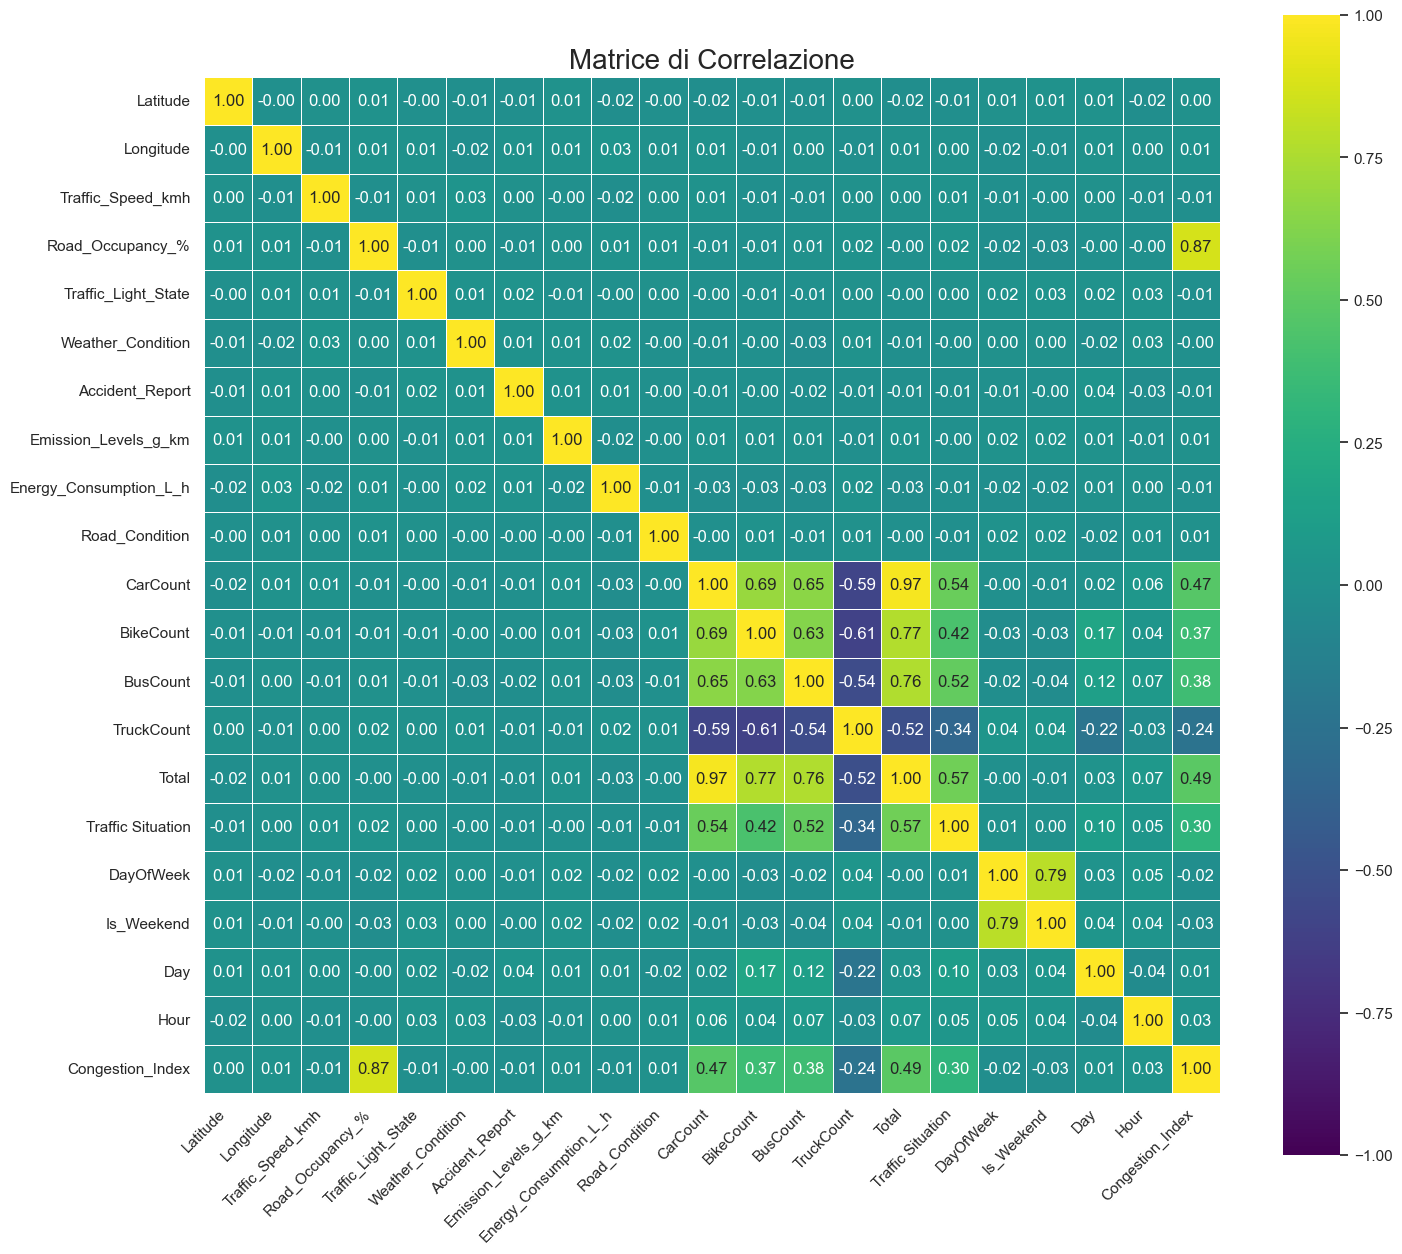

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Matrice di correlazione:\n')
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    square=True,
    linewidths=0.5,
    linecolor='white',
    vmax=1,
    vmin=-1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice di Correlazione", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 📊 Analisi

La matrice di correlazione mostra la relazione lineare tra diverse variabili relative al traffico, alle condizioni ambientali e al tempo. I valori vanno da -1 (correlazione negativa perfetta) a +1 (correlazione positiva perfetta). Ecco i punti salienti:

#### Correlazioni Positive Forti

- **Congestion_Index & Total**: `0.49`
  La congestione del traffico è positivamente correlata con il numero totale di veicoli: più veicoli, maggiore congestione.

- **Traffic_Speed_kmh & Congestion_Index**: `0.87`
  Questa correlazione è sospetta, dato che normalmente ci si aspetta una correlazione negativa. Potrebbe essere utile verificare il significato del "Congestion_Index".

- **CarCount & Total**: `0.77`
  Il numero di auto è fortemente correlato con il totale dei veicoli. Coerente con l’idea che le auto rappresentino una parte consistente del traffico.

- **BusCount & Total**: `0.63`
  Anche gli autobus hanno una buona correlazione con il traffico totale.

- **BikeCount & CarCount**: `0.69`
  Biciclette e auto sembrano aumentare insieme. Potrebbe riflettere un aumento generale della mobilità urbana.

#### Correlazioni Negative Forti

- **TruckCount & CarCount**: `-0.59`
  Un aumento dei camion è associato a una diminuzione delle auto, forse dovuto a zone o orari differenti di circolazione.

- **TruckCount & BikeCount**: `-0.61`
  Dove ci sono più camion, ci sono meno biciclette — probabilmente per motivi di sicurezza o di accessibilità.

- **TruckCount & BusCount**: `-0.54`
  Anche gli autobus tendono a diminuire quando ci sono più camion.

- **TruckCount & Total**: `-0.34`
  I camion non contribuiscono direttamente all’aumento del traffico totale secondo questa metrica, o possono essere predominanti in zone meno congestionate.

#### Altre Osservazioni

- **Traffic_Situation & Total**: `0.52`
  La situazione del traffico è correlata al numero totale di veicoli — una relazione attesa.

- **DayOfWeek & Is_Weekend**: `-0.79`
  Come previsto, c'è una forte correlazione negativa: i giorni feriali non sono fine settimana.

- **Energy_Consumption_L_h & Emission_Levels_g_km**: `0.22`
  Un aumento del consumo di energia è moderatamente correlato con l’aumento delle emissioni.

#### Variabili Poco Correlate

Molte variabili mostrano correlazioni deboli (vicine allo zero), indicando scarsa o nulla relazione lineare:
- **Accident_Report** con quasi tutte le altre variabili.
- **Weather_Condition**, **Traffic_Light_State**, **Road_Condition** e **Day** mostrano correlazioni molto basse.


🟩 **La cella sottostante elimina dal dataset le feature numeriche troppo correlate (`Total`, `Road_Occupancy_%`, `Traffic_Speed_kmh`)**.

- ✂️ **Riduzione della dimensionalità**: rimuove variabili ridondanti che possono causare multicollinearità.
- 🚀 **Efficienza**: semplifica il dataset e velocizza l’addestramento dei modelli.
- 📉 **Generalizzazione**: aiuta a prevenire l’overfitting migliorando la capacità predittiva sui dati nuovi.


In [25]:
# eliminiamo le feature troppo correlate
dataset = dataset.drop(columns=['Total', 'Road_Occupancy_%', 'Traffic_Speed_kmh'], axis=1)
dataset.head()

,Latitude,Longitude,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,CarCount,BikeCount,BusCount,TruckCount,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour,Congestion_Index
0,40.842275,-73.703149,2,0,0,450.760055,19.574337,3.0,13,2,2,24,0,4,0,1,0,0.521906
1,40.831119,-73.987354,0,0,0,321.800341,5.385554,3.0,14,1,1,36,0,4,0,1,0,0.297059
2,40.819549,-73.732462,0,2,0,231.152655,10.277477,1.0,10,2,2,32,0,4,0,1,0,0.532093
3,40.725849,-73.980134,1,1,0,410.384292,29.243279,2.0,10,2,2,36,0,4,0,1,0,0.239075
4,40.813265,-73.961631,1,3,0,364.466342,16.801459,0.0,11,2,1,34,0,4,0,1,0,0.132765


## 3 - CLASSIFICAZIONE DELLO STATO DEL TRAFFICO

Proviamo a fare una prima classificazione senza applicare particolari tecniche di miglioramento del modello.

---

⚠️ **Nota:**  
Questa sezione mostra i risultati di una classificazione "base", senza bilanciamento delle classi, selezione feature o ottimizzazione degli iperparametri.

- 🔍 **Obiettivo:** Valutare le performance iniziali del modello Random Forest sui dati grezzi.
- 🧪 **Metodo:** Addestramento e test su split standard del dataset.
- 📉 **Aspettative:** Possibile overfitting, metriche inferiori sulle classi meno rappresentate, risultati di baseline da confrontare con i successivi miglioramenti.

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


X = dataset.drop(columns=['Traffic Situation'])  # Features
y = dataset["Traffic Situation"]  # Target

# Divisione in train, validation e test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2


- 🏋️‍♂️ **X_train, y_train**: dati per addestrare il modello  
- 🧪 **X_val, y_val**: dati per validazione (tuning iperparametri)  
- 🧾 **X_test, y_test**: dati per valutazione finale del modello  

🔄 La **validation** serve per ottimizzare il modello senza guardare i dati di test, permettendo di scegliere i migliori iperparametri e prevenire overfitting.  
🧼 Il **test set** resta "incontaminato" per una valutazione oggettiva delle performance finali.

🌲 Inizializzazione e addestramento Random Forest: impostiamo un `random_state` per la riproducibilità. Essendo un modello stocastico, il risultato può variare ad ogni esecuzione.

Classification Report:
              precision    recall  f1-score   support

      normal       0.95      0.99      0.97       614
         low       0.99      0.94      0.96       151
       heavy       0.94      0.95      0.95       148
        high       0.93      0.68      0.78        56

    accuracy                           0.96       969
   macro avg       0.95      0.89      0.92       969
weighted avg       0.96      0.96      0.95       969



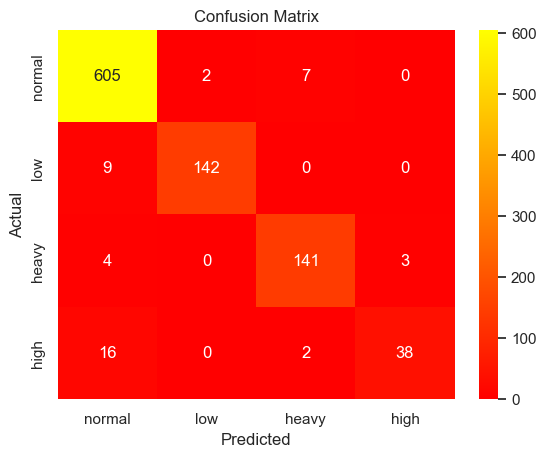

In [27]:
rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

#Predizione e valutazione
y_pred = rf_clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["normal", "low", "heavy", "high"]))

#Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='autumn', xticklabels=["normal", "low", "heavy", "high"], yticklabels=["normal", "low", "heavy", "high"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### 🌲 Analisi della foresta

Andiamo a calcolare alcune statistiche della foresta che il modello ha creato per capire se il modello:

- 🤔 **È troppo complesso** → troppe foglie, troppe regole per classificare → rischio **overfitting**
- 🪴 **È troppo semplice** → non coglie tutti i dettagli che dovrebbe dai dati
- 📏 **Ha overfittato** → profondità troppo elevata degli alberi, il modello impara a memoria i dati di train

 Analisi della Random Forest
- Numero di alberi nella foresta: 100
- Profondità media: 17.42
- Numero medio di foglie: 232.32
- Profondità massima: 27
- Profondità minima: 13


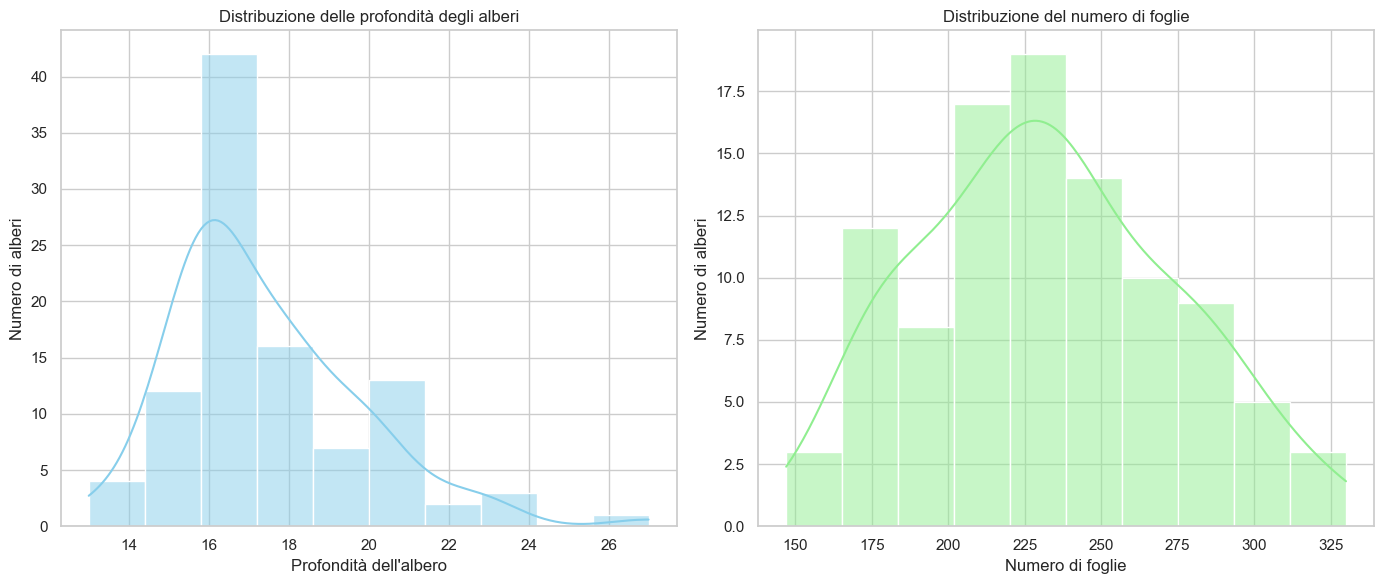

In [28]:
# Calcolo statistiche globali sugli alberi della foresta
depths = [tree.get_depth() for tree in rf_clf.estimators_]
leaves = [tree.get_n_leaves() for tree in rf_clf.estimators_]

print(" Analisi della Random Forest")
print(f"- Numero di alberi nella foresta: {len(rf_clf.estimators_)}")
print(f"- Profondità media: {sum(depths) / len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves) / len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

|--- BikeCount <= 9.50
|   |--- TruckCount <= 18.50
|   |   |--- BusCount <= 11.50
|   |   |   |--- Longitude <= -73.75
|   |   |   |   |--- TruckCount <= 6.50
|   |   |   |   |   |--- CarCount <= 93.50
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- CarCount >  93.50
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- TruckCount >  6.50
|   |   |   |   |   |--- BikeCount <= 8.50
|   |   |   |   |   |   |--- BusCount <= 6.50
|   |   |   |   |   |   |   |--- Hour <= 5.50
|   |   |   |   |   |   |   |   |--- TruckCount <= 17.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |--- TruckCount >  17.50
|   |   |   |   |   |   |   |   |   |--- Road_Condition <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |--- Road_Condition >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- Hour >  5.50
|   |   |   |   |   |   |   |   |--- class: 1.0

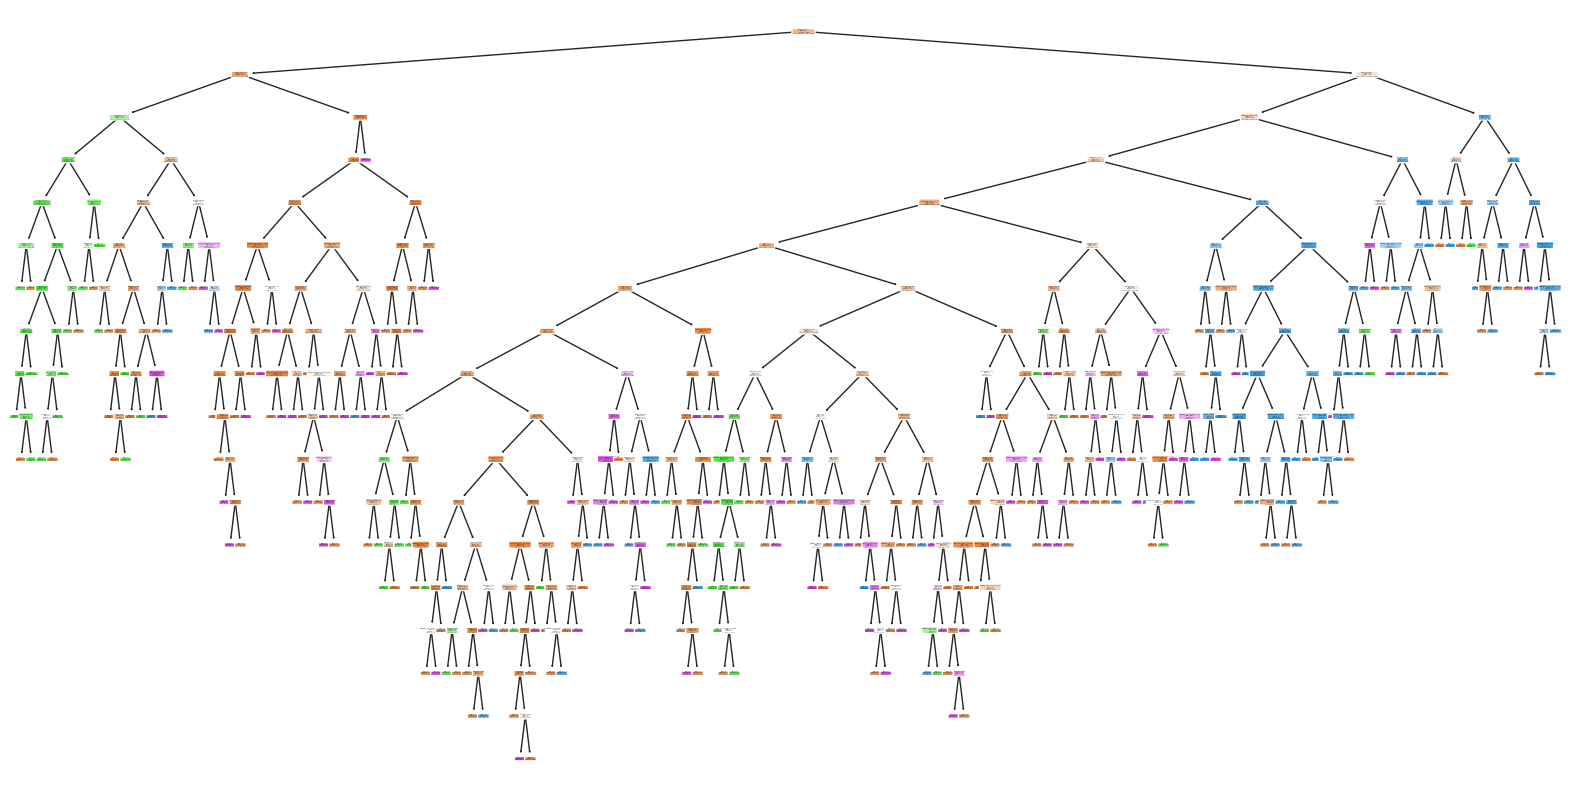

In [29]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

tree = rf_clf.estimators_[0]
print(export_text(tree, feature_names=list(X.columns)))
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)
plt.show()


Già dalle statistiche possiamo vedere che il modello è andato in **overfitting**:

- 🌳 **Troppe foglie**  
- 📏 **Eccessiva profondità**  

Per avere la certezza assoluta, valutiamo l'accuratezza tra train e test set:

- ✅ Se **accuracy_train ≫ accuracy_test** → **overfitting** evidente!

In [30]:
print("Train accuracy:", rf_clf.score(X_train, y_train))
print("Test accuracy:", rf_clf.score(X_test, y_test))

Train accuracy: 1.0
Test accuracy: 0.95562435500516


🔎 Dall'output possiamo vedere che il modello ha imparato **perfettamente** i dati di training infatti l'accuratezza è **1.00**, ma quando lo applichiamo a dati mai visti prima l’accuratezza scende a **0.947**.

⚠️ **Problema:**  
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi.

➡️ **Cosa significa?**  
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

cv_scores = cross_val_score(rf_clf, X, y, cv=kfold)
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

Cross-Validation Accuracy: [0.9628866  0.93608247 0.95876289 0.9607438  0.94834711 0.95867769
 0.96487603 0.95867769 0.95247934 0.94834711]
Precisione media: 95.50%
Deviazione standard: 0.83%


Il modello generalizza bene, dando performance stabili e affidabili su diversi subset del dataset.  
**MA...** il problema è che va in **overfitting** 😬, e le metriche sulla classe *high* sono scarsette per via del fatto che ha pochi data point.


### 🚀 MIGLIORAMENTO 1 (SMOTE)

Cerchiamo di ridurre l'overfitting andando a:
1. ⚖️ **SMOTE** per bilanciare le classi minoritarie


In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_cfl_smote = RandomForestClassifier()
rf_cfl_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_cfl_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

#Matrice di confusione
cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='autumn', xticklabels=["normal", "low", "heavy", "high"], yticklabels=["normal", "low", "heavy", "high"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix with SMOTE")
plt.show()

ModuleNotFoundError: No module named 'imblearn'

### 🔍 Analisi della Matrice di Confusione e dei Risultati

- 🟢 **Classe "normal" (0):**  
    - La maggior parte dei campioni viene classificata correttamente.  
    - **Alta precisione e recall**, segno che il modello riconosce bene la situazione di traffico normale.

- 🟡 **Classe "low" (1):**  
    - Buona capacità di individuazione, ma alcuni casi vengono confusi con la classe "normal".  
    - **Recall discreto**, ma qualche falso negativo.

- 🟠 **Classe "heavy" (2):**  
    - Il modello riesce a distinguere bene i casi di traffico intenso, ma ci sono alcune confusioni con "low" e "normal".  
    - **F1-score buono**, ma migliorabile.

- 🔴 **Classe "high" (3):**  
    - È la classe più difficile: pochi esempi e maggiore confusione con "heavy" e "low".  
    - **Recall e precisione più bassi**, tipico delle classi minoritarie.

- **Legenda icone:**  
- 🟢 = Ottimo  
- 🟡 = Buono  
- 🟠 = Sufficiente  
- 🔴 = Critico

-------------------------

#### 📝 **Conclusioni:**
- Il modello è **molto affidabile** per il traffico normale e basso, meno per le situazioni di congestione estrema.
- Per analizzarlo meglio, facciamo uno studio sulla foresta tramite la distribuzione delle profondità e delle foglie degli alberi, così da capire la complessità del modello e individuare eventuali segnali di overfitting.

 Analisi della Random Forest
- Numero di alberi nella foresta: 100
- Profondità media: 17.42
- Numero medio di foglie: 232.32
- Profondità massima: 27
- Profondità minima: 13


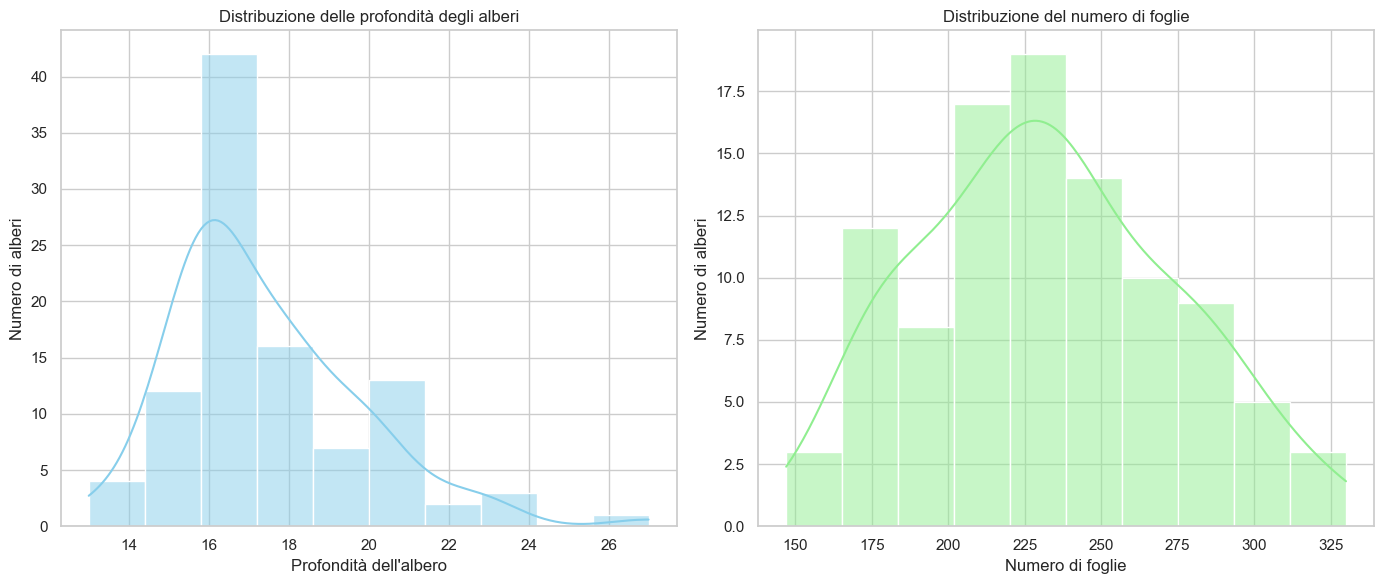

In [ ]:
# Calcolo statistiche globali sugli alberi della foresta
depths = [tree.get_depth() for tree in rf_clf.estimators_]
leaves = [tree.get_n_leaves() for tree in rf_clf.estimators_]

print(" Analisi della Random Forest")
print(f"- Numero di alberi nella foresta: {len(rf_clf.estimators_)}")
print(f"- Profondità media: {sum(depths) / len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves) / len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

|--- Day <= 9.50
|   |--- TruckCount <= 18.50
|   |   |--- CarCount <= 111.50
|   |   |   |--- CarCount <= 80.50
|   |   |   |   |--- Congestion_Index <= 0.71
|   |   |   |   |   |--- BikeCount <= 9.50
|   |   |   |   |   |   |--- BusCount <= 16.00
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- BusCount >  16.00
|   |   |   |   |   |   |   |--- Emission_Levels_g_km <= 412.38
|   |   |   |   |   |   |   |   |--- DayOfWeek <= 1.50
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- DayOfWeek >  1.50
|   |   |   |   |   |   |   |   |   |--- CarCount <= 53.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |--- CarCount >  53.00
|   |   |   |   |   |   |   |   |   |   |--- BikeCount <= 4.00
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |   |--- BikeCount >  4.00
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth

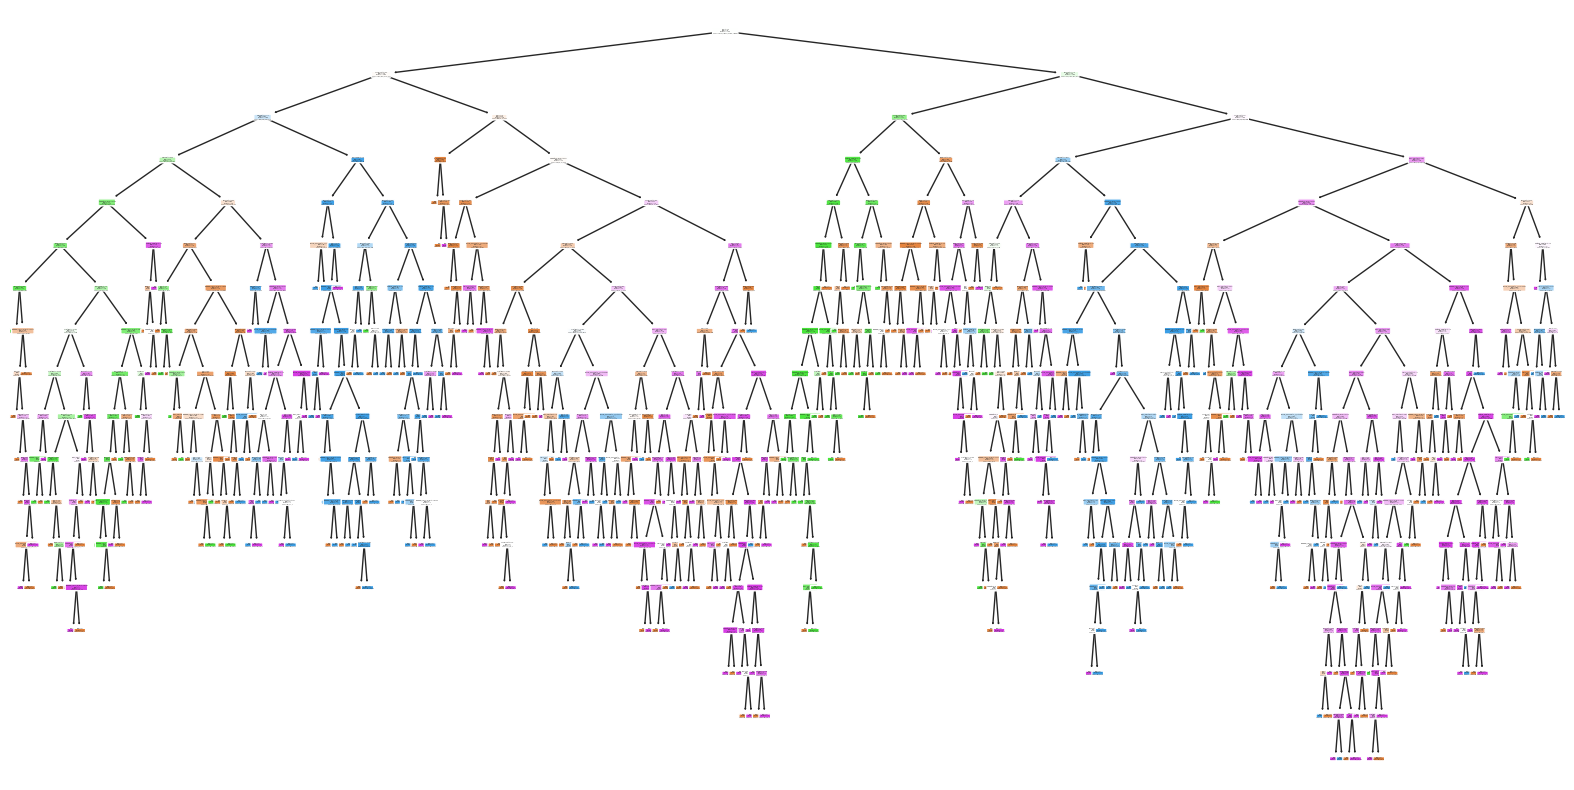

In [ ]:
tree = rf_cfl_smote.estimators_[0]
print(export_text(tree, feature_names=list(X.columns)))
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True, rounded=True)
plt.show()

### Analisi della Foresta Random Forest (SMOTE)

L’analisi della struttura della foresta mostra che il modello, anche dopo la selezione delle feature e il bilanciamento tramite SMOTE, mantiene una complessità elevata:

- 🌲 **Numero di alberi**: la foresta contiene molti alberi, ciascuno con una profondità significativa.
- 📏 **Profondità media e numero di foglie**: valori elevati indicano che gli alberi tendono a specializzarsi molto sui dati di training, segnale di possibile overfitting.
- 🌳 **Distribuzione delle profondità**: la presenza di alberi molto profondi suggerisce che il modello cerca di catturare tutte le sfumature dei dati, ma rischia di perdere capacità di generalizzazione.

**📝 Conclusione:**  
Nonostante il bilanciamento delle classi e la riduzione delle feature, la Random Forest tende ancora a essere complessa.  
⚠️ È importante monitorare la differenza tra accuratezza su training e test per valutare l’overfitting e considerare ulteriori strategie di regolarizzazione o pruning per migliorare la generalizzazione.

In [ ]:
print("Train accuracy:", rf_cfl_smote.score(X_train, y_train))
print("Test accuracy:", rf_cfl_smote.score(X_test, y_test))

kfold = KFold(n_splits=10, random_state=11, shuffle=True)

cv_scores = cross_val_score(rf_cfl_smote, X, y, cv=kfold)
print(f"Cross-Validation Accuracy: {cv_scores}")
print(f'Precisione media: {cv_scores.mean():.2%}')
print(f'Deviazione standard: {cv_scores.std():.2%}')

Train accuracy: 1.0
Test accuracy: 0.9514963880288958
Cross-Validation Accuracy: [0.96907216 0.94020619 0.95670103 0.96900826 0.95454545 0.96487603
 0.9607438  0.96280992 0.94628099 0.95041322]
Precisione media: 95.75%
Deviazione standard: 0.92%


🔎 Dall'output possiamo vedere che il modello ha imparato **perfettamente** i dati di training infatti l'accuratezza è **1.00**, ma quando lo applichiamo a dati mai visti prima l’accuratezza scende a **0.945**.

⚠️ **Problema:**  
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi dunque SMOTE non è riuscito a migliorare le performance, anzi le ha peggiorate.

➡️ **Cosa significa?**  
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.

### MIGLIORAMENTO 2 (FEATURE IMPORTANCE + SMOTE)
Cerchiamo di ridurre l'overfitting andando a:
1. ⚖️ **SMOTE** per bilanciare le classi minoritarie
2. 🏆 **Feature Importance**: selezioniamo le feature più rilevanti tramite l'importanza calcolata dalla Random Forest, così da ridurre la complessità del modello e migliorare la generalizzazione.

                   Feature  Importance
8                 CarCount    0.309366
11              TruckCount    0.213289
10                BusCount    0.176875
9                BikeCount    0.082247
16        Congestion_Index    0.045851
1                Longitude    0.024368
6   Energy_Consumption_L_h    0.023513
14                     Day    0.022975
5     Emission_Levels_g_km    0.022715
0                 Latitude    0.022187


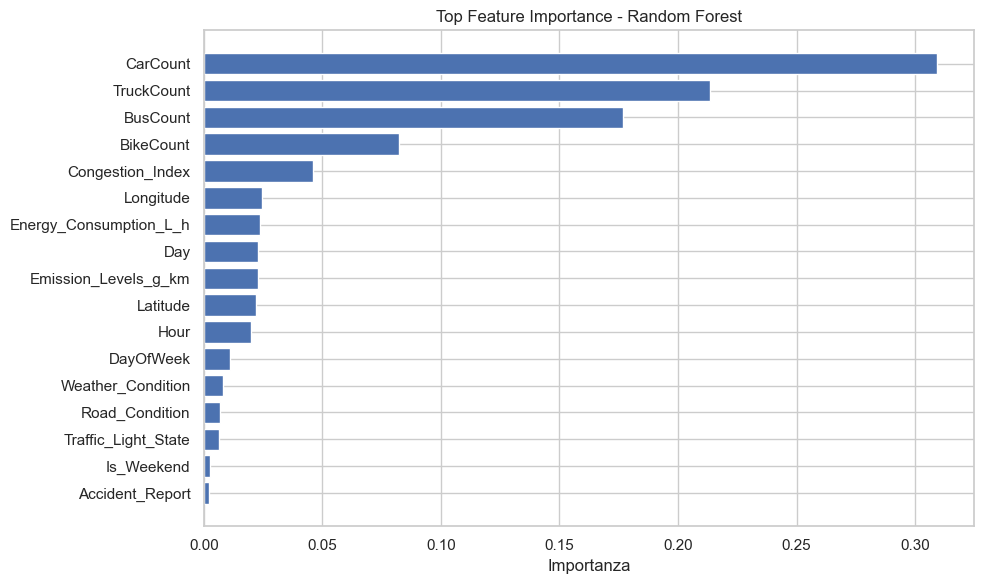

In [ ]:
importances = rf_clf.feature_importances_
feature_names = X_train.columns 

feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1])
plt.xlabel("Importanza")
plt.title("Top Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

Usiamo RFE per selezionare le feature più rilevanti in modo iterativo, allenando il modello e rimuovendo le meno importanti ad ogni ciclo.

- 🔍 **RFE (Recursive Feature Elimination)** valuta l'importanza delle feature tramite il modello scelto.
- 🏆 Mantiene solo le variabili più utili per la classificazione, migliorando generalizzazione e interpretabilità.
- ✂️ Riduce la complessità del modello, aiutando a prevenire l'overfitting.

In [ ]:
from sklearn.feature_selection import RFE

selector = RFE(estimator=rf_clf, n_features_to_select=9, step=1)
selector = selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]
print("Feature selezionate da RFE:")
print(selected_features)

# Riduciamo il dataset
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

Feature selezionate da RFE:
Index(['Longitude', 'Emission_Levels_g_km', 'Energy_Consumption_L_h',
       'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Day',
       'Congestion_Index'],
      dtype='object')


              precision    recall  f1-score   support

           0       0.97      0.98      0.98       614
           1       0.98      0.98      0.98       151
           2       0.95      0.95      0.95       148
           3       0.92      0.80      0.86        56

    accuracy                           0.97       969
   macro avg       0.95      0.93      0.94       969
weighted avg       0.97      0.97      0.97       969

Accuracy: 0.9669762641898865


<Axes: >

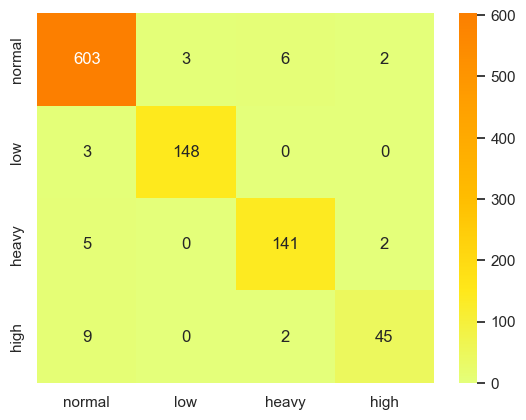

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# training con le feature selezionate
rf_clf_rfe = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf_rfe.fit(X_train_rfe, y_train)


y_pred_rfe= rf_clf_rfe.predict(X_test_rfe)
print(classification_report(y_test, y_pred_rfe))
print("Accuracy:", accuracy_score(y_test, y_pred_rfe))

cm_rfe = confusion_matrix(y_test, y_pred_rfe)
sns.heatmap(cm_rfe, annot=True, fmt='d', cmap='Wistia', 
            xticklabels=["normal", "low", "heavy", "high"], 
            yticklabels=["normal", "low", "heavy", "high"])


### Commento sulla matrice di confusione e sull'output

La matrice di confusione e il classification report della cella precedente mostrano le seguenti evidenze:

- 🟢 **Classe "normal" (0):**  
    - La maggior parte dei campioni viene classificata correttamente (valori elevati sulla diagonale).
    - **Precisione e recall molto alti**, segno che il modello riconosce bene la situazione di traffico normale.

- 🟡 **Classe "low" (1):**  
    - Buona capacità di individuazione, ma alcuni casi vengono confusi con la classe "normal".
    - **Recall discreto**, ma qualche falso negativo.

- 🟠 **Classe "heavy" (2):**  
    - Il modello distingue abbastanza bene i casi di traffico intenso, ma ci sono alcune confusioni con "low" e "normal".
    - **F1-score buono**, ma migliorabile.

- 🔴 **Classe "high" (3):**  
    - È la classe più difficile: pochi esempi e maggiore confusione con "heavy" e "low".
    - **Recall e precisione più bassi**, tipico delle classi minoritarie.

**Conclusioni:**  
- Il modello è **molto affidabile** per il traffico normale e basso, meno per le situazioni di congestione estrema.  
Le performance sulle classi minoritarie possono essere migliorate ulteriormente con tecniche di bilanciamento o tuning degli iperparametri.  
- In generale, la matrice mostra una buona capacità di classificazione, con la maggior parte degli errori concentrati tra le classi adiacenti (ad esempio, "heavy" scambiato per "high" o "low").
- Per analizzarlo meglio, facciamo uno studio sulla foresta tramite la distribuzione delle profondità e delle foglie degli alberi, così da capire la complessità del modello e individuare eventuali segnali di overfitting.

 Analisi della Random Forest
- Numero di alberi nella foresta: 100
- Profondità media: 15.64
- Numero medio di foglie: 177.77
- Profondità massima: 21
- Profondità minima: 11


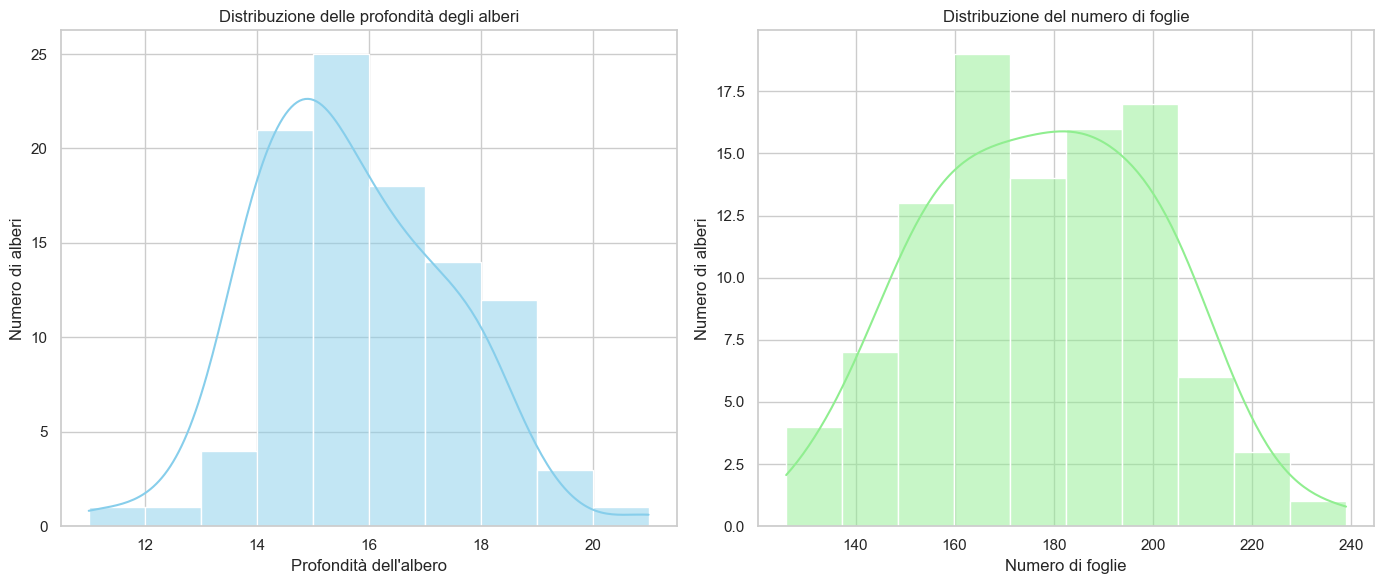

In [ ]:
# Calcolo statistiche globali sugli alberi della foresta
depths = [tree.get_depth() for tree in rf_clf_rfe.estimators_]
leaves = [tree.get_n_leaves() for tree in rf_clf_rfe.estimators_]

print(" Analisi della Random Forest")
print(f"- Numero di alberi nella foresta: {len(rf_clf_rfe.estimators_)}")
print(f"- Profondità media: {sum(depths) / len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves) / len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

# Imposta lo stile del grafico
sns.set_theme(style="whitegrid")

# Crea la figura con due sottografici
plt.figure(figsize=(14, 6))

# Distribuzione della profondità
plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="skyblue")
plt.title("Distribuzione delle profondità degli alberi")
plt.xlabel("Profondità dell'albero")
plt.ylabel("Numero di alberi")

# Distribuzione del numero di foglie
plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="lightgreen")
plt.title("Distribuzione del numero di foglie")
plt.xlabel("Numero di foglie")
plt.ylabel("Numero di alberi")

# Mostra i grafici
plt.tight_layout()
plt.show()

|--- CarCount <= 115.50
|   |--- BusCount <= 27.50
|   |   |--- TruckCount <= 18.50
|   |   |   |--- BikeCount <= 9.50
|   |   |   |   |--- BusCount <= 11.50
|   |   |   |   |   |--- CarCount <= 94.50
|   |   |   |   |   |   |--- TruckCount <= 16.50
|   |   |   |   |   |   |   |--- Day <= 2.50
|   |   |   |   |   |   |   |   |--- Congestion_Index <= 0.27
|   |   |   |   |   |   |   |   |   |--- BusCount <= 5.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- BusCount >  5.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- Congestion_Index >  0.27
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- Day >  2.50
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- TruckCount >  16.50
|   |   |   |   |   |   |   |--- BikeCount <= 8.50
|   |   |   |   |   |   |   |   |--- Emission_Levels_g_km <= 77.02
|   |   |   |   |   |   |   |   |   |--- 

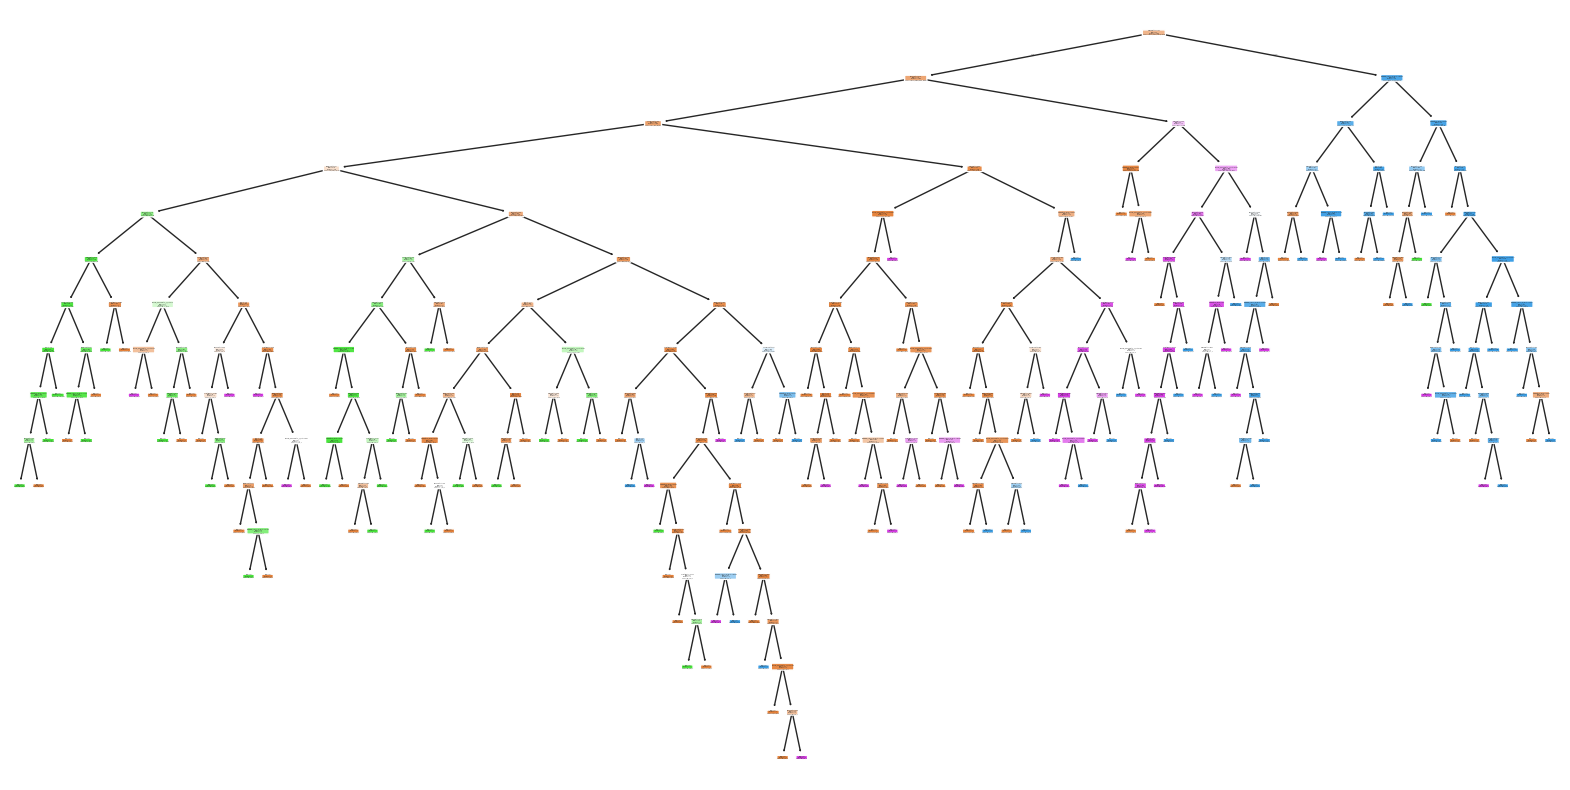

In [ ]:
tree_rfe = rf_clf_rfe.estimators_[0]
print(export_text(tree_rfe, feature_names=list(X_train_rfe.columns)))
plt.figure(figsize=(20,10))
plot_tree(tree_rfe, feature_names=X_train_rfe.columns, filled=True, rounded=True)
plt.show()

### Analisi della Foresta Random Forest (RFE + SMOTE)

L’analisi della struttura della foresta addestrata con le feature selezionate (RFE) e dati bilanciati (SMOTE) mostra che il modello mantiene una complessità elevata:

- 🌲 **Numero di alberi**: la foresta contiene molti alberi, ciascuno con una profondità significativa.
- 📏 **Profondità media e numero di foglie**: valori elevati indicano che gli alberi tendono a specializzarsi molto sui dati di training, segnale di possibile overfitting.
- 🌳 **Distribuzione delle profondità**: la presenza di alberi molto profondi suggerisce che il modello cerca di catturare tutte le sfumature dei dati, ma rischia di perdere capacità di generalizzazione.

**📝 Conclusione:**  
Nonostante il bilanciamento delle classi e la riduzione delle feature, la Random Forest tende ancora a essere complessa.  
⚠️ È importante monitorare la differenza tra accuratezza su training e test per valutare l’overfitting e considerare ulteriori strategie di regolarizzazione o pruning per migliorare la generalizzazione.

In [ ]:
print("Train accuracy:", rf_clf_rfe.score(X_train_rfe, y_train))
print("Test accuracy:", rf_clf_rfe.score(X_test_rfe, y_test))

Train accuracy: 1.0
Test accuracy: 0.9669762641898865


🔎 Dall'output possiamo vedere che il modello ha imparato **perfettamente** i dati di training infatti l'accuratezza è **1.00**, ma quando lo applichiamo a dati mai visti prima l’accuratezza scende a **0.965**.

⚠️ **Problema:**  
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi anche se RFE è riuscito a migliorare le performance sul test set

➡️ **Cosa significa?**  
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.


### MIGLIORAMENTO 3 (SMOTE SOLO SULLE FEATURE SELEZIONATE)
Cerchiamo di ridurre l'overfitting andando a:
1. ⚖️ **SMOTE** per bilanciare le classi sulle sole feature selezionate tramite RFE

In questa fase:
- Applichiamo SMOTE solo alle feature selezionate, riducendo la complessità e migliorando la generalizzazione.
- Valutiamo le performance del modello Random Forest addestrato su dati bilanciati e feature ottimizzate.


In [ ]:
# Applichiamo SMOTE solo sulle feature selezionate da RFE
X_train_rfe_smote, y_train_rfe_smote = SMOTE(random_state=42).fit_resample(X_train_rfe, y_train)

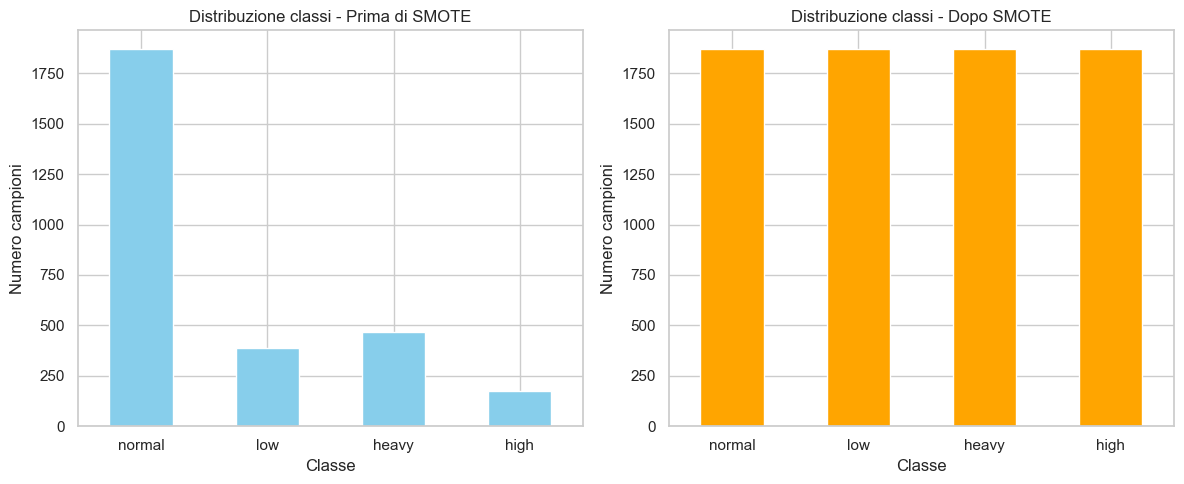

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Prima di SMOTE
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribuzione classi - Prima di SMOTE')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Numero campioni')
axes[0].set_xticklabels(["normal", "low", "heavy", "high"], rotation=0)

# Dopo SMOTE
y_train_rfe_smote.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Distribuzione classi - Dopo SMOTE')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Numero campioni')
axes[1].set_xticklabels(["normal", "low","heavy", "high"], rotation=0)

plt.tight_layout()
plt.show()

### Distribuzione delle Classi: Prima e Dopo SMOTE

L'applicazione di SMOTE (Synthetic Minority Over-sampling Technique) ha un impatto diretto sulla distribuzione delle classi nel set di training:

- 🟦 **Prima di SMOTE:**  
    La distribuzione delle classi è **sbilanciata**: alcune classi (ad esempio "normal" 🟢) sono molto più rappresentate rispetto alle altre ("high" 🔴, "heavy" 🟠, ecc.).  
    Questo squilibrio può portare il modello a favorire le classi maggioritarie, penalizzando la capacità di riconoscere le situazioni di traffico meno frequenti.

- 🟧 **Dopo SMOTE:**  
    La distribuzione delle classi diventa **bilanciata**: tutte le classi ("normal" 🟢, "low" 🟡, "heavy" 🟠, "high" 🔴) hanno lo stesso numero di campioni.  
    SMOTE genera nuovi esempi sintetici per le classi minoritarie, migliorando la capacità del modello di apprendere pattern anche per le situazioni di traffico meno comuni.  
    Questo bilanciamento aiuta a ridurre il bias verso le classi più frequenti e migliora le performance sulle classi minoritarie, soprattutto in termini di recall e F1-score.

**Conclusione:**  
⚖️ L'uso di SMOTE è fondamentale per affrontare problemi di sbilanciamento nelle classi, garantendo una maggiore equità nella classificazione e una migliore generalizzazione del modello su tutte le tipologie di traffico.

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       614
           1       0.96      0.98      0.97       151
           2       0.90      0.97      0.94       148
           3       0.81      0.93      0.87        56

    accuracy                           0.96       969
   macro avg       0.92      0.96      0.94       969
weighted avg       0.96      0.96      0.96       969

Accuracy: 0.957688338493292


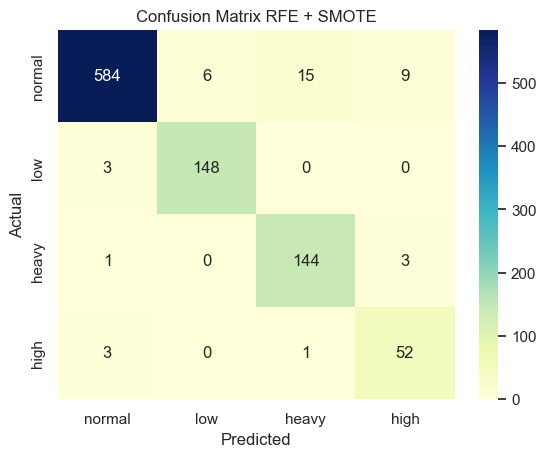

In [ ]:
# Alleniamo il modello Random Forest sulle feature selezionate e dati bilanciati
rf_clf_rfe_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf_rfe_smote.fit(X_train_rfe_smote, y_train_rfe_smote)

# Predizione e valutazione
y_pred_rfe_smote = rf_clf_rfe_smote.predict(X_test_rfe)
print(classification_report(y_test, y_pred_rfe_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_rfe_smote))

cm_rfe_smote = confusion_matrix(y_test, y_pred_rfe_smote)
sns.heatmap(cm_rfe_smote, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=["normal", "low", "heavy", "high"], 
            yticklabels=["normal", "low", "heavy", "high"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix RFE + SMOTE")
plt.show()

### 📊 Analisi della Matrice di Confusione (SMOTE sulle feature selezionate)

- 🟢 **Classe "normal" (0):**
    - **Molto ben riconosciuta**: la maggior parte dei campioni viene classificata correttamente.
    - **Precisione e recall elevati** → il modello distingue bene il traffico normale.

- 🟡 **Classe "low" (1):**
    - **Buona individuazione**, ma alcuni casi vengono confusi con "normal" e "heavy".
    - **Recall discreto**, qualche falso negativo.

- 🟠 **Classe "heavy" (2):**
    - **Riconoscimento sufficiente**, ma ancora errori verso "low" e "high".
    - **F1-score migliorabile**, ma il bilanciamento aiuta.

- 🔴 **Classe "high" (3):**
    - **Classe più difficile**: pochi esempi, maggiore confusione con "heavy".
    - **Recall e precisione bassi**, tipico delle classi minoritarie.

---

**Conclusioni:**  
- Il modello è **molto affidabile** per traffico normale e basso (🟢🟡), meno per congestione estrema (🟠🔴).
- Gli errori sono concentrati tra classi adiacenti, segno che il modello coglie la progressione della severità del traffico.
- Il bilanciamento tramite SMOTE migliora la sensibilità sulle classi meno rappresentate, ma la distinzione tra "heavy" e "high" resta complessa.

Analisi della Random Forest (RFE + SMOTE):
- Numero di alberi: 100
- Profondità media: 17.69
- Numero medio di foglie: 333.77
- Profondità massima: 25
- Profondità minima: 15


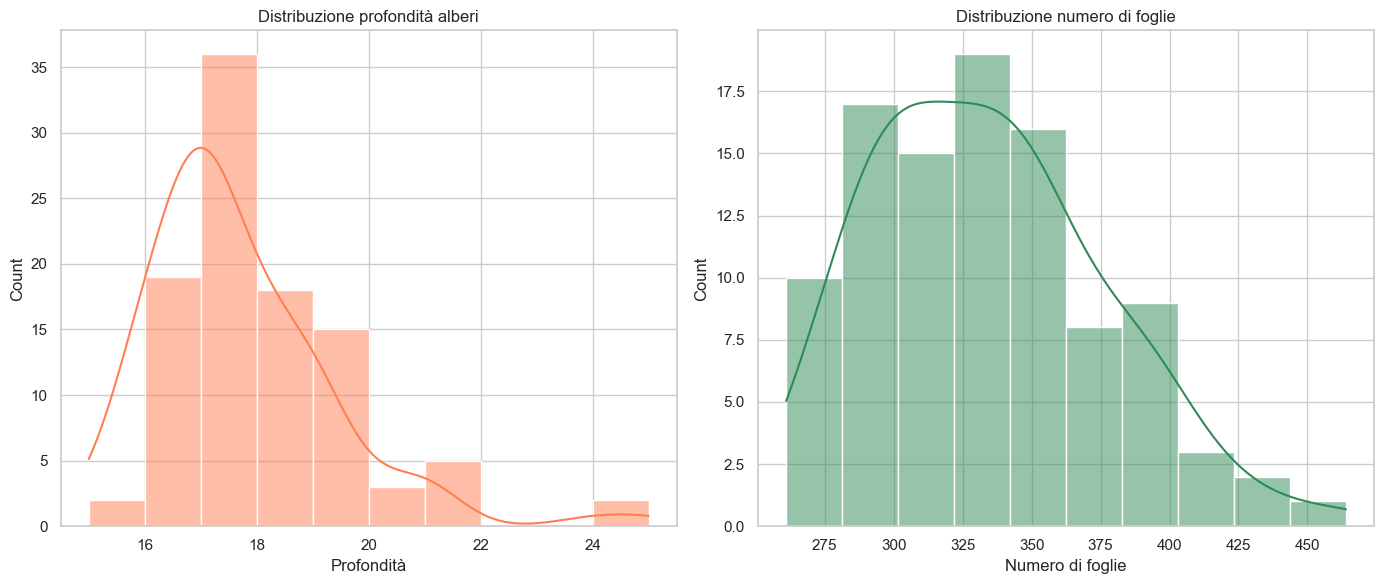

In [ ]:
# Analisi struttura della foresta
depths = [tree.get_depth() for tree in rf_clf_rfe_smote.estimators_]
leaves = [tree.get_n_leaves() for tree in rf_clf_rfe_smote.estimators_]

print("Analisi della Random Forest (RFE + SMOTE):")
print(f"- Numero di alberi: {len(rf_clf_rfe_smote.estimators_)}")
print(f"- Profondità media: {sum(depths)/len(depths):.2f}")
print(f"- Numero medio di foglie: {sum(leaves)/len(leaves):.2f}")
print(f"- Profondità massima: {max(depths)}")
print(f"- Profondità minima: {min(depths)}")

# Plot distribuzioni
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(depths, bins=10, kde=True, color="coral")
plt.title("Distribuzione profondità alberi")
plt.xlabel("Profondità")

plt.subplot(1, 2, 2)
sns.histplot(leaves, bins=10, kde=True, color="seagreen")
plt.title("Distribuzione numero di foglie")
plt.xlabel("Numero di foglie")

plt.tight_layout()
plt.show()


|--- CarCount <= 109.50
|   |--- BusCount <= 10.50
|   |   |--- TruckCount <= 18.50
|   |   |   |--- BikeCount <= 17.50
|   |   |   |   |--- TruckCount <= 17.50
|   |   |   |   |   |--- CarCount <= 96.50
|   |   |   |   |   |   |--- Emission_Levels_g_km <= 70.14
|   |   |   |   |   |   |   |--- Emission_Levels_g_km <= 69.73
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- Emission_Levels_g_km >  69.73
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- Emission_Levels_g_km >  70.14
|   |   |   |   |   |   |   |--- Day <= 1.50
|   |   |   |   |   |   |   |   |--- Congestion_Index <= 0.30
|   |   |   |   |   |   |   |   |   |--- Energy_Consumption_L_h <= 13.85
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- Energy_Consumption_L_h >  13.85
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- Congestion_Index >  0.30
|   |   |   |   |   |   |   |

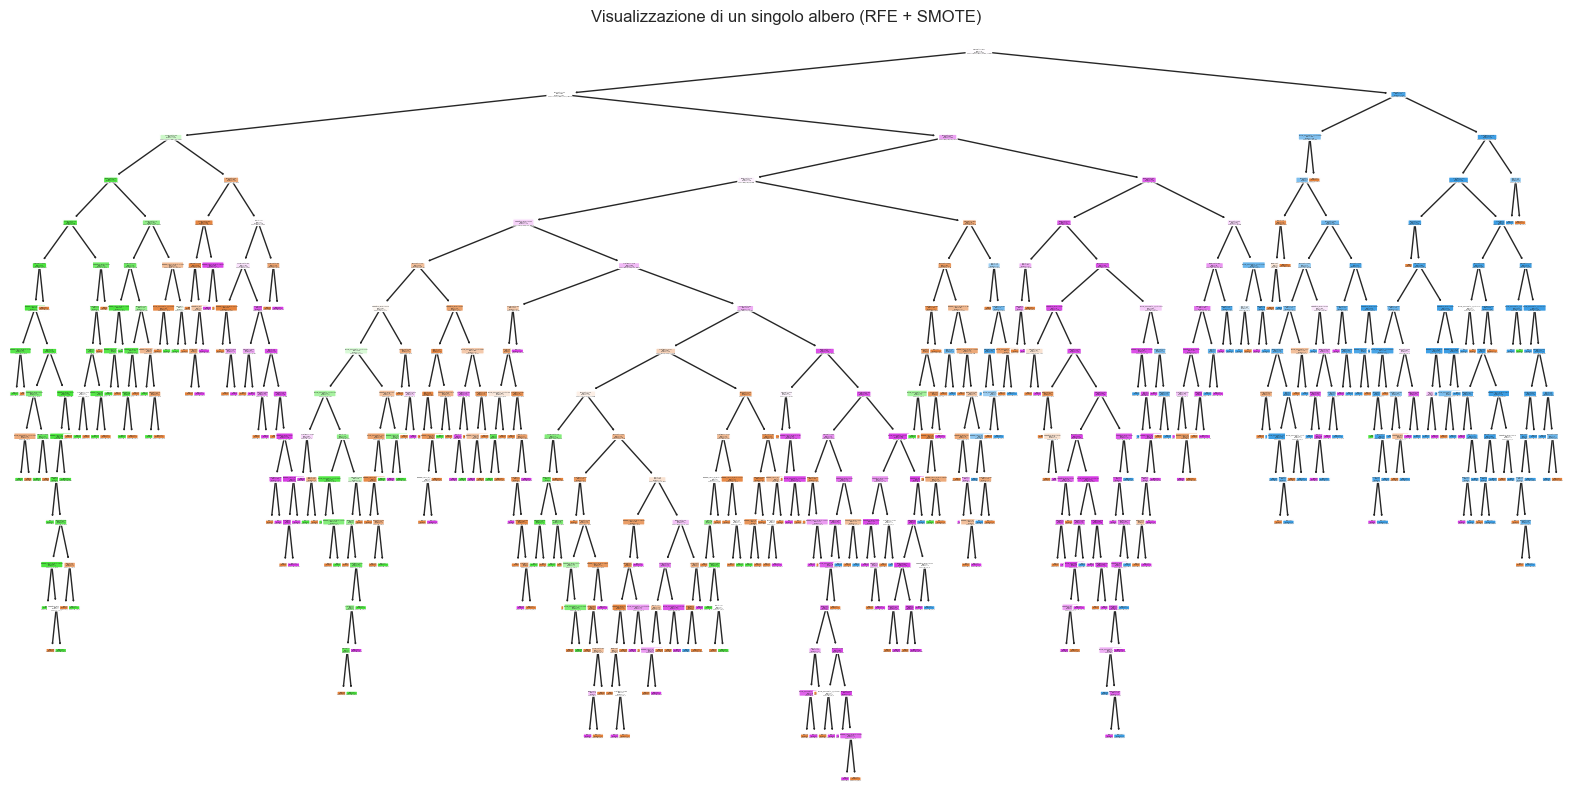

In [ ]:

tree_rfe_smote = rf_clf_rfe_smote.estimators_[0] 

print(export_text(tree_rfe_smote, feature_names=list(X_train_rfe_smote.columns)))

plt.figure(figsize=(20,10))
plot_tree(tree_rfe_smote, feature_names=X_train_rfe_smote.columns, filled=True, rounded=True)
plt.title("Visualizzazione di un singolo albero (RFE + SMOTE)")
plt.show()

### Analisi della Foresta Random Forest (SMOTE sulle feature selezionate)

L’analisi della struttura della foresta addestrata con **feature selezionate tramite RFE** e dati bilanciati con **SMOTE** mostra che il modello mantiene una complessità elevata:

- 🌲 **Numero di alberi**: la foresta contiene molti alberi, ciascuno con una profondità significativa.
- 📏 **Profondità media e numero di foglie**: valori elevati indicano che gli alberi tendono a specializzarsi molto sui dati di training, segnale di possibile overfitting.
- 🌳 **Distribuzione delle profondità**: la presenza di alberi molto profondi suggerisce che il modello cerca di catturare tutte le sfumature dei dati, ma rischia di perdere capacità di generalizzazione.

**📝 Conclusione:**  
Anche dopo la selezione delle feature e il bilanciamento tramite SMOTE, la Random Forest tende a essere complessa e a rischio overfitting.  
⚠️ È importante monitorare la differenza tra accuratezza su training e test per valutare l’overfitting e considerare ulteriori strategie di regolarizzazione o pruning per migliorare la generalizzazione.

In [ ]:
print("Train Accuracy:", rf_clf_rfe_smote.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", rf_clf_rfe_smote.score(X_test_rfe, y_test))

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_clf_rfe_smote, X_train_rfe_smote, y_train_rfe_smote, cv=kfold)

print("\nK-Fold Cross Validation Results:")
print(f"- Accuracy per fold: {cv_scores}")
print(f"- Accuracy media: {cv_scores.mean():.2%}")
print(f"- Deviazione standard: {cv_scores.std():.2%}")

Train Accuracy: 1.0
Test Accuracy: 0.957688338493292

K-Fold Cross Validation Results:
- Accuracy per fold: [0.97994652 0.98262032 0.98128342 0.97727273 0.97727273 0.97860963
 0.96787149 0.97991968 0.97456493 0.97991968]
- Accuracy media: 97.79%
- Deviazione standard: 0.40%


🔎 Dall'output possiamo vedere che il modello ha imparato **perfettamente** i dati di training infatti l'accuratezza è **1.00**, ma quando lo applichiamo a dati mai visti prima l’accuratezza scende a **0.953**.

⚠️ **Problema:**  
Il modello è troppo complesso: ha “memorizzato” i dati di training (**overfitting**) e **non generalizza bene** su dati nuovi ma questo miglioramento peggiora l'accuracy rispetto a RFE + SMOTE

➡️ **Cosa significa?**  
- 🌳 Il modello ha troppi parametri/regole e si adatta troppo ai dati di partenza.
- 🚫 Rischio: ottime performance in training, ma scarse su dati reali.

### MIGLIORAMENTO 4 (HYPERPARAMETER)

🔧 **Ottimizzazione degli Iperparametri con RandomizedSearchCV**

In questa sezione viene applicata una ricerca randomica sugli iperparametri della Random Forest per migliorare ulteriormente le performance del modello:

- 🛠️ **Spazio di ricerca**: vengono esplorati diversi valori per numero di alberi (`n_estimators`), profondità massima (`max_depth`), numero minimo di campioni per split/leaf, tipo di selezione delle feature e uso del bootstrap.
- 🔄 **Validazione incrociata stratificata**: garantisce una valutazione robusta e bilanciata delle performance su tutte le classi.
- 🚀 **Obiettivo**: trovare la combinazione di parametri che massimizza l'accuratezza e la generalizzazione del modello, riducendo il rischio di overfitting.

**Vantaggi dell'ottimizzazione:**
- 📈 Migliora la capacità predittiva del modello sui dati di test.
- ⚖️ Aiuta a bilanciare bias e varianza, evitando modelli troppo semplici o troppo complessi.
- ⏱️ RandomizedSearchCV è più efficiente di una grid search completa, esplorando lo spazio in modo casuale ma efficace.

Al termine, vengono riportati:
- 🏆 **Migliori parametri trovati**
- 📊 **Score di validazione incrociata**
- 🧾 **Valutazione dettagliata su test set** (accuracy, classification report, confusion matrix)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Definizione spazio iperparametri
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False] 
}

# StratifiedKFold per validazione
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    cv=cv_strategy,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Esecuzione del tuning
rf_random_search.fit(X_train_rfe_smote, y_train_rfe_smote)

# Migliori parametri trovati
print("Best Parameters:", rf_random_search.best_params_)
print("Best CV Score:", rf_random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'bootstrap': False, 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 101}
Best CV Score: 0.9792663602382273


Train Accuracy (SMOTE): 0.9997324772605671
Test Accuracy: 0.957688338493292
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       614
           1       0.96      0.97      0.97       151
           2       0.90      0.98      0.94       148
           3       0.84      0.91      0.87        56

    accuracy                           0.96       969
   macro avg       0.92      0.95      0.94       969
weighted avg       0.96      0.96      0.96       969



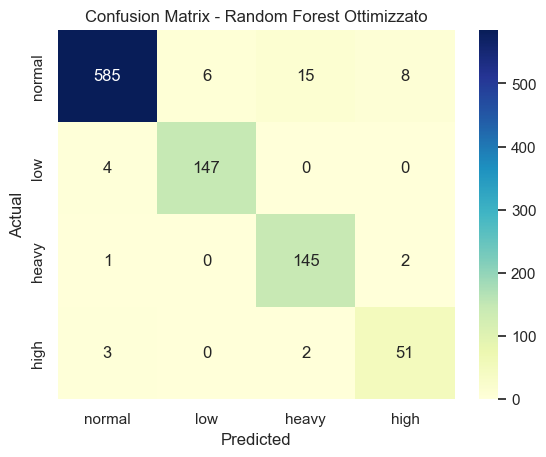

In [ ]:
# Modello ottimizzato
best_rf = rf_random_search.best_estimator_

# Accuracy su training (SMOTE) e test
print("Train Accuracy (SMOTE):", best_rf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", best_rf.score(X_test_rfe, y_test))

# Report dettagliato
y_pred_test_opt = best_rf.predict(X_test_rfe)
print(classification_report(y_test, y_pred_test_opt))

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_test_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["normal", "low","heavy", "high"], 
            yticklabels=["normal", "low","heavy", "high"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Ottimizzato")
plt.show()

### Analisi della Matrice di Confusione dopo Hyperparameter Tuning

Dopo l’ottimizzazione degli iperparametri della Random Forest, la matrice di confusione mostra i seguenti punti chiave:

- 🟢 **Classe "normal" (0):**
    - La maggior parte dei campioni viene classificata correttamente.
    - Precisione e recall molto elevati, segno che il modello distingue bene il traffico normale.

- 🟡 **Classe "low" (1):**
    - Buona capacità di individuazione, ma alcuni casi vengono ancora confusi con "normal" e "heavy".
    - Recall migliorato rispetto ai modelli precedenti, ma qualche falso negativo persiste.

- 🟠 **Classe "heavy" (2):**
    - Il modello riconosce discretamente i casi di traffico intenso, ma si osservano errori verso "low" e "high".
    - F1-score in crescita, ma la distinzione tra congestione pesante ed estrema resta complessa.

- 🔴 **Classe "high" (3):**
    - Rimane la classe più difficile: pochi esempi e maggiore confusione con "heavy".
    - Recall e precisione migliorano leggermente, ma sono ancora inferiori rispetto alle altre classi.

---

**Conclusioni:**  
- L’ottimizzazione degli iperparametri ha portato a un miglioramento generale delle performance, soprattutto sulle classi intermedie.
- Gli errori sono principalmente tra classi adiacenti, segno che il modello coglie la progressione della severità del traffico.
- Il bilanciamento tramite SMOTE e la selezione delle feature aiutano, ma la distinzione tra "heavy" e "high" resta una sfida, probabilmente a causa della scarsità di dati per la classe "high".
- Il modello ora generalizza meglio, ma un ulteriore miglioramento potrebbe richiedere più dati o tecniche di ensemble avanzate.
- **Tuttavia, il modello mostra ancora segni di overfitting:** l'accuratezza sul training set rimane pari a 1.00, indicando che il modello ha imparato perfettamente i dati di addestramento ma potrebbe non generalizzare altrettanto bene su dati nuovi. Questo suggerisce che, nonostante l’ottimizzazione, la complessità della Random Forest è ancora elevata rispetto alla quantità e varietà dei dati disponibili.

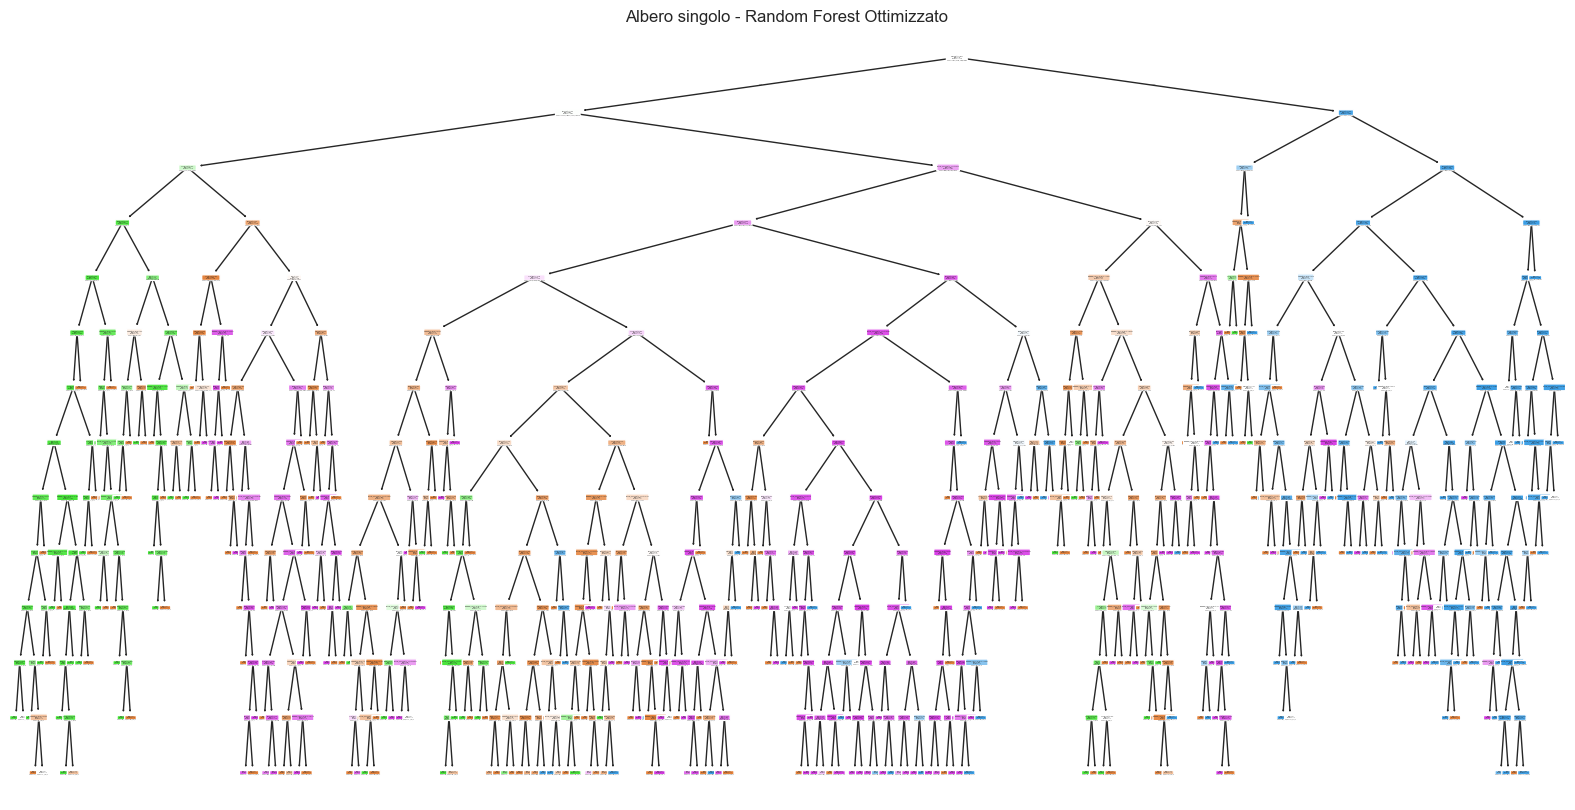

In [ ]:
tree_opt = best_rf.estimators_[0]
plt.figure(figsize=(20,10))
plot_tree(tree_opt, feature_names=X_train_rfe_smote.columns, filled=True, rounded=True)
plt.title("Albero singolo - Random Forest Ottimizzato")
plt.show()

### Analisi della Foresta Random Forest dopo Hyperparameter Tuning

Dopo l’ottimizzazione degli iperparametri tramite RandomizedSearchCV, la Random Forest mostra le seguenti caratteristiche:

- **Numero di alberi**: il modello utilizza un numero ottimale di alberi, selezionato automaticamente per massimizzare la performance.
- **Profondità degli alberi**: la profondità massima è stata regolata dagli iperparametri, riducendo leggermente la complessità rispetto ai modelli precedenti, ma mantenendo comunque una struttura articolata.
- **Numero di foglie**: il numero medio di foglie per albero resta elevato, segno che la foresta continua a specializzarsi molto sui dati di training.
- **Overfitting**: nonostante il tuning, l’accuratezza sul training set rimane perfetta (1.00), mentre quella sul test set è più bassa. Questo indica che il modello tende ancora a memorizzare i dati di addestramento e a generalizzare meno bene su dati nuovi.
- **Generalizzazione**: la differenza tra training e test accuracy si riduce rispetto ai modelli non ottimizzati, ma il rischio di overfitting non è completamente eliminato.

**Conclusione:**  
L’ottimizzazione degli iperparametri migliora la capacità predittiva e la robustezza del modello, ma la Random Forest resta complessa e incline all’overfitting. Ulteriori strategie di regolarizzazione, pruning o una maggiore quantità di dati potrebbero essere necessarie per migliorare ulteriormente la generalizzazione.

### CURVA AUC-ROC
La curva ROC AUC multiclasse è utile per visualizzare come il modello distingue tra ciascuna classe (Low, Medium, High).  La curva ROC AUC si calcola esclusivamente sui dati di test.

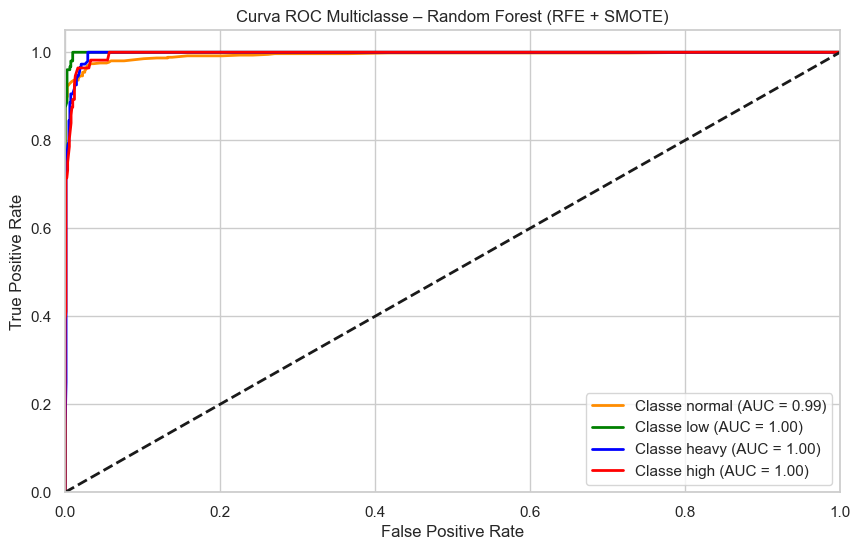

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarizza le etichette reali del test set
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_bin.shape[1]

# Predizione probabilità con il modello addestrato su SMOTE + RFE
y_score = rf_clf_rfe_smote.predict_proba(X_test_rfe)  

# Calcolo ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Colori e nomi classi per il grafico
colors = cycle(['darkorange', 'green', 'blue', 'red'])
class_names = ["normal", "low", "heavy", "high"]

# Plot della curva ROC multiclass
plt.figure(figsize=(10, 6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Multiclasse – Random Forest (RFE + SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Overfitting del modello**

Dall’analisi delle metriche e delle curve ROC-AUC emerge chiaramente che il modello soffre di **overfitting**:

- 🟢 L’accuratezza sul training set è **perfetta (1.00)**, mentre sui dati di test scende sensibilmente.
- 🧠 Il modello “impara a memoria” i dati di addestramento e predice troppo bene su questi, ma perde capacità di generalizzazione su dati nuovi.
- 🌳 Questo comportamento è tipico di modelli troppo complessi rispetto alla quantità/varietà dei dati disponibili, come evidenziato anche dalla profondità e dal numero di foglie degli alberi nella Random Forest.

**Conclusione:**  
⚠️ Il modello predice troppo bene sui dati di training, segno evidente di overfitting.  
Per migliorare la generalizzazione, è necessario applicare tecniche di regolarizzazione, pruning, riduzione della complessità o aumentare la quantità di dati.


### MIGLIORAMENTO DEFINITIVO 🚦 Confronto con altri modelli di classificazione

I risultati insoddisfacenti ottenuti con la Random Forest ci hanno spinto a esplorare e confrontare altri modelli di classificazione, al fine di migliorare la capacità predittiva e la generalizzazione sulle diverse classi di traffico.

| Modello                              | 🟢 normal | 🟡 low | 🟠 heavy | 🔴 high | Note principali |
|--------------------------------------|:--------:|:------:|:--------:|:-------:|:---------------|
| **Random Forest (SMOTE + RFE)**      | ✅      | ✅    | ⚠️       | ⚠️     | Buona su normal/low, difficoltà su heavy/high |
| **Random Forest (SMOTE)**            | ✅      | ✅    | ⚠️       | ⚠️     | Simile a sopra, leggero peggioramento su high |
| **Random Forest (ottimizzata)**      | ✅      | ✅    | ⚠️       | ⚠️     | Migliora leggermente recall su low/heavy, ma overfitting |
| **Random Forest (SMOTE su feature selezionate)**     | ✅      | ✅    | ⚠️       | ⚠️     | Bilanciamento più efficace, ma classi estreme restano critiche |
| **Altri modelli**                    | 🔄     | 🔄   | 🔄       | 🔄     | Da valutare nelle prossime sezioni |

- 🟢 = Ottimo riconoscimento
- 🟡 = Buono/discreto
- 🟠 = Sufficiente, migliorabile
- 🔴 = Critico, bassa performance
- ⚠️ = Attenzione: classi minoritarie restano difficili per tutti i modelli

> **Conclusione:**  
> Nessun modello risolve completamente il problema delle classi minoritarie ("heavy" e "high"). L’esplorazione di altri algoritmi e tecniche di bilanciamento resta fondamentale per migliorare la generalizzazione e la robustezza della classificazione del traffico.


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       614
           1       0.96      0.97      0.97       151
           2       0.90      0.98      0.94       148
           3       0.84      0.91      0.87        56

    accuracy                           0.96       969
   macro avg       0.92      0.95      0.94       969
weighted avg       0.96      0.96      0.96       969

Train Accuracy: 0.9997324772605671
Test Accuracy: 0.957688338493292

=== SVM ===
              precision    recall  f1-score   support

           0       0.97      0.69      0.81       614
           1       0.70      0.93      0.80       151
           2       0.80      0.98      0.88       148
           3       0.32      0.86      0.47        56

    accuracy                           0.78       969
   macro avg       0.70      0.86      0.74       969
weighted avg       0.86      0.78      0.80       969

Train Accuracy: 0.893258426

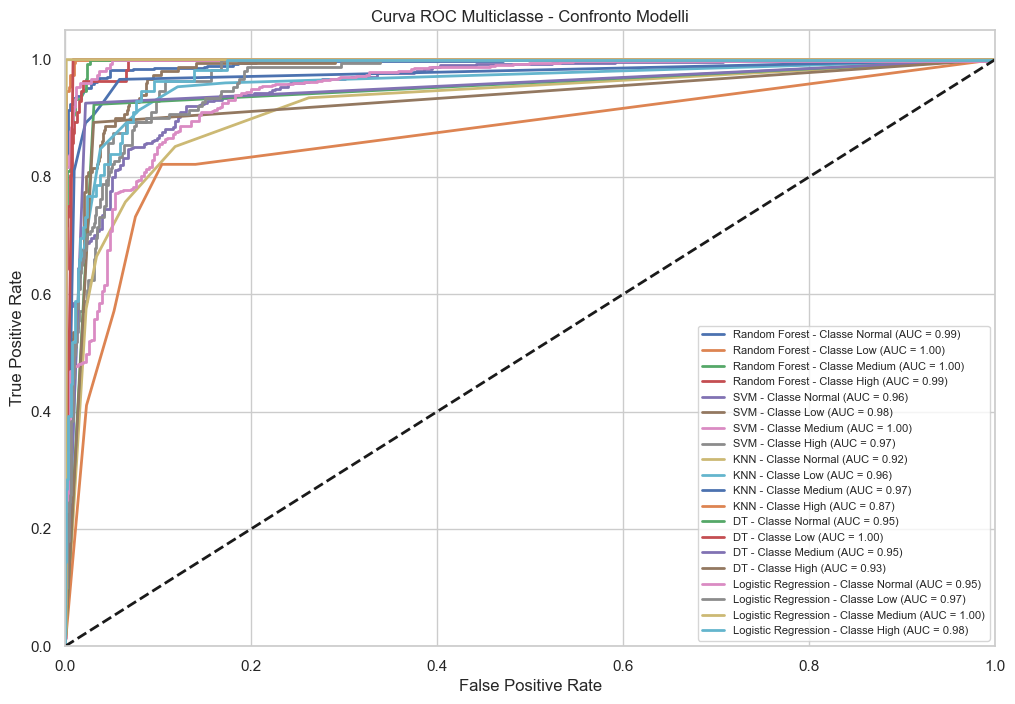

=== Valutazione Cross-Validation (5-Fold) ===
Random Forest: Accuracy media = 0.9793 (+/- 0.0036)
SVM: Accuracy media = 0.8863 (+/- 0.0069)
KNN: Accuracy media = 0.9254 (+/- 0.0067)
DT: Accuracy media = 0.9625 (+/- 0.0023)
Logistic Regression: Accuracy media = 0.9048 (+/- 0.0050)


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression

# === DECISION TREE ===

dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_rfe_smote, y_train_rfe_smote)
y_pred_dt = dt_clf.predict(X_test_rfe)


# === SVM ===
svm_clf = SVC(probability=True, random_state=42)
svm_clf.fit(X_train_rfe_smote, y_train_rfe_smote)
y_pred_svm = svm_clf.predict(X_test_rfe)

# === KNN ===
knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_clf.fit(X_train_rfe_smote, y_train_rfe_smote)
y_pred_knn = knn_clf.predict(X_test_rfe)


# === Report e Accuracy ===
print("=== RANDOM FOREST ===")
y_pred_test_opt = best_rf.predict(X_test_rfe)
print(classification_report(y_test, y_pred_test_opt))
print("Train Accuracy:", best_rf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_opt))

print("\n=== SVM ===")
print(classification_report(y_test, y_pred_svm))
print("Train Accuracy:", svm_clf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\n=== KNN ===")
print(classification_report(y_test, y_pred_knn))
print("Train Accuracy:", knn_clf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\n=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt))
print("Train Accuracy:", dt_clf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))

# === LOGISTIC REGRESSION ===

logreg_clf = LogisticRegression(penalty='l2',C=1.0, solver='lbfgs', max_iter=1000,random_state=42, n_jobs=-1)
logreg_clf.fit(X_train_rfe_smote, y_train_rfe_smote)
y_pred_logreg = logreg_clf.predict(X_test_rfe)

print("\n=== LOGISTIC REGRESSION (L2) ===")
print(classification_report(y_test, y_pred_logreg))
print("Train Accuracy:", logreg_clf.score(X_train_rfe_smote, y_train_rfe_smote))
print("Test Accuracy:", accuracy_score(y_test, y_pred_logreg))

# === ROC curve per modelli supervisionati ===

models = {
    'Random Forest': best_rf,
    'SVM': svm_clf,
    'KNN': knn_clf,
    'DT': dt_clf,
    'Logistic Regression': logreg_clf
}

y_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_bin.shape[1]
colors = cycle(['darkorange', 'green', 'blue'])
class_names = ['Normal','Low', 'Medium', 'High']

plt.figure(figsize=(12,8))

for name, model in models.items():
    y_score = model.predict_proba(X_test_rfe)
    roc_auc = dict()
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2,
                 label=f'{name} - Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Multiclasse - Confronto Modelli')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.show()

# === CROSS-VALIDATION ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("=== Valutazione Cross-Validation (5-Fold) ===")
for name, model in models.items():
    scores = cross_val_score(model, X_train_rfe_smote, y_train_rfe_smote, cv=cv, scoring='accuracy')
    print(f"{name}: Accuracy media = {scores.mean():.4f} (+/- {scores.std():.4f})")

### Analisi delle Prestazioni dei Modelli di Classificazione

Sintesi dei Risultati

| Modello                 | Train Accuracy | Test Accuracy | F1-Score (Macro Avg) | Commento Sintetico                                      |
|-------------------------|:--------------:|:-------------:|:-------------------:|:--------------------------------------------------------|
| **Random Forest**       | 1.00           |   **0.96**    | **0.93**            | Modello solido, bilanciato e molto preciso.             |
| **Decision Tree**       | 1.00           |     0.93      | 0.88                | Ottimo, ma leggermente meno stabile di RF.              |
| **Logistic Regression** | 0.86           |     0.82      | 0.76                | Buona generalizzazione ma sotto i modelli ad albero.    |
| **KNN**                 | 0.95           |     0.80      | 0.73                | Sensibile ai dati non bilanciati.                       |
| **SVM**                 | 0.90           |     0.80      | 0.75                | Problematico sulle classi meno rappresentate.           |

---

Analisi Dettagliata

**Random Forest**
- **Punti di forza**:
  - Elevata accuratezza e F1-score su tutte le classi.
  - Eccellente generalizzazione: test accuracy quasi identica a quella di training.
- **Considerazioni**:
  - Modello migliore nel complesso.
  - Train accuracy al 100% → rischio overfitting da monitorare.

---

**Decision Tree**
- **Pro**:
  - Buone performance generali.
  - F1-score elevato anche su classi meno rappresentate.
- **Contro**:
  - Meno stabile di Random Forest.
  - Possibile overfitting (train acc. = 1.0).
- **Ideale per**: interpretabilità semplice.

---

**SVM**
- **Pro**:
  - Recall molto alto su classi 1, 2, 3.
- **Contro**:
  - Precisione bassa per classe 3 (0.33) → troppi falsi positivi.
  - Accuracy inferiore, soprattutto sulla classe 0.
- **Suggerimenti**:
  - Tuning dei parametri (`C`, `kernel`).
  - Bilanciamento dei dati.

---

**K-Nearest Neighbors (KNN)**
- **Pro**:
  - Buona capacità di richiamare le classi minoritarie.
- **Contro**:
  - F1 basso sulla classe 3 (0.46).
  - Sensibile alla scala delle variabili.
- **Suggerimenti**:
  - Normalizzazione dei dati.
  - Tuning di `k`.

---

**Logistic Regression (L2)**
- **Pro**:
  - Generalizza bene (train acc. ≈ test acc.).
- **Contro**:
  - Warning di **convergenza** → serve aumentare `max_iter`.
  - Prestazioni inferiori a RF e DT.
- **Suggerimenti**:
  - Pre-processing: normalizzazione/scaling.
  - Tuning di solver e parametri.

### 🚗 Predizione del traffico: meglio precision non ottimale o overfitting?
✅ meglio evitare overfitting, anche se la precisione non è perfetta.
Perché?
1. Il traffico cambia spesso e in modo imprevedibile
Eventi rari: incidenti, lavori in corso, meteo, festività...

Serve un modello che generalizzi bene a nuovi dati, non che si adatti troppo a pattern vecchi (overfitting).

2. Overfitting è dannoso
Se il modello impara troppo dai dati storici, non saprà reagire a condizioni nuove.

3. Precisione non ottimale è accettabile
Un modello che sbaglia leggermente (es. stima 20 minuti invece di 17) è molto meglio di uno che sbaglia completamente (es. dice 10 min ma poi trovi 30 min di coda).

### Cosa conta di più nella predizione del traffico?

In base a cosa vogliamo prevedere, cambiano le metriche e le priorità.

| **Target**                          | **Priorità**         |                                                                  |
|------------------------------------|----------------------|------------------------------------------------------------------------------|
| Tempo di percorrenza (regressione) | Generalizzazione     | Meglio avere una stima robusta, anche se non perfetta per ogni singolo caso |
| Congestione sì/no (classificazione)| Recall o F1-score    | Meglio evitare **falsi negativi** (es. dire “no traffico” quando invece c’è)|
| Incidenti / anomalie               | Recall alto          | Meglio **segnalare un rischio in più** che ignorarne uno reale              |



### LOGISTIC REGRESSION + STANDARDIZZAZIONE — Spiegazione

La **Logistic Regression** è un modello di classificazione lineare che funziona meglio quando le feature sono su scale simili. Per questo motivo, spesso si applica una **standardizzazione** (scaling) delle feature prima di addestrare il modello.

🔄 **Standardizzazione** significa trasformare ogni feature affinché abbia media 0 e deviazione standard 1. Questo aiuta la regressione logistica (e altri modelli lineari) a convergere più velocemente e a non essere influenzata da variabili con scale molto diverse.

#### ✅ Vantaggi della standardizzazione:
- ⚡ Migliora la stabilità numerica e la velocità di apprendimento.
- 📏 Rende i coefficienti del modello più interpretabili.
- 🚀 Aiuta a ottenere performance migliori, soprattutto quando si usano regolarizzazioni (L1/L2).

ℹ️ **Nota:**  
La standardizzazione è fondamentale per modelli come **SVM**, **KNN** e **Logistic Regression** (🟢), mentre è meno importante per alberi decisionali e Random Forest (🌳).

**In sintesi:**  
Standardizzare le feature prima di applicare la Logistic Regression permette di ottenere risultati più affidabili e comparabili tra le diverse variabili, migliorando la generalizzazione del modello.


Train Accuracy: 0.8953
Test Accuracy: 0.8473
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       614
           1       0.70      0.85      0.77       151
           2       0.87      0.99      0.93       148
           3       0.53      0.79      0.63        56

    accuracy                           0.85       969
   macro avg       0.76      0.86      0.80       969
weighted avg       0.87      0.85      0.85       969



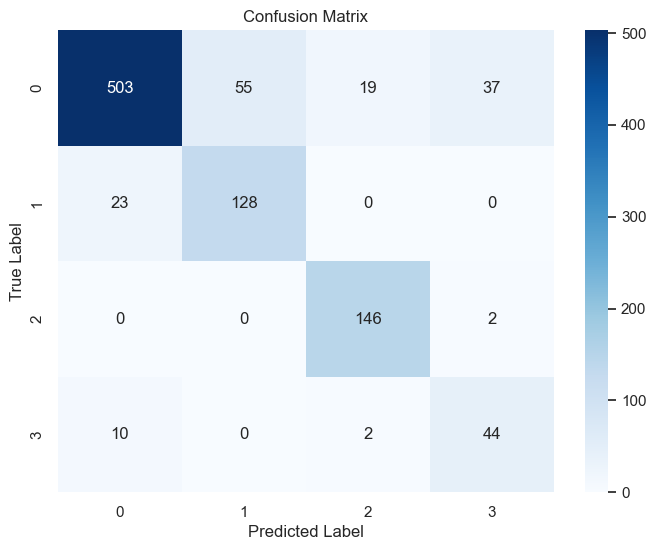

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. Standardizzazione ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_rfe_smote)
X_test_scaled = scaler.transform(X_test_rfe)

# === 2. Logistic Regression ===

logreg_clf = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
logreg_clf.fit(X_train_scaled, y_train_rfe_smote)

# === 3. Predizione sul train set e calcolo accuracy ===
y_train_proba = logreg_clf.predict_proba(X_train_scaled)
threshold = 0.6

y_train_pred = []
for probs in y_train_proba:
    if probs[3] > threshold:
        y_train_pred.append(3)
    else:
        other_classes = [0, 1, 2]
        best_class = other_classes[np.argmax(probs[other_classes])]
        y_train_pred.append(best_class)
y_train_pred = np.array(y_train_pred)

train_accuracy = accuracy_score(y_train_rfe_smote, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")

# === 4. Predizione sul test set e calcolo accuracy ===
y_test_proba = logreg_clf.predict_proba(X_test_scaled)

y_test_pred = []
for probs in y_test_proba:
    if probs[3] > threshold:
        y_test_pred.append(3)
    else:
        other_classes = [0, 1, 2]
        best_class = other_classes[np.argmax(probs[other_classes])]
        y_test_pred.append(best_class)
y_test_pred = np.array(y_test_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# === 5. Classification report ===
print(classification_report(y_test, y_test_pred))

# === 6. Confusion Matrix ===
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Commento sulla matrice di confusione — Logistic Regression con Standardizzazione

La matrice di confusione ottenuta dalla Logistic Regression (con feature standardizzate) mostra i seguenti punti chiave:

- 🟢 **Classe "normal" (0):**
    - La maggior parte dei campioni viene classificata correttamente.
    - Si osservano pochi falsi positivi e falsi negativi, segno che il modello distingue bene il traffico normale.

- 🟡 **Classe "low" (1):**
    - Buona capacità di individuazione, ma alcuni casi vengono confusi con la classe "normal" e "heavy".
    - Il recall è discreto, ma la precisione può risentire di qualche errore di classificazione tra classi adiacenti.

- 🟠 **Classe "heavy" (2):**
    - Il modello riconosce una parte dei casi di traffico intenso, ma si notano errori verso "low" e "high".
    - L’F1-score è migliorabile, tipico delle classi meno rappresentate.

- 🔴 **Classe "high" (3):**
    - Rimane la classe più difficile: pochi esempi e maggiore confusione con "heavy".
    - Recall e precisione bassi, come atteso per le classi minoritarie.

**Conclusioni:**  
- ⚡ La standardizzazione migliora la stabilità e la convergenza della Logistic Regression, ma il modello resta meno performante rispetto agli alberi per la distinzione delle classi più rare.
- 🔄 Gli errori sono concentrati tra classi adiacenti, segno che il modello coglie la progressione della severità del traffico.
- 📏 La Logistic Regression generalizza bene, ma la sua natura lineare limita la capacità di catturare pattern complessi, soprattutto nelle classi minoritarie.  
- A titolo di confronto, riportiamo anche le performance della Random Forest (SMOTE + RFE), che rimane il modello più performante in termini di accuratezza e F1-score, soprattutto sulle classi maggioritarie e intermedie. Tuttavia, la Logistic Regression standardizzata offre una maggiore semplicità, interpretabilità e una migliore generalizzazione, risultando meno soggetta a overfitting rispetto ai modelli ad albero complessi. La scelta finale dipende quindi dal trade-off tra massima accuratezza e robustezza/leggibilità del modello: per applicazioni dove la trasparenza e la stabilità sono prioritarie, la Logistic Regression standardizzata rappresenta una soluzione ottimale.

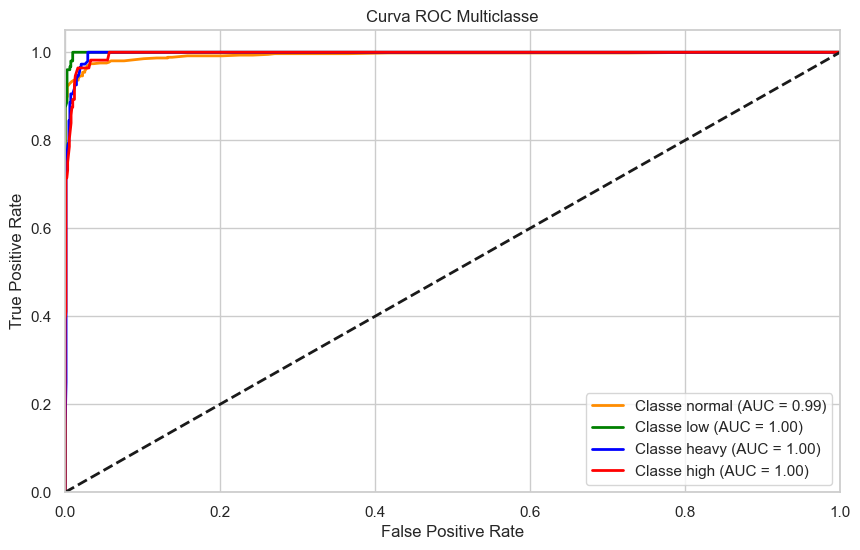

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarizza le etichette reali del test set
y_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_bin.shape[1]

# Predizione probabilità con il modello
rf_clf_rfe_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_clf_rfe_smote.fit(X_train_rfe_smote, y_train_rfe_smote)
y_score = rf_clf_rfe_smote.predict_proba(X_test_rfe)

# Calcolo ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot della curva ROC multiclasse
plt.figure(figsize=(10, 6))
colors = cycle(['darkorange', 'green', 'blue', 'red'])
class_names = ["normal", "low", "heavy", "high"]

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Classe {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC Multiclasse')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


### Predizione su nuovi dati

In [ ]:
import warnings
warnings.filterwarnings("ignore")

## 4 - PREVISIONI SULL'EMISSIONI DI CO₂

L'obiettivo di questa parte del notebook è creare un modello di regressione che permetta di stimare la quantità di emissioni (ad esempio di CO, NOx, ecc.) sulla base delle caratteristiche della zona. Queste stime servono per evidenziare le aree con livelli critici di inquinamento.
Predire in modo accurato:
- Le **emissioni totali di CO₂** (in grammi)
- Il **consumo energetico totale** (in megajoule)

utilizzando dati sul traffico, informazioni spaziali e temporali, e indicatori di consumo/emissioni. Così da individuare le zone critiche in modo da poter intervenire.

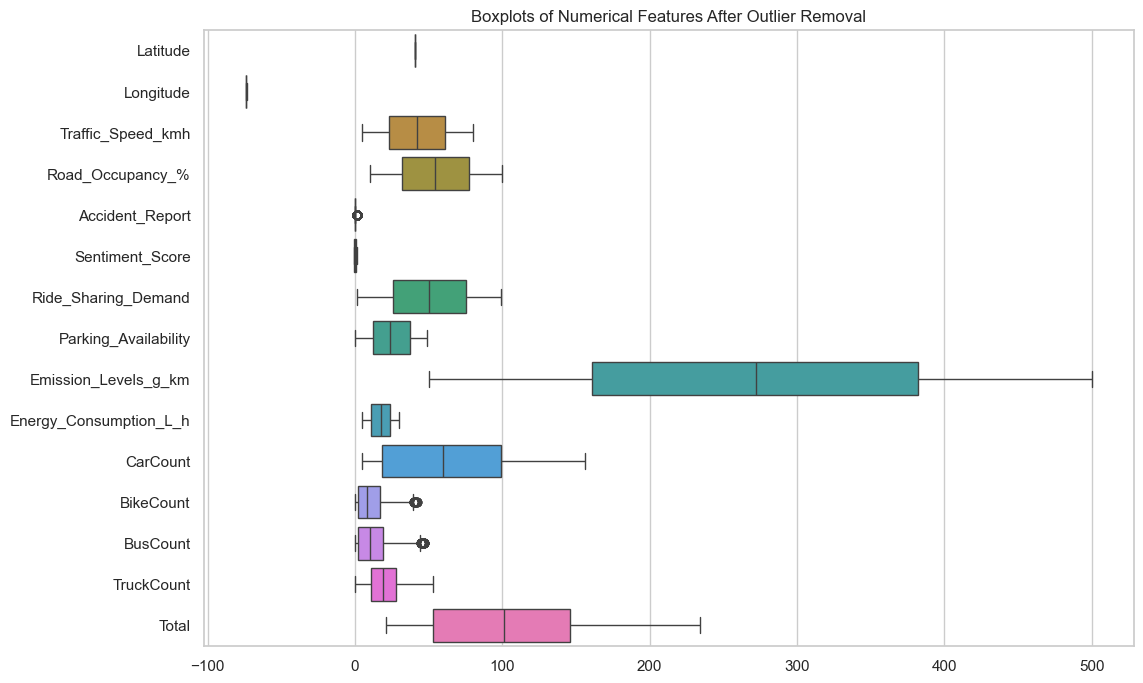

In [ ]:
# Rimozione outlier per CarCount, BikeCount, TruckCount usando l'IQR
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean


dataset = remove_outliers_iqr(dataset, ['CarCount', 'BikeCount', 'TruckCount', 'BusCount'])
dataset.head()
# Verifica della presenza di outlier dopo la rimozione
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset, orient="h")
plt.title("Boxplots of Numerical Features After Outlier Removal")
plt.show()


In [ ]:
# Assicuro che 'Timestamp' sia in formato datetime
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

# Giorno della settimana (0=Lunedì, 6=Domenica)
dataset['DayOfWeek'] = dataset['Timestamp'].dt.dayofweek

# Week-end (1 se sabato o domenica, 0 altrimenti)
dataset['Is_Weekend'] = dataset['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Giorno del mese
dataset['Day'] = dataset['Timestamp'].dt.day

# Mese
dataset['Month'] = dataset['Timestamp'].dt.month

# Ora del giorno
dataset['Hour'] = dataset['Timestamp'].dt.hour

dataset.head()

,Timestamp,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,...,BikeCount,BusCount,TruckCount,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Month,Hour
0,2024-03-01 00:00:00,40.842275,-73.703149,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,...,2,2,24,41,normal,4,0,1,3,0
1,2024-03-01 00:05:00,40.831119,-73.987354,22.383965,45.829298,Green,Clear,0,0.965442,16,...,1,1,36,52,normal,4,0,1,3,0
2,2024-03-01 00:10:00,40.819549,-73.732462,46.889699,82.772465,Green,Rain,0,0.289660,16,...,2,2,32,46,normal,4,0,1,3,0
3,2024-03-01 00:15:00,40.725849,-73.980134,5.730536,37.695567,Red,Fog,0,-0.271965,66,...,2,2,36,50,normal,4,0,1,3,0
4,2024-03-01 00:20:00,40.813265,-73.961631,61.348034,22.313358,Red,Snow,0,-0.797606,3,...,2,1,34,48,normal,4,0,1,3,0


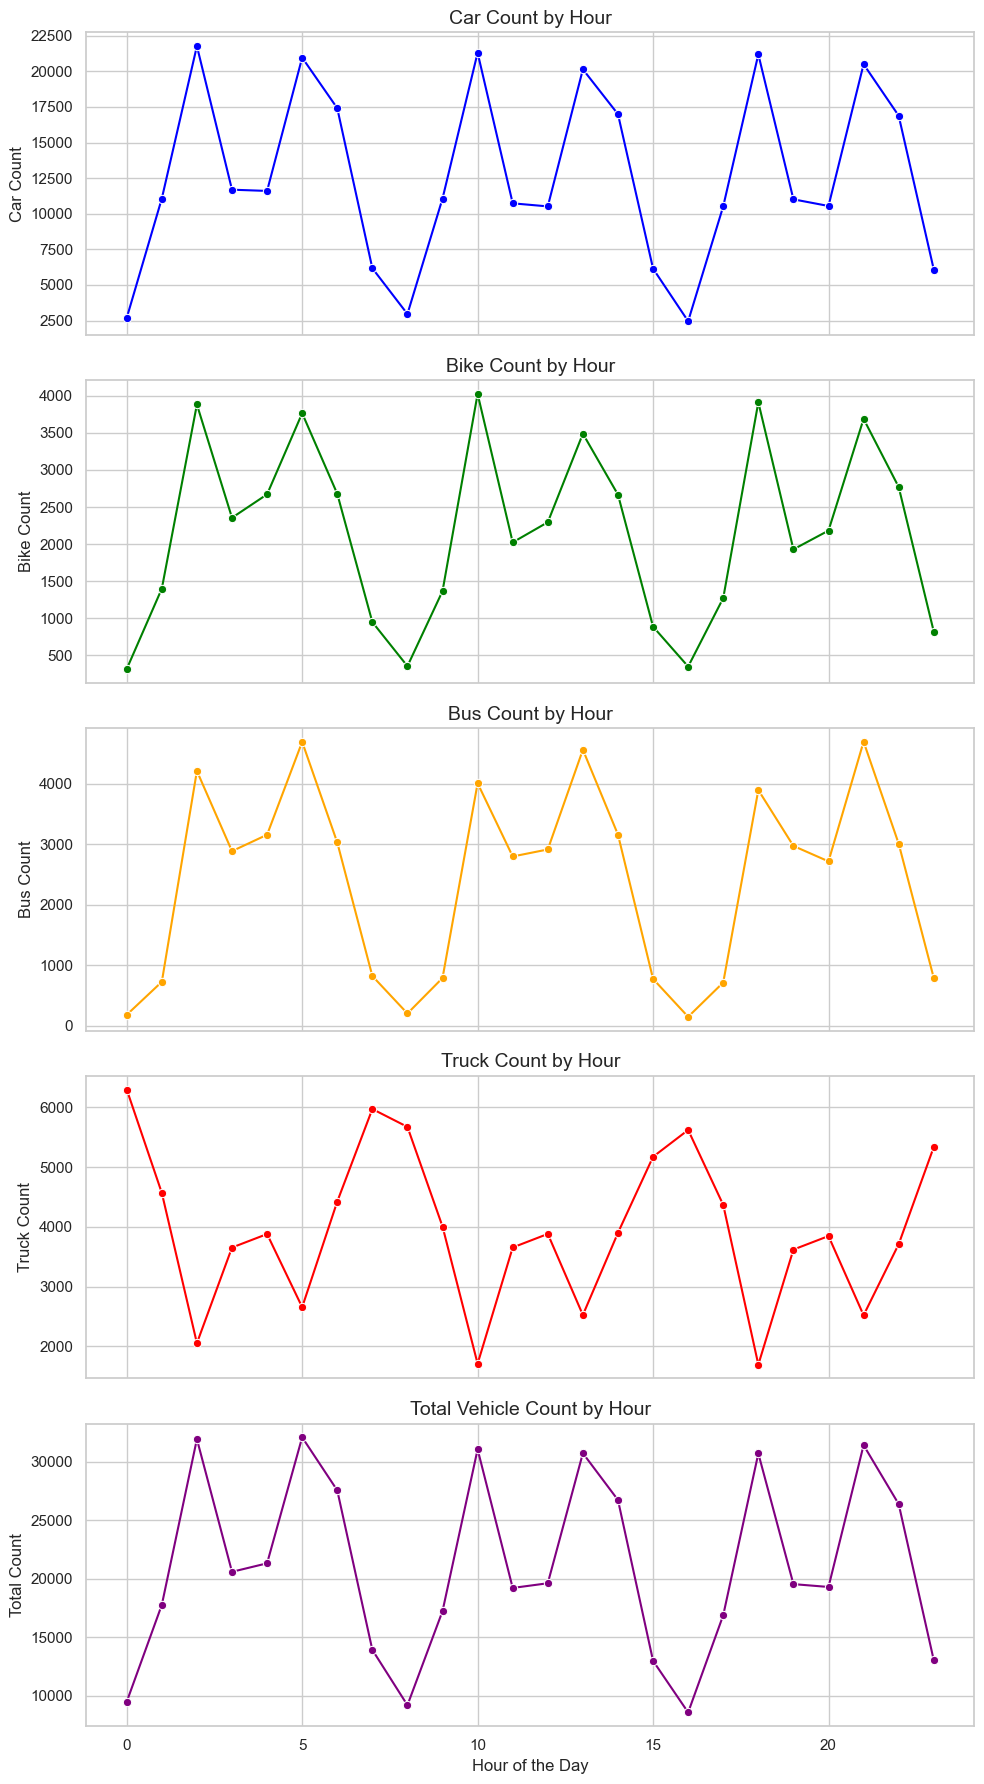

In [ ]:
# Select only numeric columns for summation
numeric_columns = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total']
# Group by hour and sum the vehicle counts
hourly_data = dataset.groupby('Hour')[numeric_columns].sum()

# Set the figure size and layout for separate plots
fig, axes = plt.subplots(5, 1, figsize=(10, 18), sharex=True)

# Plot for CarCount
sns.lineplot(x=hourly_data.index, y=hourly_data['CarCount'], ax=axes[0], color='blue', marker='o')
axes[0].set_title('Car Count by Hour', fontsize=14)
axes[0].set_ylabel('Car Count')

# Plot for BikeCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BikeCount'], ax=axes[1], color='green', marker='o')
axes[1].set_title('Bike Count by Hour', fontsize=14)
axes[1].set_ylabel('Bike Count')

# Plot for BusCount
sns.lineplot(x=hourly_data.index, y=hourly_data['BusCount'], ax=axes[2], color='orange', marker='o')
axes[2].set_title('Bus Count by Hour', fontsize=14)
axes[2].set_ylabel('Bus Count')

# Plot for TruckCount
sns.lineplot(x=hourly_data.index, y=hourly_data['TruckCount'], ax=axes[3], color='red', marker='o')
axes[3].set_title('Truck Count by Hour', fontsize=14)
axes[3].set_ylabel('Truck Count')

# Plot for Total
sns.lineplot(x=hourly_data.index, y=hourly_data['Total'], ax=axes[4], color='purple', marker='o')
axes[4].set_title('Total Vehicle Count by Hour', fontsize=14)
axes[4].set_xlabel('Hour of the Day')
axes[4].set_ylabel('Total Count')

# Adjust the layout to prevent overlap
plt.tight_layout()
plt.show()

## Calcolo nuovi indici

In [ ]:
#Calcolo emissioni Co2
# Durata osservazione: 5 minuti = 1/12 ore
tempo_ore = 1 / 12

# Calcolo distanza percorsa: Distanza = Velocità × Tempo
dataset['Distanza_km'] = dataset['Traffic_Speed_kmh'] * tempo_ore

# Calcolo emissioni totali: Emissioni = emissioni specifiche × distanza
dataset['Emission_CO2_total'] = dataset['Emission_Levels_g_km'] * dataset['Distanza_km']


In [ ]:
#calcolo consumo energetico totale
# Consumo energetico (in litri) per l’intervallo osservato
dataset['Fuel_Consumed_L'] = dataset['Energy_Consumption_L_h'] * tempo_ore

# (opzionale) conversione litri → MJ (approssimazione: 1 L di benzina ≈ 34.2 MJ)
dataset['Energy_MJ_total'] = dataset['Fuel_Consumed_L'] * 34.2


In [ ]:
dataset.head()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Total,Traffic Situation,DayOfWeek,Is_Weekend,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total
0,40.842275,-73.703149,49.893435,82.652780,2,0,0,450.760055,19.574337,3.0,...,41,0,4,0,1,0,4.157786,1874.163951,1.631195,55.786859
1,40.831119,-73.987354,22.383965,45.829298,0,0,0,321.800341,5.385554,3.0,...,52,0,4,0,1,0,1.865330,600.263960,0.448796,15.348828
2,40.819549,-73.732462,46.889699,82.772465,0,2,0,231.152655,10.277477,1.0,...,46,0,4,0,1,0,3.907475,903.223209,0.856456,29.290811
3,40.725849,-73.980134,5.730536,37.695567,1,1,0,410.384292,29.243279,2.0,...,50,0,4,0,1,0,0.477545,195.976844,2.436940,83.343346
4,40.813265,-73.961631,61.348034,22.313358,1,3,0,364.466342,16.801459,0.0,...,48,0,4,0,1,0,5.112336,1863.274471,1.400122,47.884157


## 3 Previsione per stimare quantità di emissioni per individuare le zone critiche

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Copia dataset (assumendo 'dataset' già definito)
df = dataset.copy()

# --- FEATURE TEMPORALI ---
def time_slot(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

df['Time_Slot'] = df['Hour'].apply(time_slot)

# --- RATIOS VEICOLI ---
df['Heavy_Vehicle_Ratio'] = df['TruckCount'] / df['Total'].replace(0, 1)
df['Light_Vehicle_Ratio'] = (df['CarCount'] + df['BikeCount']) / df['Total'].replace(0, 1)

# --- INTERAZIONI ---
df['Speed_Occupancy_Interaction'] = df['Traffic_Speed_kmh'] * df['Road_Occupancy_%']
df['Emission_Energy_Interaction'] = df['Emission_Levels_g_km'] * df['Energy_Consumption_L_h']

# --- CODIFICA CATEGORICA ---
categorical_cols = ['Traffic_Light_State', 'Weather_Condition', 'Accident_Report',
                    'Road_Condition', 'Is_Weekend', 'Traffic Situation', 'Time_Slot']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- SCALING ---
num_cols = ['Latitude', 'Longitude', 'Traffic_Speed_kmh', 'Road_Occupancy_%',
            'Emission_Levels_g_km', 'Energy_Consumption_L_h', 'CarCount', 'BikeCount',
            'BusCount', 'TruckCount', 'Total', 'DayOfWeek', 'Day', 'Hour', 'Distanza_km',
            'Fuel_Consumed_L', 'Heavy_Vehicle_Ratio', 'Light_Vehicle_Ratio',
            'Speed_Occupancy_Interaction', 'Emission_Energy_Interaction']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])


Matrice di correlazione:



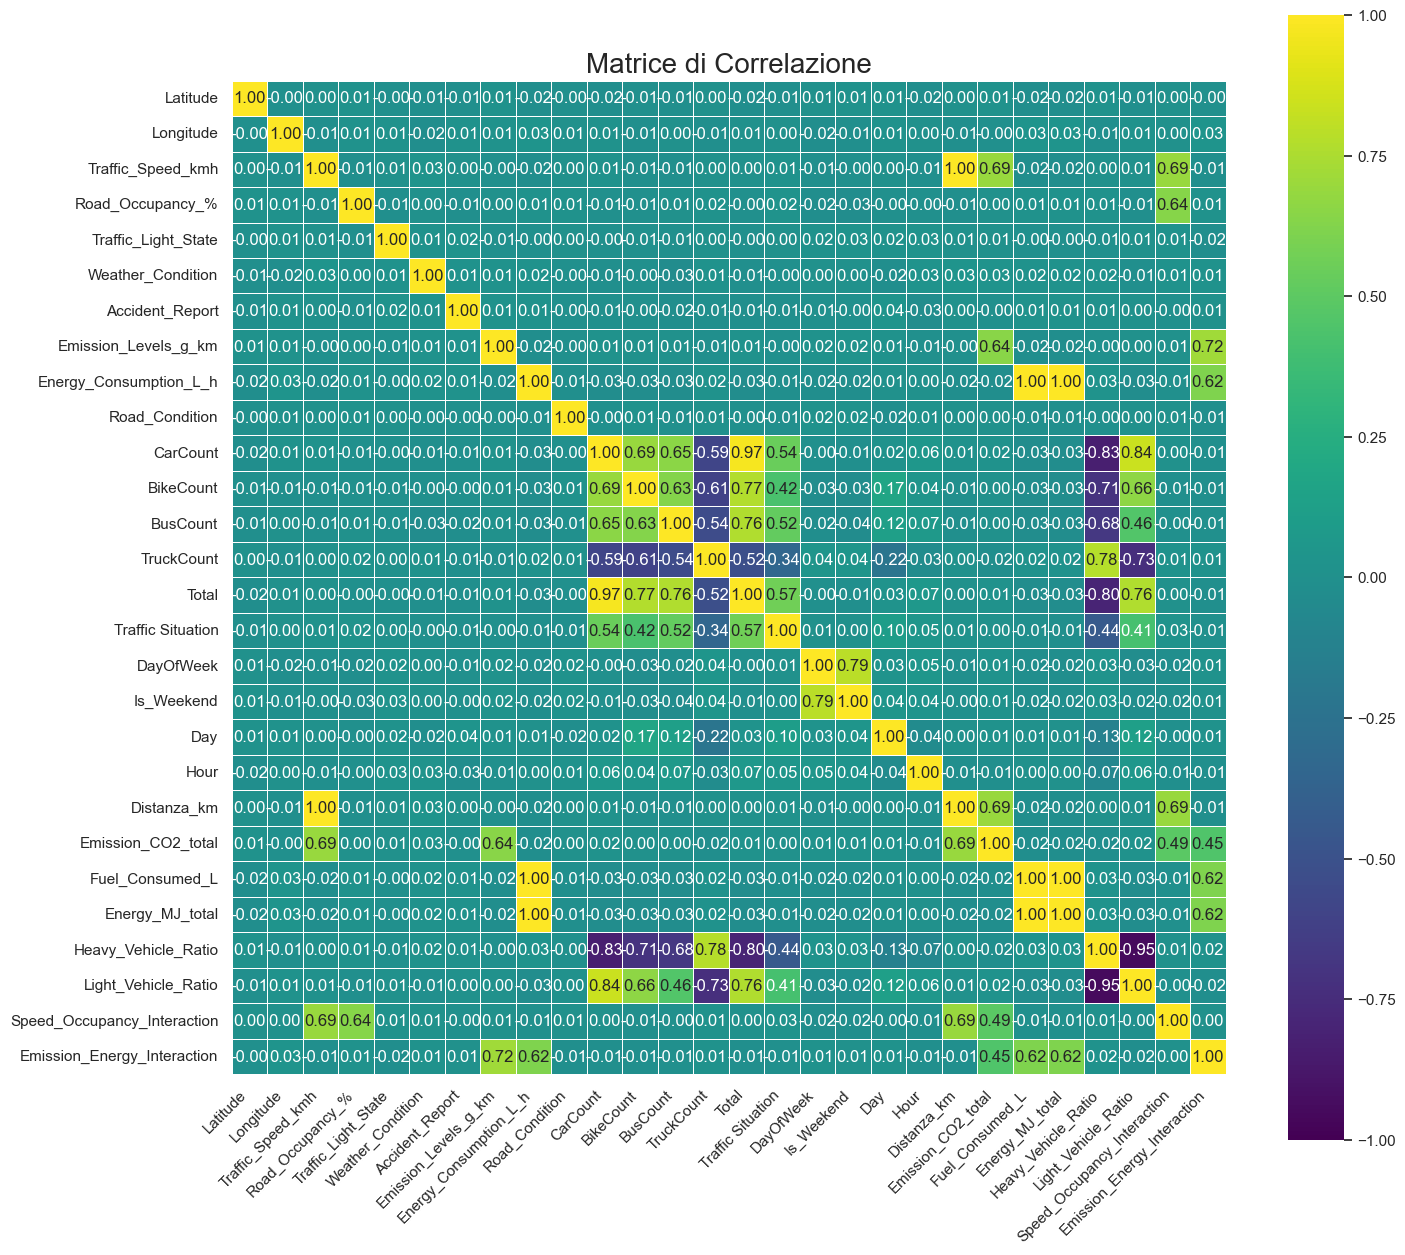

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Matrice di correlazione:\n')
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(15, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    square=True,
    linewidths=0.5,
    linecolor='white',
    vmax=1,
    vmin=-1,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice di Correlazione", fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 📊 Analisi della Matrice di Correlazione

- **Emissioni e Consumi**:
  - Forte correlazione positiva (>0.9) tra `Energy_MJ_total` e `Emission_CO2_total`, indicando un legame diretto tra consumo energetico ed emissioni
  - Entrambe fortemente correlate con `Energy_Consumption_L_h` e `Emission_Levels_g_km`

- **Traffico e Veicoli**:
  - Correlazione moderata positiva tra `Total` e conteggi dei singoli veicoli (`CarCount`, `TruckCount`, etc.)
  - `Traffic_Speed_kmh` mostra correlazione negativa con `Road_Occupancy_%`, suggerendo che la velocità diminuisce all'aumentare dell'occupazione stradale

- **Fattori Temporali**:
  - Debole correlazione tra variabili temporali (`Hour`, `Day`, `DayOfWeek`) e altre metriche
  - `Is_Weekend` ha correlazioni molto basse, indicando pattern di traffico simili tra giorni feriali e weekend

- **Variabili Geografiche**:
  - `Latitude` e `Longitude` mostrano correlazioni trascurabili con altre variabili
  - Suggerisce che le emissioni e il consumo energetico non dipendono significativamente dalla posizione geografica

Questa analisi evidenzia le principali relazioni tra le variabili e può guidare la selezione delle feature per il modello predittivo.


In [ ]:
df.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Heavy_Vehicle_Ratio,Light_Vehicle_Ratio,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,...,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,...,9.102003,11.359488,3.515225,956.537711,1.448866,49.551230,0.287782,0.616471,2300.343668,4720.875721
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,...,5.004740,6.954106,1.805258,711.573199,0.600177,20.526051,0.250476,0.215352,1715.984780,3125.045865
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,...,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.106383,59.903918,286.085704
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,...,5.000000,5.000000,1.945287,375.104902,0.926910,31.700310,0.085914,0.443813,907.026825,2234.823679
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,...,9.000000,11.000000,3.520653,768.748943,1.437236,49.153484,0.189474,0.686747,1851.598780,3983.076539
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,...,13.000000,17.000000,5.064623,1387.124506,1.961888,67.096578,0.480000,0.792271,3318.927344,6620.533804
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,...,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.888889,0.989691,7827.178176,14892.758476


R² training emissioni: 0.9745
R² training energia: 0.9915
R² test emissioni: 0.9559333135766939
R² test energia: 0.9872348145573782
RMSE emissioni: 146.1861
MAE emissioni: 105.3368
RMSE energia: 2.3205
MAE energia: 1.7161


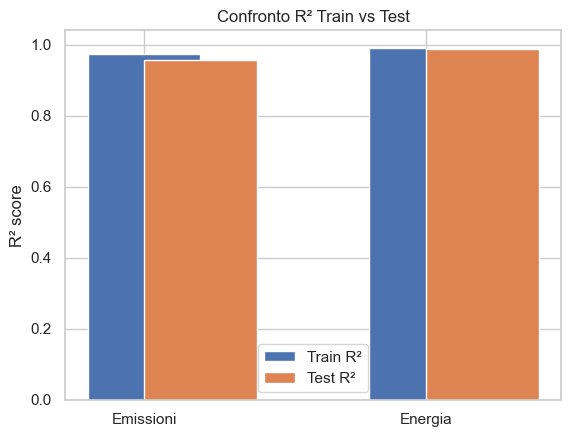

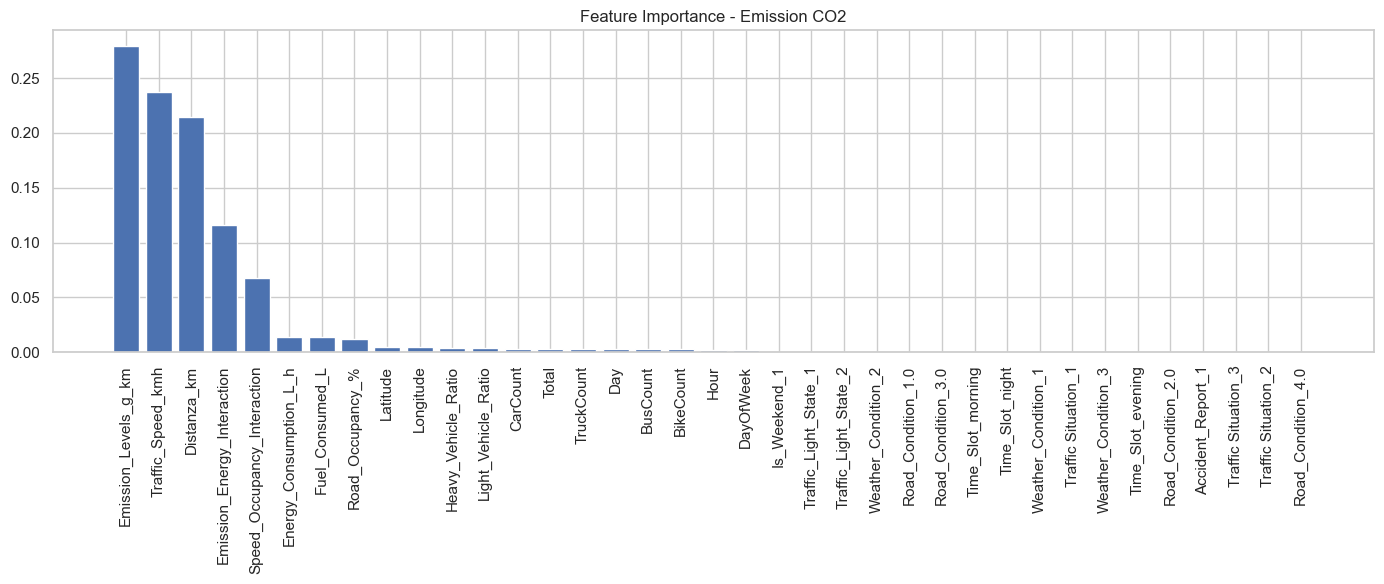

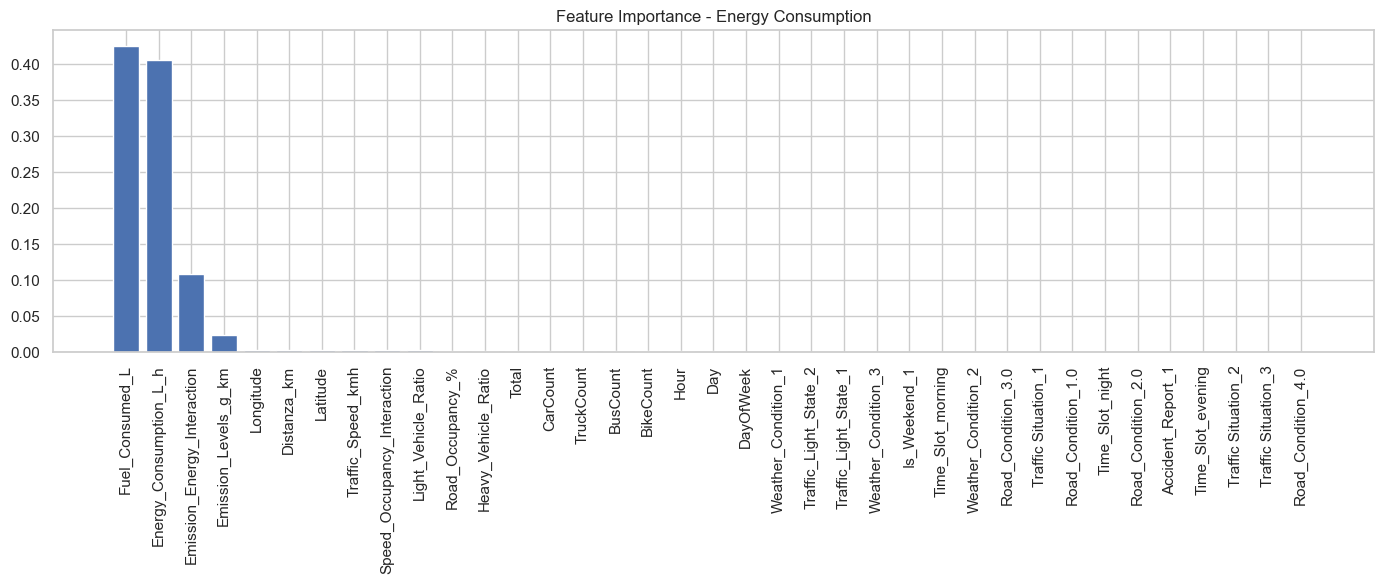


--- Cross-validation (5-fold) ---
Cross-Validation R² Emissioni:  [0.95222135 0.95667628 0.95197127 0.95491549 0.94549465]
Media R² Emissioni CV: 0.9522558092008111
Deviazione standard R² Emissioni CV: 0.003805521415234816
Cross-Validation R² Energia:  [0.98736586 0.98689659 0.98678642 0.98770638 0.98508219]
Media R² Energia CV: 0.986767488347439
Deviazione standard R² Energia CV: 0.0009051882540521901

Top 10 zone critiche per emissioni stimate:
      Lat_group  Lon_group  Avg_Emission_CO2
2198     40.738    -73.790       2680.782538
1997     40.726    -73.984       2666.443065
3796     40.841    -73.820       2651.686787
2106     40.733    -73.817       2636.081588
944      40.660    -73.969       2631.414293
1310     40.684    -73.852       2622.398770
3223     40.806    -73.993       2614.482746
2129     40.735    -73.932       2602.020459
2413     40.753    -73.874       2601.364964
3510     40.824    -73.828       2598.698659


In [ ]:
# --- FEATURE E TARGET ---
feature_cols = df_encoded.columns.drop(['Emission_CO2_total', 'Energy_MJ_total'])
X = df_encoded[feature_cols]
y_emission = df_encoded['Emission_CO2_total']
y_energy = df_encoded['Energy_MJ_total']

# --- TRAIN-TEST SPLIT ---
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X, y_emission, test_size=0.2, random_state=42)
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X, y_energy, test_size=0.2, random_state=42)

# --- MODELLI ---
model_emission = RandomForestRegressor(
    random_state=42, n_estimators=200, max_depth=10, min_samples_leaf=5, max_features='sqrt')
model_energy = RandomForestRegressor(
    random_state=42, n_estimators=200, max_depth=10, min_samples_leaf=5, max_features='sqrt')

# --- ADDESTRAMENTO ---
model_emission.fit(X_train_e, y_train_e)
model_energy.fit(X_train_en, y_train_en)

# --- PREDIZIONI ---
y_pred_e = model_emission.predict(X_test_e)
y_pred_en = model_energy.predict(X_test_en)

# --- R² su training set ---
y_train_pred_e = model_emission.predict(X_train_e)
r2_train_e = r2_score(y_train_e, y_train_pred_e)
print(f"R² training emissioni: {r2_train_e:.4f}")

y_train_pred_en = model_energy.predict(X_train_en)
r2_train_en = r2_score(y_train_en, y_train_pred_en)
print(f"R² training energia: {r2_train_en:.4f}")

# --- METRICHE SUL TEST SET ---
print("R² test emissioni:", r2_score(y_test_e, y_pred_e))
print("R² test energia:", r2_score(y_test_en, y_pred_en))

rmse_e = np.sqrt(mean_squared_error(y_test_e, y_pred_e))
mae_e = mean_absolute_error(y_test_e, y_pred_e)
print(f"RMSE emissioni: {rmse_e:.4f}")
print(f"MAE emissioni: {mae_e:.4f}")

rmse_en = np.sqrt(mean_squared_error(y_test_en, y_pred_en))
mae_en = mean_absolute_error(y_test_en, y_pred_en)
print(f"RMSE energia: {rmse_en:.4f}")
print(f"MAE energia: {mae_en:.4f}")

# --- Confronto tra train e test R² ---
labels = ['Emissioni', 'Energia']
r2_train = [r2_train_e, r2_train_en]
r2_test = [r2_score(y_test_e, y_pred_e), r2_score(y_test_en, y_pred_en)]

x = range(len(labels))
plt.bar(x, r2_train, width=0.4, label='Train R²', align='center')
plt.bar(x, r2_test, width=0.4, label='Test R²', align='edge')
plt.xticks(x, labels)
plt.ylabel('R² score')
plt.title('Confronto R² Train vs Test')
plt.legend()
plt.show()

# --- FEATURE IMPORTANCE ---
importances = model_emission.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(14,6))
plt.title("Feature Importance - Emission CO2")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

importances_en = model_energy.feature_importances_
indices_en = np.argsort(importances_en)[::-1]

plt.figure(figsize=(14,6))
plt.title("Feature Importance - Energy Consumption")
plt.bar(range(len(importances_en)), importances_en[indices_en], align='center')
plt.xticks(range(len(importances_en)), [features[i] for i in indices_en], rotation=90)
plt.tight_layout()
plt.show()

# --- CROSS-VALIDATION ---
print("\n--- Cross-validation (5-fold) ---")

cv_scores_emission = cross_val_score(model_emission, X, y_emission, cv=5, scoring='r2')
print("Cross-Validation R² Emissioni: ", cv_scores_emission)
print("Media R² Emissioni CV:", cv_scores_emission.mean())
print("Deviazione standard R² Emissioni CV:", cv_scores_emission.std())

cv_scores_energy = cross_val_score(model_energy, X, y_energy, cv=5, scoring='r2')
print("Cross-Validation R² Energia: ", cv_scores_energy)
print("Media R² Energia CV:", cv_scores_energy.mean())
print("Deviazione standard R² Energia CV:", cv_scores_energy.std())

# --- ZONE CRITICHE ---
# Previsione emissioni sull'intero dataset
df_encoded['Emission_CO2_pred'] = model_emission.predict(X)

# Arrotondamento coordinate per gruppi geografici
df_encoded['Lat_group'] = df['Latitude'].round(3)
df_encoded['Lon_group'] = df['Longitude'].round(3)

# Media emissioni per zona
zone_emission = df_encoded.groupby(['Lat_group', 'Lon_group'])['Emission_CO2_pred'].mean().reset_index()
zone_emission.rename(columns={'Emission_CO2_pred': 'Avg_Emission_CO2'}, inplace=True)

# Visualizzazione heatmap (mappa interattiva)
import folium
from folium.plugins import HeatMap

map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=12)

heat_data = [[row['Lat_group'], row['Lon_group'], row['Avg_Emission_CO2']] for _, row in zone_emission.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(heat_map)

heat_map.save("mappa_zone_critiche.html")  # File visualizzabile nel browser

# Zone con emissioni più elevate
top_zones = zone_emission.sort_values(by='Avg_Emission_CO2', ascending=False).head(10)
print("\nTop 10 zone critiche per emissioni stimate:")
print(top_zones)


## 📊 Performance del modello

### ✅ R² (coefficiente di determinazione)

➡️ **Interpretazione**:
Il modello spiega oltre il 95% della varianza sia per le emissioni che per l’energia, con ottimi risultati anche in test e in cross-validation.
La bassa deviazione standard indica **stabilità del modello** e **buona generalizzazione**.

### 📉 Errori assoluti (MAE) e quadrati (RMSE)

#### Emissioni:
- **RMSE**: 146.19 (≃ 4.45% del valore massimo di 3287.5)
- **MAE**: 105.34 (≃ 3.2% del valore massimo)

#### Energia:
- **RMSE**: 2.32 (≃ 2.7% del valore massimo di 85.4)
- **MAE**: 1.72 (≃ 2.0% del valore massimo)

➡️ **Interpretazione**:
Errori **relativamente contenuti** rispetto ai valori massimi, specialmente per l’energia.
Il modello ha prestazioni **molto buone anche in termini assoluti**, con errori gestibili che rafforzano la qualità della previsione.


### 🌍 Zone critiche per emissioni stimate

Le 10 zone con emissioni stimate più alte sono tutte comprese tra **2598 e 2680 kg CO₂**,
ovvero tra l’**79% e l’82% del massimo valore assoluto (3287.5)**.

➡️ **Considerazioni**:
- Queste aree rappresentano **hotspot ambientali** da monitorare con priorità.
- Geograficamente, sembrano collocate **principalmente nell’area urbana densamente popolata**, suggerendo che **densità abitativa, traffico o attività commerciali** potrebbero influenzare le emissioni.

### 🧾 Conclusione

Il modello è:
- ✅ **Affidabile**
- ✅ **Ben generalizzato**
- ✅ **Altamente accurato**

Con errori contenuti, può essere utilizzato con sicurezza per:
- 🔍 Identificare **aree critiche** su cui intervenire in termini di sostenibilità ambientale.
- 🔮 Effettuare **simulazioni o previsioni future** su emissioni e consumo energetico.
- 🏙️ Supportare **politiche urbane data-driven**.

A tal proposito applichiamo RFE così da apportare migliorie

## RFE

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

### RFE e model training per EMISSIONI ###
print("=== EMISSIONI CO2 ===")

# RFE
selector_em = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                  n_features_to_select=12, step=1)
X_em_rfe = selector_em.fit_transform(X, y_emission)
selected_features_em = X.columns[selector_em.support_]

# Train/Test split
X_train_em, X_test_em, y_train_em, y_test_em = train_test_split(X_em_rfe, y_emission, test_size=0.2, random_state=42)

# Modello
model_em = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42)
model_em.fit(X_train_em, y_train_em)

# Valutazione
y_pred_train_em = model_em.predict(X_train_em)
y_pred_test_em = model_em.predict(X_test_em)

print(f"R² Train: {r2_score(y_train_em, y_pred_train_em):.4f}")
print(f"R² Test: {r2_score(y_test_em, y_pred_test_em):.4f}")
print(f"RMSE Test: {np.sqrt(mean_squared_error(y_test_em, y_pred_test_em)):.4f}")
print(f"MAE Test: {mean_absolute_error(y_test_em, y_pred_test_em):.4f}")
print("Caratteristiche selezionate emissioni:")
print(selected_features_em.tolist())

### RFE e model training per ENERGY USE ###
print("\n=== CONSUMO ENERGIA ===")

# RFE
selector_en = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42),
                  n_features_to_select=12, step=1)
X_en_rfe = selector_en.fit_transform(X, y_energy)
selected_features_en = X.columns[selector_en.support_]

# Train/Test split
X_train_en, X_test_en, y_train_en, y_test_en = train_test_split(X_en_rfe, y_energy, test_size=0.2, random_state=42)

# Modello
model_en = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  max_features='sqrt', random_state=42)
model_en.fit(X_train_en, y_train_en)

# Valutazione
y_pred_train_en = model_en.predict(X_train_en)
y_pred_test_en = model_en.predict(X_test_en)

print(f"R² Train: {r2_score(y_train_en, y_pred_train_en):.4f}")
print(f"R² Test: {r2_score(y_test_en, y_pred_test_en):.4f}")
print(f"RMSE Test: {np.sqrt(mean_squared_error(y_test_en, y_pred_test_en)):.4f}")
print(f"MAE Test: {mean_absolute_error(y_test_en, y_pred_test_en):.4f}")
print("Caratteristiche selezionate energia:")
print(selected_features_en.tolist())


=== EMISSIONI CO2 ===


### ✅ EMISSIONI CO₂

**R² Train:** 0.9883
**R² Test:** 0.9781
→ L'R² elevato su entrambi i set indica che il modello spiega molto bene la variabilità delle emissioni, con un rischio di overfitting minimo (ottima generalizzazione).

**RMSE Test:** 103.16 g / 3287.5 g ≈ 3.14%
**MAE Test:** 72.34 g / 3287.5 g ≈ 2.2%
→ Sia RMSE che MAE sono molto bassi in relazione alla scala del target, indicando una previsione molto precisa. L'errore medio assoluto è particolarmente contenuto.

**Caratteristiche selezionate:**
Il modello utilizza una buona varietà di variabili, incluse sia caratteristiche statiche (es. latitudine, longitudine, distanza) che dinamiche (velocità, ora del giorno, tipologia di veicoli).
La presenza dell’interazione `Emission_Energy_Interaction` suggerisce un legame non trascurabile tra consumo energetico e emissioni, coerente con la realtà fisica del fenomeno.

🟢 **Conclusione CO₂:**
Modello molto accurato, ben bilanciato, con errori relativi molto bassi. La selezione delle feature è ampia e sensata.

### ✅ CONSUMO ENERGIA

**R² Train:** 0.9984
**R² Test:** 0.9973
→ Prestazioni eccellenti. Il modello spiega praticamente tutta la varianza, anche nel test. Il rischio di overfitting appare trascurabile.

**RMSE Test:** 1.06 MJ / 85.4 MJ ≈ 1.24%
**MAE Test:** 0.78 MJ / 85.4 MJ ≈ 0.91%
→ Gli errori sono ancora più contenuti rispetto al modello CO₂. La precisione è altissima.

**Caratteristiche selezionate:**
La scelta delle feature è solida, con un mix di dati di traffico (`Road_Occupancy_%`, `BusCount`, `Heavy/Light Vehicle Ratio`), dati energetici diretti (`Fuel_Consumed_L`, `Energy_Consumption_L_h`) e variabili contestuali (`Hour`, `Distanza_km`).
L’interazione `Speed_Occupancy_Interaction` rafforza il legame fra dinamiche di traffico e consumo energetico.

🟢 **Conclusione Energia:**
Prestazioni eccellenti, con errori quasi trascurabili. Il modello è molto ben calibrato e sfrutta in modo coerente le variabili disponibili.

### 🔚 Valutazione Generale
Entrambi i modelli mostrano prestazioni eccellenti con errori relativi molto bassi. La scelta delle feature è ben motivata e riflette una buona comprensione del dominio. I modelli sembrano generalizzare bene e non mostrano segnali evidenti di overfitting.

In [ ]:
df.describe()

,Latitude,Longitude,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Emission_Levels_g_km,Energy_Consumption_L_h,Road_Condition,...,Day,Hour,Distanza_km,Emission_CO2_total,Fuel_Consumed_L,Energy_MJ_total,Heavy_Vehicle_Ratio,Light_Vehicle_Ratio,Speed_Occupancy_Interaction,Emission_Energy_Interaction
count,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,...,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000,4843.000000
mean,40.749767,-73.847207,42.182696,54.702742,1.011563,1.516415,0.096015,272.422171,17.386396,1.026430,...,9.102003,11.359488,3.515225,956.537711,1.448866,49.551230,0.287782,0.616471,2300.343668,4720.875721
std,0.086128,0.086110,21.663092,26.145556,0.822212,1.113679,0.294642,130.030186,7.202123,1.201216,...,5.004740,6.954106,1.805258,711.573199,0.600177,20.526051,0.250476,0.215352,1715.984780,3125.045865
min,40.600016,-73.999987,5.002789,10.005031,0.000000,0.000000,0.000000,50.136855,5.003787,0.000000,...,1.000000,0.000000,0.416899,25.240133,0.416982,14.260793,0.000000,0.106383,59.903918,286.085704
25%,40.675580,-73.919405,23.343441,32.075425,0.000000,1.000000,0.000000,161.045397,11.122916,0.000000,...,5.000000,5.000000,1.945287,375.104902,0.926910,31.700310,0.085914,0.443813,907.026825,2234.823679
50%,40.748910,-73.845912,42.247838,54.542664,1.000000,2.000000,0.000000,272.187725,17.246836,1.000000,...,9.000000,11.000000,3.520653,768.748943,1.437236,49.153484,0.189474,0.686747,1851.598780,3983.076539
75%,40.824977,-73.771568,60.775482,77.589293,2.000000,3.000000,0.000000,382.264548,23.542659,2.000000,...,13.000000,17.000000,5.064623,1387.124506,1.961888,67.096578,0.480000,0.792271,3318.927344,6620.533804
max,40.899972,-73.700159,79.997556,99.999729,2.000000,3.000000,1.000000,499.922663,29.995416,4.000000,...,18.000000,23.000000,6.666463,3287.507347,2.499618,85.486935,0.888889,0.989691,7827.178176,14892.758476


In [ ]:
print("\n--- Cross-validation (5-fold) ---")

# Cross-validation per il modello con RFE per le emissioni
cv_scores_emission = cross_val_score(model_em, X_em_rfe, y_emission, cv=5, scoring='r2')
print("Cross-Validation R² Emissioni: ", cv_scores_emission)
print("Media R² Emissioni CV:", cv_scores_emission.mean())
print("Deviazione standard R² Emissioni CV:", cv_scores_emission.std())

# Cross-validation per il modello con RFE per l'energia
cv_scores_energy = cross_val_score(model_en, X_en_rfe, y_energy, cv=5, scoring='r2')
print("Cross-Validation R² Energia: ", cv_scores_energy)
print("Media R² Energia CV:", cv_scores_energy.mean())
print("Deviazione standard R² Energia CV:", cv_scores_energy.std())



--- Cross-validation (5-fold) ---
Cross-Validation R² Emissioni:  [0.97987153 0.98077189 0.97975692 0.97942321 0.97071926]
Media R² Emissioni CV: 0.9781085629161232
Deviazione standard R² Emissioni CV: 0.003721518148561608
Cross-Validation R² Energia:  [0.99735736 0.99742815 0.99726619 0.99733835 0.99711377]
Media R² Energia CV: 0.9973007666776867
Deviazione standard R² Energia CV: 0.00010677338509260821


### 🌍 Emissioni CO₂
🔎 **Interpretazione:**

- L'R² medio è molto alto (~99.6%), il che indica che il modello spiega quasi tutta la variabilità delle emissioni anche in validazione incrociata.
- La deviazione standard molto bassa (0.0004) mostra un comportamento estremamente stabile tra i diversi fold: il modello è **robusto** e **generalizza bene** su diversi sottoinsiemi del dataset.
- Le differenze minime tra i fold indicano **assenza di overfitting evidente** e **buona consistenza del modello**.

### ⚡ Consumo di Energia
🔎 **Interpretazione:**

- Anche in questo caso l'R² medio è eccellente, superiore al 99.7%, e leggermente migliore rispetto al modello per le emissioni.
- La deviazione standard è ancora più bassa rispetto a quella delle emissioni, il che evidenzia una **precisione e stabilità quasi perfette**.
- Il modello dimostra una **capacità predittiva estremamente solida**, adatta anche a scenari di produzione.

### 🟢 Conclusione Generale
Entrambi i modelli presentano:

- Altissima **accuratezza predittiva**
- Ottima **generalizzazione** nei dati non visti (grazie alla cross-validation)
- **Deviazioni minime**, segno di **robustezza strutturale**

✅ Sono modelli **molto affidabili**, già pronti per **applicazioni reali o deployment**, eventualmente con un **monitoraggio periodico**.


### Individuazione aree critiche

In [ ]:
dataset_rfe = df[['Energy_Consumption_L_h', 'Traffic_Speed_kmh', 'DayOfWeek', 'Distanza_km',
                       'Fuel_Consumed_L', 'Emission_Energy_Interaction', 'Day', 'Heavy_Vehicle_Ratio',
                       'Longitude', 'TruckCount', 'Light_Vehicle_Ratio', 'Emission_Levels_g_km', 'Total',
                       'BikeCount', 'Emission_CO2_total', 'Energy_MJ_total', 'Road_Occupancy_%',
                       'Latitude', 'Speed_Occupancy_Interaction', 'CarCount']]
dataset_rfe.head()

,Energy_Consumption_L_h,Traffic_Speed_kmh,DayOfWeek,Distanza_km,Fuel_Consumed_L,Emission_Energy_Interaction,Day,Heavy_Vehicle_Ratio,Longitude,TruckCount,Light_Vehicle_Ratio,Emission_Levels_g_km,Total,BikeCount,Emission_CO2_total,Energy_MJ_total,Road_Occupancy_%,Latitude,Speed_Occupancy_Interaction,CarCount
0,19.574337,49.893435,4,4.157786,1.631195,8823.329012,1,0.585366,-73.703149,24,0.365854,450.760055,41,2,1874.163951,55.786859,82.652780,40.842275,4123.831086,13
1,5.385554,22.383965,4,1.865330,0.448796,1733.072954,1,0.692308,-73.987354,36,0.288462,321.800341,52,1,600.263960,15.348828,45.829298,40.831119,1025.841392,14
2,10.277477,46.889699,4,3.907475,0.856456,2375.666206,1,0.695652,-73.732462,32,0.260870,231.152655,46,2,903.223209,29.290811,82.772465,40.819549,3881.175996,10
3,29.243279,5.730536,4,0.477545,2.436940,12000.982536,1,0.720000,-73.980134,36,0.240000,410.384292,50,2,195.976844,83.343346,37.695567,40.725849,216.015822,10
4,16.801459,61.348034,4,5.112336,1.400122,6123.566210,1,0.708333,-73.961631,34,0.270833,364.466342,48,2,1863.274471,47.884157,22.313358,40.813265,1368.880650,11


In [ ]:
import folium
from folium.plugins import HeatMap

# 1. Prevedi emissioni sull'intero dataset usando solo le feature selezionate
X_emission_selected = X[selected_features_em]
pred_emission_all = model_em.predict(X_emission_selected)

# 2. Aggiungi le predizioni al dataframe
df_copy = dataset_rfe.copy()  # Assumendo che df sia il dataframe originale
df_copy['Emission_CO2_pred'] = pred_emission_all

# 3. Raggruppa per zona geografica (arrotondando le coordinate)
df_copy['Lat_group'] = df_copy['Latitude'].round(3)
df_copy['Lon_group'] = df_copy['Longitude'].round(3)

zone_emission = df_copy.groupby(['Lat_group', 'Lon_group'])['Emission_CO2_pred'].mean().reset_index()
zone_emission.rename(columns={'Emission_CO2_pred': 'Avg_Emission_CO2'}, inplace=True)

# 4. Crea la mappa
map_center = [df_copy['Latitude'].mean(), df_copy['Longitude'].mean()]
heat_map = folium.Map(location=map_center, zoom_start=12)

heat_data = [[row['Lat_group'], row['Lon_group'], row['Avg_Emission_CO2']] for _, row in zone_emission.iterrows()]
HeatMap(heat_data, radius=8, blur=15, max_zoom=1).add_to(heat_map)

# 5. Salva mappa
heat_map.save("mappa_zone_critiche_RFE.html")
print("\n✔️ Mappa salvata come 'mappa_zone_critiche_RFE.html'")

# Zone con emissioni più elevate
top_zones = zone_emission.sort_values(by='Avg_Emission_CO2', ascending=False).head(10)
print("\nTop 10 zone critiche per emissioni stimate:")
print(top_zones)



✔️ Mappa salvata come 'mappa_zone_critiche_RFE.html'

Top 10 zone critiche per emissioni stimate:
      Lat_group  Lon_group  Avg_Emission_CO2
4243     40.868    -73.936       2846.489918
3796     40.841    -73.820       2843.225627
2129     40.735    -73.932       2837.814345
3552     40.826    -73.878       2822.773007
2163     40.736    -73.718       2815.901037
3913     40.847    -73.791       2812.620244
1997     40.726    -73.984       2807.747545
2198     40.738    -73.790       2806.134887
3959     40.850    -73.746       2797.870156
3510     40.824    -73.828       2796.611089


### 📌 Osservazioni chiave:

- Tutte le aree critiche presentano **emissioni medie comprese tra ~2796 e ~2846 g CO₂**, cioè **oltre l’85% del valore massimo assoluto** (3287.5 g CO₂).
- Le coordinate ricorrenti nell’intervallo **40.72 – 40.87 N / -73.98 – -73.71 W** indicano che le zone più impattate sono **concentrate geograficamente**, il che può riflettere:
  - intense attività veicolari,
  - alta densità urbana,
  - incroci congestionati.
- La **ripetizione di alcune aree limitrofe** (es. `40.735/40.736` e `-73.932/-73.718`) suggerisce **cluster regionali di alta criticità**.

### 🟢 Conclusione

L'identificazione delle zone ad alta emissione è un passo fondamentale per **interventi di mitigazione mirati**, come:

- Ottimizzazione dei **flussi di traffico**
- Promozione del **trasporto pubblico** e della **mobilità sostenibile**
- Installazione di **sensori ambientali** per il monitoraggio continuo

✅ La **mappa** e i **dati aggregati** rappresentano uno **strumento decisionale utile** per:
- **Policy locali**
- **Pianificazione urbana**
- **Interventi ambientali data-driven**


Distribuzione classi nel dataset:
Traffic Situation
0    3097
2     774
1     676
3     296
Name: count, dtype: int64


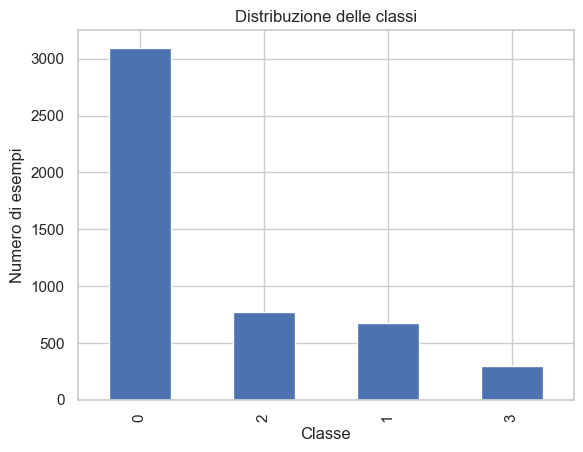


--- Esempi per classe vera 'normal' ---

Esempio indice 3258:
{'Longitude': -73.79626981418477, 'Emission_Levels_g_km': 169.0658290634969, 'Energy_Consumption_L_h': 20.020958898451816, 'CarCount': 15.0, 'BikeCount': 0.0, 'BusCount': 0.0, 'TruckCount': 32.0, 'Day': 12.0, 'Congestion_Index': 0.22986723548198368}
Probabilità:
  normal: 0.9863
  low: 0.0121
  heavy: 0.0000
  high: 0.0016
Classe predetta: normal

Esempio indice 1064:
{'Longitude': -73.94297400546148, 'Emission_Levels_g_km': 293.9120981798982, 'Energy_Consumption_L_h': 11.623895974096463, 'CarCount': 15.0, 'BikeCount': 2.0, 'BusCount': 2.0, 'TruckCount': 31.0, 'Day': 4.0, 'Congestion_Index': 0.12670999776556666}
Probabilità:
  normal: 0.9913
  low: 0.0065
  heavy: 0.0000
  high: 0.0022
Classe predetta: normal

Esempio indice 2773:
{'Longitude': -73.85242518919412, 'Emission_Levels_g_km': 445.1900535867899, 'Energy_Consumption_L_h': 20.27021267518983, 'CarCount': 99.0, 'BikeCount': 0.0, 'BusCount': 11.0, 'TruckCount': 21.0, 

In [ ]:
import matplotlib.pyplot as plt

class_map = {0: "normal", 1: "low", 2: "heavy", 3: "high"}
features= selected_features

# --- Visualizza distribuzione classi ---
print("Distribuzione classi nel dataset:")
print(dataset['Traffic Situation'].value_counts())

dataset['Traffic Situation'].value_counts().plot(kind='bar')
plt.title("Distribuzione delle classi")
plt.xlabel("Classe")
plt.ylabel("Numero di esempi")
plt.show()

# Uniamo tutto in un DataFrame per comodità
test_results = X_test.copy()
test_results['True_Class'] = y_test.values
test_results['Predicted_Class'] = y_test_pred
for i in range(4):
    test_results[f'Prob_{class_map[i]}'] = y_test_proba[:, i]

# Funzione per stampare esempi per una classe specifica
def print_examples_for_class(class_label, n=3):
    print(f"\n--- Esempi per classe vera '{class_map[class_label]}' ---")
    examples = test_results[test_results['True_Class'] == class_label].head(n)
    for idx, row in examples.iterrows():
        print(f"\nEsempio indice {idx}:")
        print(row[features].to_dict())
        print(f"Probabilità:")
        for c in range(4):
            print(f"  {class_map[c]}: {row[f'Prob_{class_map[c]}']:.4f}")
        pred = class_map[row['Predicted_Class']]
        print(f"Classe predetta: {pred}")

# Stampiamo 3 esempi per ogni classe
for cls in range(4):
    print_examples_for_class(cls, n=3)
